# LUAD Improved Model Training and Ablation Analysis

This notebook trains and evaluates lightweight machine-learning and deep-learning models for LUAD stage prediction using the improved patient-level dataset.

## Prediction Tasks

1. Binary classification: Early vs Advanced stage  
2. Four-class classification: Stage I, Stage II, Stage III and Stage IV

## Main Feature Groups

- Reference DNA mutation windows
- Mutated DNA windows
- Mutation-position masks
- Mutation category and severity
- Active LUAD gene features
- Sex
- Age

Smoking history will be evaluated only as a separate ablation experiment because it is completely unavailable in two cohorts.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import random

# Main project directory
PROJECT_DIR = Path(
    r"C:\Users\LAPTOP\Downloads\luad_reserch_code"
)

# Improved-data directory
IMPROVED_DATA_DIR = (
    PROJECT_DIR
    / "luad_processeed_data"
)

# Final improved patient-level dataset
FINAL_DATASET_PATH = (
    IMPROVED_DATA_DIR
    / "final_luad_improved_patient_dataset.csv"
)

print("Final dataset exists:", FINAL_DATASET_PATH.exists())
print("Dataset path:", FINAL_DATASET_PATH)

# Load dataset
df = pd.read_csv(
    FINAL_DATASET_PATH,
    low_memory=False
)

print("\nDataset shape:", df.shape)
print("Total patients:", len(df))
print("Total columns:", df.shape[1])
print("Unique cohorts:", df["COHORT"].nunique())

print("\nBinary-stage distribution:")
print(df["STAGE_BINARY"].value_counts())

print("\nFour-class stage distribution:")
print(df["STAGE_LABEL_4CLASS"].value_counts())

print("\nCohorts:")
print(df["COHORT"].value_counts())
df.tail()

Final dataset exists: True
Dataset path: C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\final_luad_improved_patient_dataset.csv

Dataset shape: (3382, 137)
Total patients: 3382
Total columns: 137
Unique cohorts: 7

Binary-stage distribution:
STAGE_BINARY
Early       2096
Advanced    1286
Name: count, dtype: int64

Four-class stage distribution:
STAGE_LABEL_4CLASS
Stage I      1585
Stage IV      811
Stage II      511
Stage III     475
Name: count, dtype: int64

Cohorts:
COHORT
LUNG_MSK_2017      779
MSKCC_2023         745
MSKCC_2020         555
TCGA_Atlas_2018    488
MSK_NPJPO_2021     396
ONCOSG_2020        268
NCI_2022           151
Name: count, dtype: int64


,COHORT,SAMPLE_ID,PATIENT_ID,SEX,sex_encoded,STAGE_LABEL_4CLASS,STAGE_BINARY,label_stage_4class,label_stage_binary,MUTATED_GENE_LIST,...,GENE_ZNF724,age_numeric,age_for_model,age_unusable_flag,age_outlier_flag,smoking_detail,smoking_binary,smoking_unknown_flag,smoking_pack_years_numeric,pack_years_missing_flag
3377,TCGA_Atlas_2018,TCGA-NJ-A55O-01,TCGA-NJ-A55O,Female,0,Stage II,Early,1,0,"[""OR8H2"", ""KRAS"", ""STK11"", ""CUX1""]",...,0,56.0,56.0,0,0,Unknown,Unknown,1,NaN,1
3378,TCGA_Atlas_2018,TCGA-NJ-A55R-01,TCGA-NJ-A55R,Male,1,Stage I,Early,0,0,"[""KRAS"", ""KEAP1"", ""STK11"", ""STK11"", ""PBRM1"", ""...",...,0,67.0,67.0,0,0,Unknown,Unknown,1,NaN,1
3379,TCGA_Atlas_2018,TCGA-NJ-A7XG-01,TCGA-NJ-A7XG,Male,1,Stage III,Advanced,2,1,"[""RBM15"", ""BIRC6"", ""CTNNA2""]",...,0,49.0,49.0,0,0,Unknown,Unknown,1,NaN,1
3380,TCGA_Atlas_2018,TCGA-O1-A52J-01,TCGA-O1-A52J,Female,0,Stage I,Early,0,0,"[""TP53"", ""LRP1B"", ""LRP1B""]",...,0,74.0,74.0,0,0,Unknown,Unknown,1,NaN,1
3381,TCGA_Atlas_2018,TCGA-S2-AA1A-01,TCGA-S2-AA1A,Female,0,Stage I,Early,0,0,"[""OR8U1"", ""BIRC6""]",...,0,68.0,68.0,0,0,Unknown,Unknown,1,NaN,1


In [2]:
# Step 2 — Parse JSON list columns and inspect DNA sequences

json_columns = [
    "MUTATED_GENE_LIST",
    "REFERENCE_DNA_WINDOW_LIST",
    "MUTATED_DNA_WINDOW_LIST",
    "MUTATION_POSITION_MASK_LIST",
    "VARIANT_CLASSIFICATION_LIST",
    "MUTATION_SEVERITY_LIST",
    "MUTATION_SEVERITY_SCORE_LIST",
    "MASK_EVENT_TYPE_LIST",
    "MUTATION_INDEX_LIST",
    "GENE_MULTIHOT_VECTOR"
]

for column in json_columns:
    df[column] = df[column].apply(
        lambda value: (
            json.loads(value)
            if isinstance(value, str)
            else value
        )
    )

# Display one patient's first mutation window
sample_row = df.iloc[0]

print("Patient ID:", sample_row["PATIENT_ID"])
print("Cohort:", sample_row["COHORT"])
print("Number of mutation windows:", sample_row["MUTATION_WINDOW_COUNT"])

print("\nFirst mutated gene:")
print(sample_row["MUTATED_GENE_LIST"][0])

print("\nReference DNA window:")
print(sample_row["REFERENCE_DNA_WINDOW_LIST"][0])

print("\nMutated DNA window:")
print(sample_row["MUTATED_DNA_WINDOW_LIST"][0])

print("\nMutation-position mask:")
print(sample_row["MUTATION_POSITION_MASK_LIST"][0])

print("\nMutation classification:")
print(sample_row["VARIANT_CLASSIFICATION_LIST"][0])

print("\nMutation severity:")
print(sample_row["MUTATION_SEVERITY_LIST"][0])

print("\nSequence lengths:")
print(
    "Reference:",
    len(sample_row["REFERENCE_DNA_WINDOW_LIST"][0])
)
print(
    "Mutated:",
    len(sample_row["MUTATED_DNA_WINDOW_LIST"][0])
)
print(
    "Mask:",
    len(sample_row["MUTATION_POSITION_MASK_LIST"][0])
)

Patient ID: P-0000036
Cohort: LUNG_MSK_2017
Number of mutation windows: 3

First mutated gene:
TP53

Reference DNA window:
CCTCTCCCCAGCCAAAGAAGAAACCACTGGATGGAGAATATTTCACCCTTCAGATCCGTGGGCGTGAGCGCTTCGAGATGTTCCGAGAGCTGAATGAGGCC

Mutated DNA window:
CCTCTCCCCAGCCAAAGAAGAAACCACTGGATGGAGAATATTTCACCCTTTAGATCCGTGGGCGTGAGCGCTTCGAGATGTTCCGAGAGCTGAATGAGGCC

Mutation-position mask:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Mutation classification:
Nonsense_Mutation

Mutation severity:
High

Sequence lengths:
Reference: 101
Mutated: 101
Mask: 101


In [3]:
# Display only DNA-related columns clearly

pd.set_option("display.max_colwidth", 120)

display(
    df[
        [
            "COHORT",
            "PATIENT_ID",
            "MUTATED_GENE_LIST",
            "REFERENCE_DNA_WINDOW_LIST",
            "MUTATED_DNA_WINDOW_LIST",
            "MUTATION_POSITION_MASK_LIST",
            "VARIANT_CLASSIFICATION_LIST",
            "MUTATION_SEVERITY_LIST"
        ]
    ].head()
)

,COHORT,PATIENT_ID,MUTATED_GENE_LIST,REFERENCE_DNA_WINDOW_LIST,MUTATED_DNA_WINDOW_LIST,MUTATION_POSITION_MASK_LIST,VARIANT_CLASSIFICATION_LIST,MUTATION_SEVERITY_LIST
0,LUNG_MSK_2017,P-0000036,"[TP53, ERBB2, FBXW7]","[CCTCTCCCCAGCCAAAGAAGAAACCACTGGATGGAGAATATTTCACCCTTCAGATCCGTGGGCGTGAGCGCTTCGAGATGTTCCGAGAGCTGAATGAGGCC, TCCCTTGGACAG...","[CCTCTCCCCAGCCAAAGAAGAAACCACTGGATGGAGAATATTTCACCCTTTAGATCCGTGGGCGTGAGCGCTTCGAGATGTTCCGAGAGCTGAATGAGGCC, TCCCTTGGACAG...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Nonsense_Mutation, Missense_Mutation, In_Frame_Del]","[High, Moderate, Moderate]"
1,LUNG_MSK_2017,P-0000110,"[KEAP1, TP53]","[TGAGTGTTACTACCCAGAGAGGAACGAGTGGCGAATGATCACAGCAATGAACACCATCCGAAGCGGGGCAGGCGTCTGCGTCCTGCACAACTGTATCTATG, TGACTGTACCAC...","[TGAGTGTTACTACCCAGAGAGGAACGAGTGGCGAATGATCACAGCAATGAGCACCATCCGAAGCGGGGCAGGCGTCTGCGTCCTGCACAACTGTATCTATG, TGACTGTACCAC...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Missense_Mutation, Frame_Shift_Del]","[Moderate, High]"
2,LUNG_MSK_2017,P-0000133,"[ATM, PIK3CA, TP53]","[ACTTTTGTCAGACTGTACTTCCATACTTGATTCATGATATTTTACTCCAAGATACAAATGAATCATGGAGAAATCTGCTTTCTACACATGTTCAGGGATTT, ATTAAGGGAAAA...","[ACTTTTGTCAGACTGTACTTCCATACTTGATTCATGATATTTTACTCCAAAATACAAATGAATCATGGAGAAATCTGCTTTCTACACATGTTCAGGGATTT, ATTAAGGGAAAA...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Missense_Mutation, Missense_Mutation, Missense_Mutation]","[Moderate, Moderate, Moderate]"
3,LUNG_MSK_2017,P-0000149,"[SETD2, TSC1, ERBB2]","[AACTCAAAATAAAGAGAAAAGGAAACGAAGAAGCTCCCTCTCACCACCCTCTTCTGCCTATGAGCGGGGAACAAAAAGGCCAGATGACAGATATGATACAC, TCAGGAAGACTG...","[AACTCAAAATAAAGAGAAAAGGAAACGAAGAAGCTCCCTCTCACCACCCTGTTCTGCCTATGAGCGGGGAACAAAAAGGCCAGATGACAGATATGATACAC, TCAGGAAGACTG...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Missense_Mutation, Missense_Mutation, In_Frame_Ins]","[Moderate, Moderate, Moderate]"
4,LUNG_MSK_2017,P-0000163,"[TP53, SMARCA4, ERBB2]","[CCATCCACTACAACTACATGTGTAACAGTTCCTGCATGGGCGGCATGAACCGGAGGCCCATCCTCACCATCATCACACTGGAAGACTCCAGTGGTAATCTA, TCCAGACCATCG...","[CCATCCACTACAACTACATGTGTAACAGTTCCTGCATGGGCGGCATGAACTGGAGGCCCATCCTCACCATCATCACACTGGAAGACTCCAGTGGTAATCTA, TCCAGACCATCG...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[Missense_Mutation, Missense_Mutation, In_Frame_Ins]","[Moderate, Moderate, Moderate]"


## Step 3 — Define Primary Model Input Features

This step selects only the required DNA, mutation, gene and clinical features. Identification columns, labels, smoking fields, audit columns and zero-variance genes are excluded from model inputs.

In [4]:
# Step 3 — Define selected model-input columns correctly

# Select only individual numeric gene columns.
# Exclude GENE_MULTIHOT_VECTOR because it contains Python lists.
gene_candidate_columns = [
    column
    for column in df.columns
    if column.startswith("GENE_")
    and column != "GENE_MULTIHOT_VECTOR"
]

all_gene_columns = []

for column in gene_candidate_columns:
    numeric_values = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    unique_values = set(
        numeric_values.dropna().unique()
    )

    # Keep only binary multi-hot gene columns
    if (
        numeric_values.notna().all()
        and unique_values.issubset({0, 1})
    ):
        df[column] = numeric_values.astype(np.int8)
        all_gene_columns.append(column)


# Identify zero-variance gene columns
constant_gene_columns = [
    column
    for column in all_gene_columns
    if df[column].nunique(dropna=False) <= 1
]

# Retain only informative gene columns
active_gene_columns = [
    column
    for column in all_gene_columns
    if column not in constant_gene_columns
]


# DNA sequence branches
dna_input_columns = [
    "REFERENCE_DNA_WINDOW_LIST",
    "MUTATED_DNA_WINDOW_LIST",
    "MUTATION_POSITION_MASK_LIST"
]

# Per-mutation information
mutation_input_columns = [
    "MUTATION_SEVERITY_SCORE_LIST",
    "MUTATION_WINDOW_COUNT"
]

# Independent clinical inputs
clinical_input_columns = [
    "sex_encoded",
    "age_for_model",
    "age_unusable_flag"
]

# Targets — never passed as inputs
target_columns = [
    "label_stage_binary",
    "label_stage_4class"
]

primary_input_columns = (
    dna_input_columns
    + mutation_input_columns
    + active_gene_columns
    + clinical_input_columns
)


print("Original dataset columns:", df.shape[1])
print("Individual gene columns found:", len(all_gene_columns))
print("Constant gene columns excluded:", len(constant_gene_columns))
print("Active gene columns:", len(active_gene_columns))

print("\nConstant genes:")
print(constant_gene_columns)

print("\nDNA input columns:", len(dna_input_columns))
print("Mutation input columns:", len(mutation_input_columns))
print("Clinical input columns:", len(clinical_input_columns))
print("Total selected dataset columns:", len(primary_input_columns))

print("\nGENE_MULTIHOT_VECTOR used directly:",
      "GENE_MULTIHOT_VECTOR" in primary_input_columns)

Original dataset columns: 137
Individual gene columns found: 96
Constant gene columns excluded: 7
Active gene columns: 89

Constant genes:
['GENE_CAPN5', 'GENE_CBLB', 'GENE_CRLF2', 'GENE_EPPK1', 'GENE_NOTCH1', 'GENE_ZFHX4', 'GENE_ZNF724']

DNA input columns: 3
Mutation input columns: 2
Clinical input columns: 3
Total selected dataset columns: 97

GENE_MULTIHOT_VECTOR used directly: False


## Step 4 — Create a Fixed Cohort-Aware Train, Validation and Test Split

The dataset is divided into 70% training, 15% validation and 15% test sets. Splitting is performed separately within each cohort to preserve cohort representation and reduce patient-level data leakage. The same fixed split will be reused for every ablation experiment.

In [5]:
# Step 4 — Create fixed cohort-aware 70/15/15 data splits

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TARGET_COLUMN = "label_stage_binary"


def get_safe_stratify_labels(dataframe, target_column):
    """
    Use stratification only when both classes are present
    and every class has at least two patients.
    """
    class_counts = dataframe[target_column].value_counts()

    if len(class_counts) < 2:
        return None

    if class_counts.min() < 2:
        return None

    return dataframe[target_column]


train_parts = []
validation_parts = []
test_parts = []

for cohort_name, cohort_df in df.groupby("COHORT"):
    cohort_df = cohort_df.copy()

    # First split: 70% training, 30% temporary
    first_stratify = get_safe_stratify_labels(
        cohort_df,
        TARGET_COLUMN
    )

    cohort_train, cohort_temporary = train_test_split(
        cohort_df,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=first_stratify
    )

    # Second split: temporary data into 15% validation and 15% test
    second_stratify = get_safe_stratify_labels(
        cohort_temporary,
        TARGET_COLUMN
    )

    cohort_validation, cohort_test = train_test_split(
        cohort_temporary,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=second_stratify
    )

    train_parts.append(cohort_train)
    validation_parts.append(cohort_validation)
    test_parts.append(cohort_test)


# Combine all cohorts
train_df = pd.concat(
    train_parts,
    ignore_index=True
)

validation_df = pd.concat(
    validation_parts,
    ignore_index=True
)

test_df = pd.concat(
    test_parts,
    ignore_index=True
)


# Shuffle while keeping the split reproducible
train_df = train_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

validation_df = validation_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

test_df = test_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)


# Patient-overlap validation
train_keys = set(
    zip(train_df["COHORT"], train_df["PATIENT_ID"])
)

validation_keys = set(
    zip(validation_df["COHORT"], validation_df["PATIENT_ID"])
)

test_keys = set(
    zip(test_df["COHORT"], test_df["PATIENT_ID"])
)

train_validation_overlap = len(
    train_keys.intersection(validation_keys)
)

train_test_overlap = len(
    train_keys.intersection(test_keys)
)

validation_test_overlap = len(
    validation_keys.intersection(test_keys)
)


print("Training patients:", len(train_df))
print("Validation patients:", len(validation_df))
print("Test patients:", len(test_df))

print("\nPatient overlap checks:")
print("Train vs Validation:", train_validation_overlap)
print("Train vs Test:", train_test_overlap)
print("Validation vs Test:", validation_test_overlap)


# Split distribution summary
split_summary = []

for split_name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:
    split_summary.append(
        {
            "SPLIT": split_name,
            "PATIENTS": len(split_df),
            "EARLY": int(
                (split_df[TARGET_COLUMN] == 0).sum()
            ),
            "ADVANCED": int(
                (split_df[TARGET_COLUMN] == 1).sum()
            ),
            "EARLY_PERCENT": round(
                (split_df[TARGET_COLUMN] == 0).mean() * 100,
                2
            ),
            "ADVANCED_PERCENT": round(
                (split_df[TARGET_COLUMN] == 1).mean() * 100,
                2
            )
        }
    )

split_summary_df = pd.DataFrame(split_summary)

print("\nOverall split summary:")
display(split_summary_df)


print("\nPatients per cohort in each split:")

display(
    pd.crosstab(
        index=train_df["COHORT"],
        columns=pd.Series(
            ["Training"] * len(train_df),
            index=train_df.index
        )
    )
    .join(
        pd.crosstab(
            index=validation_df["COHORT"],
            columns=pd.Series(
                ["Validation"] * len(validation_df),
                index=validation_df.index
            )
        ),
        how="outer"
    )
    .join(
        pd.crosstab(
            index=test_df["COHORT"],
            columns=pd.Series(
                ["Test"] * len(test_df),
                index=test_df.index
            )
        ),
        how="outer"
    )
    .fillna(0)
    .astype(int)
)

Training patients: 2364
Validation patients: 507
Test patients: 511

Patient overlap checks:
Train vs Validation: 0
Train vs Test: 0
Validation vs Test: 0

Overall split summary:


,SPLIT,PATIENTS,EARLY,ADVANCED,EARLY_PERCENT,ADVANCED_PERCENT
0,Training,2364,1464,900,61.93,38.07
1,Validation,507,313,194,61.74,38.26
2,Test,511,319,192,62.43,37.57



Patients per cohort in each split:


col_0,Training,Validation,Test
COHORT,,,
LUNG_MSK_2017,545,117,117
MSKCC_2020,388,83,84
MSKCC_2023,521,112,112
MSK_NPJPO_2021,277,59,60
NCI_2022,105,23,23
ONCOSG_2020,187,40,41
TCGA_Atlas_2018,341,73,74


## Step 5 — Class-Imbalance Handling and Bias Audit

Class weights are calculated using only the training set. Cohort-wise and sex-wise stage distributions are also examined across the training, validation and test sets to identify potential representation bias.

In [6]:
# Step 5 — Calculate training-only class weights and audit bias

from sklearn.utils.class_weight import compute_class_weight

BINARY_TARGET = "label_stage_binary"

# ---------------------------------------------------------
# Calculate binary class weights using training data only
# ---------------------------------------------------------

binary_classes = np.sort(
    train_df[BINARY_TARGET].dropna().unique()
)

binary_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=binary_classes,
    y=train_df[BINARY_TARGET].astype(int)
)

binary_class_weights = {
    int(class_label): float(weight)
    for class_label, weight in zip(
        binary_classes,
        binary_class_weight_values
    )
}

print("Binary class weights calculated from training set:")
print(binary_class_weights)

print("\nLabel meaning:")
print("0 = Early")
print("1 = Advanced")


# ---------------------------------------------------------
# Combine splits temporarily for distribution auditing
# ---------------------------------------------------------

train_audit_df = train_df.copy()
train_audit_df["DATA_SPLIT"] = "Training"

validation_audit_df = validation_df.copy()
validation_audit_df["DATA_SPLIT"] = "Validation"

test_audit_df = test_df.copy()
test_audit_df["DATA_SPLIT"] = "Test"

split_audit_df = pd.concat(
    [
        train_audit_df,
        validation_audit_df,
        test_audit_df
    ],
    ignore_index=True
)


# ---------------------------------------------------------
# Overall class distribution
# ---------------------------------------------------------

overall_bias_audit = (
    split_audit_df
    .groupby("DATA_SPLIT")
    .agg(
        PATIENTS=(BINARY_TARGET, "size"),
        EARLY=(
            BINARY_TARGET,
            lambda x: int((x == 0).sum())
        ),
        ADVANCED=(
            BINARY_TARGET,
            lambda x: int((x == 1).sum())
        ),
        ADVANCED_PERCENT=(
            BINARY_TARGET,
            lambda x: round((x == 1).mean() * 100, 2)
        )
    )
    .reset_index()
)

print("\nOverall class distribution:")
display(overall_bias_audit)


# ---------------------------------------------------------
# Cohort-wise distribution in each split
# ---------------------------------------------------------

cohort_bias_audit = (
    split_audit_df
    .groupby(
        ["DATA_SPLIT", "COHORT"]
    )
    .agg(
        PATIENTS=(BINARY_TARGET, "size"),
        EARLY=(
            BINARY_TARGET,
            lambda x: int((x == 0).sum())
        ),
        ADVANCED=(
            BINARY_TARGET,
            lambda x: int((x == 1).sum())
        ),
        ADVANCED_PERCENT=(
            BINARY_TARGET,
            lambda x: round((x == 1).mean() * 100, 2)
        )
    )
    .reset_index()
)

print("\nCohort-wise stage distribution:")
display(cohort_bias_audit)


# ---------------------------------------------------------
# Sex-wise distribution in each split
# ---------------------------------------------------------

sex_bias_audit = (
    split_audit_df
    .groupby(
        ["DATA_SPLIT", "SEX"]
    )
    .agg(
        PATIENTS=(BINARY_TARGET, "size"),
        EARLY=(
            BINARY_TARGET,
            lambda x: int((x == 0).sum())
        ),
        ADVANCED=(
            BINARY_TARGET,
            lambda x: int((x == 1).sum())
        ),
        ADVANCED_PERCENT=(
            BINARY_TARGET,
            lambda x: round((x == 1).mean() * 100, 2)
        )
    )
    .reset_index()
)

print("\nSex-wise stage distribution:")
display(sex_bias_audit)

Binary class weights calculated from training set:
{0: 0.8073770491803278, 1: 1.3133333333333332}

Label meaning:
0 = Early
1 = Advanced

Overall class distribution:


,DATA_SPLIT,PATIENTS,EARLY,ADVANCED,ADVANCED_PERCENT
0,Test,511,319,192,37.57
1,Training,2364,1464,900,38.07
2,Validation,507,313,194,38.26



Cohort-wise stage distribution:


,DATA_SPLIT,COHORT,PATIENTS,EARLY,ADVANCED,ADVANCED_PERCENT
0,Test,LUNG_MSK_2017,117,13,104,88.89
1,Test,MSKCC_2020,84,75,9,10.71
2,Test,MSKCC_2023,112,67,45,40.18
3,Test,MSK_NPJPO_2021,60,60,0,0.00
4,Test,NCI_2022,23,19,4,17.39
5,Test,ONCOSG_2020,41,27,14,34.15
6,Test,TCGA_Atlas_2018,74,58,16,21.62
7,Training,LUNG_MSK_2017,545,59,486,89.17
8,Training,MSKCC_2020,388,347,41,10.57
9,Training,MSKCC_2023,521,310,211,40.50



Sex-wise stage distribution:


,DATA_SPLIT,SEX,PATIENTS,EARLY,ADVANCED,ADVANCED_PERCENT
0,Test,Female,298,192,106,35.57
1,Test,Male,213,127,86,40.38
2,Training,Female,1397,874,523,37.44
3,Training,Male,967,590,377,38.99
4,Validation,Female,304,188,116,38.16
5,Validation,Male,203,125,78,38.42


## Step 6 — Training-Only Age Imputation and Standardization

Missing or unusable age values are imputed using the median age calculated only from the training set. Age is then standardized using training-set statistics to prevent data leakage.

In [7]:
# Step 6 — Impute and standardize age using training data only

from sklearn.preprocessing import StandardScaler

# Work on copies
train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()

# ---------------------------------------------------------
# Calculate age median from training patients only
# ---------------------------------------------------------

training_age_median = train_df[
    "age_for_model"
].median()

print(
    "Training-set age median:",
    round(float(training_age_median), 2)
)


# ---------------------------------------------------------
# Impute missing/unusable ages
# ---------------------------------------------------------

for split_df in [
    train_df,
    validation_df,
    test_df
]:
    split_df["age_imputed"] = (
        split_df["age_for_model"]
        .fillna(training_age_median)
    )


# ---------------------------------------------------------
# Standardize age using training statistics only
# ---------------------------------------------------------

age_scaler = StandardScaler()

train_df["age_scaled"] = age_scaler.fit_transform(
    train_df[["age_imputed"]]
).ravel()

validation_df["age_scaled"] = age_scaler.transform(
    validation_df[["age_imputed"]]
).ravel()

test_df["age_scaled"] = age_scaler.transform(
    test_df[["age_imputed"]]
).ravel()


# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

age_preprocessing_summary = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Test"
        ],
        "Patients": [
            len(train_df),
            len(validation_df),
            len(test_df)
        ],
        "Originally Missing/Unusable": [
            int(train_df["age_unusable_flag"].sum()),
            int(validation_df["age_unusable_flag"].sum()),
            int(test_df["age_unusable_flag"].sum())
        ],
        "Missing After Imputation": [
            int(train_df["age_imputed"].isna().sum()),
            int(validation_df["age_imputed"].isna().sum()),
            int(test_df["age_imputed"].isna().sum())
        ],
        "Mean Scaled Age": [
            train_df["age_scaled"].mean(),
            validation_df["age_scaled"].mean(),
            test_df["age_scaled"].mean()
        ]
    }
).round(4)

display(age_preprocessing_summary)

print(
    "\nTraining age mean used by scaler:",
    round(float(age_scaler.mean_[0]), 2)
)

print(
    "Training age standard deviation:",
    round(float(age_scaler.scale_[0]), 2)
)

Training-set age median: 66.88


,Split,Patients,Originally Missing/Unusable,Missing After Imputation,Mean Scaled Age
0,Training,2364,20,0,0.0000
1,Validation,507,6,0,0.0298
2,Test,511,7,0,-0.0538



Training age mean used by scaler: 65.7
Training age standard deviation: 10.2


## Step 7 — Configure DNA Tokenization and Patient-Level Padding

Each patient may contain a different number of mutation windows. This step converts DNA bases into numeric tokens and pads every patient to a fixed maximum of 37 mutation windows.

In [8]:
# Step 7 — Configure DNA tokenization and test one patient

MAX_WINDOWS = 37
WINDOW_LENGTH = 101

DNA_TOKEN_MAP = {
    "PAD": 0,
    "A": 1,
    "C": 2,
    "G": 3,
    "T": 4,
    "N": 5
}


def encode_dna_sequence(sequence):
    """
    Convert one 101-base DNA sequence into integer tokens.
    """
    sequence = str(sequence).upper()

    return np.array(
        [
            DNA_TOKEN_MAP.get(base, DNA_TOKEN_MAP["N"])
            for base in sequence
        ],
        dtype=np.int8
    )


def encode_patient_windows(row):
    """
    Encode and pad one patient's mutation-level features.
    """

    reference_sequences = row["REFERENCE_DNA_WINDOW_LIST"]
    mutated_sequences = row["MUTATED_DNA_WINDOW_LIST"]
    position_masks = row["MUTATION_POSITION_MASK_LIST"]
    severity_scores = row["MUTATION_SEVERITY_SCORE_LIST"]

    number_of_windows = min(
        len(reference_sequences),
        MAX_WINDOWS
    )

    reference_tokens = np.zeros(
        (MAX_WINDOWS, WINDOW_LENGTH),
        dtype=np.int8
    )

    mutated_tokens = np.zeros(
        (MAX_WINDOWS, WINDOW_LENGTH),
        dtype=np.int8
    )

    mutation_masks = np.zeros(
        (MAX_WINDOWS, WINDOW_LENGTH),
        dtype=np.int8
    )

    severity_tokens = np.zeros(
        MAX_WINDOWS,
        dtype=np.int8
    )

    window_padding_mask = np.zeros(
        MAX_WINDOWS,
        dtype=np.int8
    )

    for index in range(number_of_windows):

        reference_tokens[index] = encode_dna_sequence(
            reference_sequences[index]
        )

        mutated_tokens[index] = encode_dna_sequence(
            mutated_sequences[index]
        )

        mutation_masks[index] = np.asarray(
            position_masks[index],
            dtype=np.int8
        )

        severity_tokens[index] = int(
            severity_scores[index]
        )

        window_padding_mask[index] = 1

    return {
        "reference_tokens": reference_tokens,
        "mutated_tokens": mutated_tokens,
        "mutation_masks": mutation_masks,
        "severity_tokens": severity_tokens,
        "window_padding_mask": window_padding_mask,
        "number_of_windows": number_of_windows
    }


# Test encoding on one training patient
sample_encoded = encode_patient_windows(
    train_df.iloc[0]
)

print("Maximum windows per patient:", MAX_WINDOWS)
print("DNA window length:", WINDOW_LENGTH)

print(
    "\nReference token shape:",
    sample_encoded["reference_tokens"].shape
)

print(
    "Mutated token shape:",
    sample_encoded["mutated_tokens"].shape
)

print(
    "Mutation-mask shape:",
    sample_encoded["mutation_masks"].shape
)

print(
    "Severity-token shape:",
    sample_encoded["severity_tokens"].shape
)

print(
    "Window-padding-mask shape:",
    sample_encoded["window_padding_mask"].shape
)

print(
    "\nActual mutation windows:",
    sample_encoded["number_of_windows"]
)

print(
    "Active padding-mask positions:",
    int(sample_encoded["window_padding_mask"].sum())
)

print(
    "DNA token range:",
    sample_encoded["reference_tokens"].min(),
    "to",
    sample_encoded["reference_tokens"].max()
)

print(
    "Total marked mutation positions:",
    int(sample_encoded["mutation_masks"].sum())
)

Maximum windows per patient: 37
DNA window length: 101

Reference token shape: (37, 101)
Mutated token shape: (37, 101)
Mutation-mask shape: (37, 101)
Severity-token shape: (37,)
Window-padding-mask shape: (37,)

Actual mutation windows: 1
Active padding-mask positions: 1
DNA token range: 0 to 4
Total marked mutation positions: 1


## Step 8 — Select an Efficient Maximum Number of Mutation Windows

The mutation-window distribution is analysed to reduce unnecessary padding while retaining most patient mutations. Padding masks will still be applied during patient-level pooling.

In [9]:
# Step 8 — Compare candidate maximum-window limits

window_counts = train_df[
    "MUTATION_WINDOW_COUNT"
].astype(int)

percentiles = [
    50,
    75,
    90,
    95,
    97,
    99,
    100
]

print("Training-set mutation-window percentiles:")

for percentile in percentiles:
    value = np.percentile(
        window_counts,
        percentile
    )

    print(
        f"{percentile}th percentile:",
        round(float(value), 2)
    )


candidate_limits = [
    5,
    8,
    10,
    12,
    15,
    20,
    37
]

comparison_rows = []

total_original_windows = int(
    window_counts.sum()
)

for maximum_windows in candidate_limits:

    retained_windows = int(
        window_counts
        .clip(upper=maximum_windows)
        .sum()
    )

    truncated_patients = int(
        (window_counts > maximum_windows).sum()
    )

    total_tensor_slots = (
        len(window_counts)
        * maximum_windows
    )

    padding_slots = (
        total_tensor_slots
        - retained_windows
    )

    comparison_rows.append(
        {
            "MAX_WINDOWS": maximum_windows,

            "PATIENTS_TRUNCATED": truncated_patients,

            "PATIENTS_TRUNCATED_%": round(
                truncated_patients
                / len(window_counts)
                * 100,
                2
            ),

            "WINDOWS_RETAINED_%": round(
                retained_windows
                / total_original_windows
                * 100,
                2
            ),

            "PADDING_RATIO_%": round(
                padding_slots
                / total_tensor_slots
                * 100,
                2
            )
        }
    )


window_limit_comparison = pd.DataFrame(
    comparison_rows
)

print("\nCandidate MAX_WINDOWS comparison:")
display(window_limit_comparison)

Training-set mutation-window percentiles:
50th percentile: 3.0
75th percentile: 4.0
90th percentile: 7.0
95th percentile: 9.0
97th percentile: 13.0
99th percentile: 19.0
100th percentile: 35.0

Candidate MAX_WINDOWS comparison:


,MAX_WINDOWS,PATIENTS_TRUNCATED,PATIENTS_TRUNCATED_%,WINDOWS_RETAINED_%,PADDING_RATIO_%
0,5,333,14.09,80.26,41.21
1,8,146,6.18,89.30,59.12
2,10,95,4.02,92.32,66.19
3,12,73,3.09,94.40,71.19
4,15,45,1.90,96.55,76.43
5,20,19,0.80,98.49,81.96
6,37,0,0.00,100.00,90.10


## Step 9 — Prioritise Mutation Windows Before Truncation

Mutation windows are sorted using mutation severity so that biologically important high-impact variants are retained first. Ties are resolved using the number of affected bases, followed by the original mutation order.

In [10]:
# Step 9 — Sort all aligned mutation lists by severity before truncation

aligned_list_columns = [
    "MUTATED_GENE_LIST",
    "REFERENCE_DNA_WINDOW_LIST",
    "MUTATED_DNA_WINDOW_LIST",
    "MUTATION_POSITION_MASK_LIST",
    "VARIANT_CLASSIFICATION_LIST",
    "MUTATION_SEVERITY_LIST",
    "MUTATION_SEVERITY_SCORE_LIST",
    "MASK_EVENT_TYPE_LIST",
    "MUTATION_INDEX_LIST"
]


def prioritise_patient_mutations(row):
    """
    Sort mutation windows by:
    1. Severity score, descending
    2. Number of affected bases, descending
    3. Original position, ascending

    All aligned mutation lists are reordered together.
    """

    number_of_mutations = len(
        row["MUTATED_GENE_LIST"]
    )

    affected_spans = [
        int(sum(mask))
        for mask in row[
            "MUTATION_POSITION_MASK_LIST"
        ]
    ]

    original_positions = list(
        range(number_of_mutations)
    )

    sorted_indices = sorted(
        original_positions,
        key=lambda index: (
            -int(
                row[
                    "MUTATION_SEVERITY_SCORE_LIST"
                ][index]
            ),
            -affected_spans[index],
            index
        )
    )

    for column in aligned_list_columns:
        row[column] = [
            row[column][index]
            for index in sorted_indices
        ]

    return row


# Apply independently to every split
train_df = train_df.apply(
    prioritise_patient_mutations,
    axis=1
)

validation_df = validation_df.apply(
    prioritise_patient_mutations,
    axis=1
)

test_df = test_df.apply(
    prioritise_patient_mutations,
    axis=1
)


# Validate severity ordering
def severity_is_descending(scores):
    return all(
        scores[index] >= scores[index + 1]
        for index in range(len(scores) - 1)
    )


sorting_summary = pd.DataFrame(
    {
        "Split": [
            "Training",
            "Validation",
            "Test"
        ],
        "Patients": [
            len(train_df),
            len(validation_df),
            len(test_df)
        ],
        "Correctly Sorted": [
            int(
                train_df[
                    "MUTATION_SEVERITY_SCORE_LIST"
                ].apply(severity_is_descending).sum()
            ),
            int(
                validation_df[
                    "MUTATION_SEVERITY_SCORE_LIST"
                ].apply(severity_is_descending).sum()
            ),
            int(
                test_df[
                    "MUTATION_SEVERITY_SCORE_LIST"
                ].apply(severity_is_descending).sum()
            )
        ]
    }
)

display(sorting_summary)

print("\nExample sorted patient:")
print(
    "Genes:",
    train_df.iloc[0]["MUTATED_GENE_LIST"]
)

print(
    "Severity scores:",
    train_df.iloc[0][
        "MUTATION_SEVERITY_SCORE_LIST"
    ]
)

print(
    "Affected spans:",
    [
        sum(mask)
        for mask in train_df.iloc[0][
            "MUTATION_POSITION_MASK_LIST"
        ]
    ]
)

,Split,Patients,Correctly Sorted
0,Training,2364,2364
1,Validation,507,507
2,Test,511,511



Example sorted patient:
Genes: ['SMAD4']
Severity scores: [2]
Affected spans: [1]


## Step 10 — Select the Final Maximum Number of Mutation Windows

A maximum of 13 mutation windows per patient is used. Mutations are already ordered by biological severity, so any necessary truncation removes lower-priority mutations first.

In [11]:
# Step 10 — Set MAX_WINDOWS to 13 and audit truncation

MAX_WINDOWS = 13
WINDOW_LENGTH = 101


def calculate_truncation_summary(split_name, split_df):
    window_counts = split_df[
        "MUTATION_WINDOW_COUNT"
    ].astype(int)

    original_windows = int(window_counts.sum())

    retained_windows = int(
        window_counts.clip(
            upper=MAX_WINDOWS
        ).sum()
    )

    truncated_windows = (
        original_windows
        - retained_windows
    )

    truncated_patients = int(
        (window_counts > MAX_WINDOWS).sum()
    )

    total_tensor_slots = (
        len(split_df)
        * MAX_WINDOWS
    )

    padding_slots = (
        total_tensor_slots
        - retained_windows
    )

    return {
        "Split": split_name,
        "Patients": len(split_df),
        "Patients Truncated": truncated_patients,
        "Patients Truncated %": round(
            truncated_patients
            / len(split_df)
            * 100,
            2
        ),
        "Original Windows": original_windows,
        "Retained Windows": retained_windows,
        "Windows Retained %": round(
            retained_windows
            / original_windows
            * 100,
            2
        ),
        "Padding Ratio %": round(
            padding_slots
            / total_tensor_slots
            * 100,
            2
        )
    }


max_windows_summary = pd.DataFrame(
    [
        calculate_truncation_summary(
            "Training",
            train_df
        ),
        calculate_truncation_summary(
            "Validation",
            validation_df
        ),
        calculate_truncation_summary(
            "Test",
            test_df
        )
    ]
)

print("Selected MAX_WINDOWS:", MAX_WINDOWS)
print("Selection rule: severity-first truncation")

display(max_windows_summary)

Selected MAX_WINDOWS: 13
Selection rule: severity-first truncation


,Split,Patients,Patients Truncated,Patients Truncated %,Original Windows,Retained Windows,Windows Retained %,Padding Ratio %
0,Training,2364,60,2.54,8658,8246,95.24,73.17
1,Validation,507,16,3.16,1917,1801,93.95,72.67
2,Test,511,15,2.94,2005,1901,94.81,71.38


## Step 11 — Build Final Input Tensors for Model Training

All variable-length mutation records are converted into fixed-size tensors using `MAX_WINDOWS = 13`. A window-padding mask is preserved so padded windows can be excluded during masked patient-level pooling.

In [12]:
# Step 11 — Build final tensors for training, validation and test sets

MAX_WINDOWS = 13
WINDOW_LENGTH = 101

# ---------------------------------------------------------
# Scale mutation count using training data only
# ---------------------------------------------------------

train_log_counts = np.log1p(
    train_df["MUTATION_WINDOW_COUNT"].astype(float)
)

mutation_count_mean = train_log_counts.mean()
mutation_count_std = train_log_counts.std()

if mutation_count_std == 0:
    mutation_count_std = 1.0


for split_df in [train_df, validation_df, test_df]:
    split_df["mutation_count_scaled"] = (
        np.log1p(
            split_df["MUTATION_WINDOW_COUNT"].astype(float)
        )
        - mutation_count_mean
    ) / mutation_count_std


# ---------------------------------------------------------
# Convert one split into model-ready arrays
# ---------------------------------------------------------

def build_model_arrays(split_df):
    patient_count = len(split_df)

    reference_dna = np.zeros(
        (patient_count, MAX_WINDOWS, WINDOW_LENGTH),
        dtype=np.int8
    )

    mutated_dna = np.zeros(
        (patient_count, MAX_WINDOWS, WINDOW_LENGTH),
        dtype=np.int8
    )

    mutation_position_mask = np.zeros(
        (patient_count, MAX_WINDOWS, WINDOW_LENGTH),
        dtype=np.float32
    )

    severity_tokens = np.zeros(
        (patient_count, MAX_WINDOWS),
        dtype=np.int8
    )

    window_padding_mask = np.zeros(
        (patient_count, MAX_WINDOWS),
        dtype=np.float32
    )

    for patient_index, (_, row) in enumerate(
        split_df.iterrows()
    ):
        number_of_windows = min(
            len(row["REFERENCE_DNA_WINDOW_LIST"]),
            MAX_WINDOWS
        )

        for window_index in range(number_of_windows):
            reference_dna[
                patient_index,
                window_index
            ] = encode_dna_sequence(
                row["REFERENCE_DNA_WINDOW_LIST"][
                    window_index
                ]
            )

            mutated_dna[
                patient_index,
                window_index
            ] = encode_dna_sequence(
                row["MUTATED_DNA_WINDOW_LIST"][
                    window_index
                ]
            )

            mutation_position_mask[
                patient_index,
                window_index
            ] = np.asarray(
                row["MUTATION_POSITION_MASK_LIST"][
                    window_index
                ],
                dtype=np.float32
            )

            severity_tokens[
                patient_index,
                window_index
            ] = int(
                row["MUTATION_SEVERITY_SCORE_LIST"][
                    window_index
                ]
            )

            window_padding_mask[
                patient_index,
                window_index
            ] = 1.0

    # 89 active gene features
    gene_features = (
        split_df[active_gene_columns]
        .to_numpy(dtype=np.float32)
    )

    # Sex, scaled age, age-missing flag and mutation count
    numeric_features = split_df[
        [
            "sex_encoded",
            "age_scaled",
            "age_unusable_flag",
            "mutation_count_scaled"
        ]
    ].to_numpy(dtype=np.float32)

    binary_labels = split_df[
        "label_stage_binary"
    ].to_numpy(dtype=np.float32)

    four_class_labels = split_df[
        "label_stage_4class"
    ].to_numpy(dtype=np.int32)

    return {
        "reference_dna": reference_dna,
        "mutated_dna": mutated_dna,
        "mutation_position_mask": mutation_position_mask,
        "severity_tokens": severity_tokens,
        "window_padding_mask": window_padding_mask,
        "gene_features": gene_features,
        "numeric_features": numeric_features,
        "binary_labels": binary_labels,
        "four_class_labels": four_class_labels
    }


train_arrays = build_model_arrays(train_df)
validation_arrays = build_model_arrays(validation_df)
test_arrays = build_model_arrays(test_df)


# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

print("TRAINING ARRAY SHAPES")
print(
    "Reference DNA:",
    train_arrays["reference_dna"].shape
)
print(
    "Mutated DNA:",
    train_arrays["mutated_dna"].shape
)
print(
    "Position mask:",
    train_arrays["mutation_position_mask"].shape
)
print(
    "Severity:",
    train_arrays["severity_tokens"].shape
)
print(
    "Window padding mask:",
    train_arrays["window_padding_mask"].shape
)
print(
    "Active genes:",
    train_arrays["gene_features"].shape
)
print(
    "Numeric features:",
    train_arrays["numeric_features"].shape
)
print(
    "Binary labels:",
    train_arrays["binary_labels"].shape
)
print(
    "Four-class labels:",
    train_arrays["four_class_labels"].shape
)

print("\nVALIDATION PATIENTS:",
      len(validation_arrays["binary_labels"]))

print("TEST PATIENTS:",
      len(test_arrays["binary_labels"]))

print(
    "\nTraining active-window ratio:",
    round(
        train_arrays["window_padding_mask"].mean()
        * 100,
        2
    ),
    "%"
)

print(
    "Training padding ratio:",
    round(
        (
            1
            - train_arrays["window_padding_mask"].mean()
        )
        * 100,
        2
    ),
    "%"
)

print(
    "\nSeverity token range:",
    train_arrays["severity_tokens"].min(),
    "to",
    train_arrays["severity_tokens"].max()
)

print(
    "DNA token range:",
    train_arrays["reference_dna"].min(),
    "to",
    train_arrays["reference_dna"].max()
)

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_2600\1729388540.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df["mutation_count_scaled"] = (
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_2600\1729388540.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df["mutation_count_scaled"] = (
C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_2600\1729388540.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

TRAINING ARRAY SHAPES
Reference DNA: (2364, 13, 101)
Mutated DNA: (2364, 13, 101)
Position mask: (2364, 13, 101)
Severity: (2364, 13)
Window padding mask: (2364, 13)
Active genes: (2364, 89)
Numeric features: (2364, 4)
Binary labels: (2364,)
Four-class labels: (2364,)

VALIDATION PATIENTS: 507
TEST PATIENTS: 511

Training active-window ratio: 26.83 %
Training padding ratio: 73.17 %

Severity token range: 0 to 3
DNA token range: 0 to 5


## Step 12 — Build the Improved Mask-Aware Binary Classification Model

This model jointly processes reference DNA, mutated DNA, mutation-position masks, mutation severity, active LUAD gene features, sex and age. Padded mutation windows are explicitly excluded through masked mean and masked max pooling.

In [13]:
# Step 12 — Build the improved mask-aware binary classification model

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

tf.keras.backend.clear_session()

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DNA_VOCAB_SIZE = 6
DNA_EMBEDDING_DIM = 8
SEVERITY_VOCAB_SIZE = 4
SEVERITY_EMBEDDING_DIM = 8
L2_WEIGHT = 1e-4


# ---------------------------------------------------------
# Custom masked-pooling functions
# ---------------------------------------------------------

def masked_mean_pooling(inputs):
    window_features, padding_mask = inputs

    padding_mask = tf.cast(
        tf.expand_dims(padding_mask, axis=-1),
        window_features.dtype
    )

    feature_sum = tf.reduce_sum(
        window_features * padding_mask,
        axis=1
    )

    valid_window_count = tf.reduce_sum(
        padding_mask,
        axis=1
    )

    valid_window_count = tf.maximum(
        valid_window_count,
        1.0
    )

    return feature_sum / valid_window_count


def masked_max_pooling(inputs):
    window_features, padding_mask = inputs

    padding_mask = tf.cast(
        tf.expand_dims(padding_mask, axis=-1),
        tf.bool
    )

    very_negative = tf.fill(
        tf.shape(window_features),
        tf.cast(-1e9, window_features.dtype)
    )

    masked_features = tf.where(
        padding_mask,
        window_features,
        very_negative
    )

    return tf.reduce_max(
        masked_features,
        axis=1
    )


# ---------------------------------------------------------
# Model inputs
# ---------------------------------------------------------

reference_dna_input = layers.Input(
    shape=(MAX_WINDOWS, WINDOW_LENGTH),
    dtype="int32",
    name="reference_dna"
)

mutated_dna_input = layers.Input(
    shape=(MAX_WINDOWS, WINDOW_LENGTH),
    dtype="int32",
    name="mutated_dna"
)

mutation_position_mask_input = layers.Input(
    shape=(MAX_WINDOWS, WINDOW_LENGTH),
    dtype="float32",
    name="mutation_position_mask"
)

severity_input = layers.Input(
    shape=(MAX_WINDOWS,),
    dtype="int32",
    name="severity_tokens"
)

window_padding_mask_input = layers.Input(
    shape=(MAX_WINDOWS,),
    dtype="float32",
    name="window_padding_mask"
)

gene_input = layers.Input(
    shape=(len(active_gene_columns),),
    dtype="float32",
    name="gene_features"
)

numeric_input = layers.Input(
    shape=(4,),
    dtype="float32",
    name="numeric_features"
)


# ---------------------------------------------------------
# Shared DNA embedding
# ---------------------------------------------------------

dna_embedding = layers.Embedding(
    input_dim=DNA_VOCAB_SIZE,
    output_dim=DNA_EMBEDDING_DIM,
    name="shared_dna_embedding"
)

reference_embedding = dna_embedding(
    reference_dna_input
)

mutated_embedding = dna_embedding(
    mutated_dna_input
)

dna_embedding_difference = layers.Lambda(
    lambda tensors: tf.abs(tensors[0] - tensors[1]),
    name="dna_embedding_difference"
)(
    [mutated_embedding, reference_embedding]
)

position_mask_channel = layers.Lambda(
    lambda tensor: tf.expand_dims(tensor, axis=-1),
    name="position_mask_channel"
)(
    mutation_position_mask_input
)

combined_base_features = layers.Concatenate(
    axis=-1,
    name="combined_base_features"
)(
    [
        reference_embedding,
        mutated_embedding,
        dna_embedding_difference,
        position_mask_channel
    ]
)


# ---------------------------------------------------------
# Per-window 1D-CNN
# ---------------------------------------------------------

window_features = layers.TimeDistributed(
    layers.Conv1D(
        filters=32,
        kernel_size=7,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT)
    ),
    name="window_conv_1"
)(
    combined_base_features
)

window_features = layers.TimeDistributed(
    layers.MaxPooling1D(
        pool_size=2
    ),
    name="window_pool_1"
)(
    window_features
)

window_features = layers.TimeDistributed(
    layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT)
    ),
    name="window_conv_2"
)(
    window_features
)

window_features = layers.TimeDistributed(
    layers.GlobalMaxPooling1D(),
    name="window_sequence_pooling"
)(
    window_features
)


# ---------------------------------------------------------
# Mutation-severity representation
# ---------------------------------------------------------

severity_embedding = layers.Embedding(
    input_dim=SEVERITY_VOCAB_SIZE,
    output_dim=SEVERITY_EMBEDDING_DIM,
    name="severity_embedding"
)(
    severity_input
)

window_features = layers.Concatenate(
    name="window_and_severity_features"
)(
    [
        window_features,
        severity_embedding
    ]
)

window_features = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="window_dense"
)(
    window_features
)

window_features = layers.Dropout(
    0.20,
    name="window_dropout"
)(
    window_features
)


# ---------------------------------------------------------
# Masked patient-level pooling
# Padded windows are ignored here
# ---------------------------------------------------------

masked_mean_features = layers.Lambda(
    masked_mean_pooling,
    name="masked_mean_pooling"
)(
    [
        window_features,
        window_padding_mask_input
    ]
)

masked_max_features = layers.Lambda(
    masked_max_pooling,
    name="masked_max_pooling"
)(
    [
        window_features,
        window_padding_mask_input
    ]
)

patient_dna_features = layers.Concatenate(
    name="patient_dna_features"
)(
    [
        masked_mean_features,
        masked_max_features
    ]
)


# ---------------------------------------------------------
# Gene branch
# ---------------------------------------------------------

gene_features = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="gene_dense"
)(
    gene_input
)

gene_features = layers.Dropout(
    0.20,
    name="gene_dropout"
)(
    gene_features
)


# ---------------------------------------------------------
# Clinical/numeric branch
# sex + age + missing-age flag + mutation count
# ---------------------------------------------------------

numeric_features = layers.Dense(
    16,
    activation="relu",
    name="numeric_dense"
)(
    numeric_input
)


# ---------------------------------------------------------
# Final multimodal classifier
# ---------------------------------------------------------

combined_patient_features = layers.Concatenate(
    name="combined_patient_features"
)(
    [
        patient_dna_features,
        gene_features,
        numeric_features
    ]
)

classifier = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_1"
)(
    combined_patient_features
)

classifier = layers.Dropout(
    0.40,
    name="classifier_dropout_1"
)(
    classifier
)

classifier = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense_2"
)(
    classifier
)

classifier = layers.Dropout(
    0.25,
    name="classifier_dropout_2"
)(
    classifier
)

binary_output = layers.Dense(
    1,
    activation="sigmoid",
    name="binary_stage_output"
)(
    classifier
)


binary_model = models.Model(
    inputs=[
        reference_dna_input,
        mutated_dna_input,
        mutation_position_mask_input,
        severity_input,
        window_padding_mask_input,
        gene_input,
        numeric_input
    ],
    outputs=binary_output,
    name="LUAD_Improved_MaskAware_CNN"
)


binary_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="advanced_recall"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

binary_model.summary()

Model: "LUAD_Improved_MaskAware_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ reference_dna       │ (None, 13, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna         │ (None, 13, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dna_embeddi… │ (None, 13, 101,   │         48 │ reference_dna[0]… │
│ (Embedding)         │ 8)                │            │ mutated_dna[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 13, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_embedding_diff… │ (None, 13, 101,   │          0 │ shared_dna_embed… │
│ (Lambda)            │ 8)                │            │ shared_dna_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_mask_chan… │ (None, 13, 101,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_base_feat… │ (None, 13, 101,   │          0 │ shared_dna_embed… │
│ (Concatenate)       │ 25)               │            │ shared_dna_embed… │
│                     │                   │            │ dna_embedding_di… │
│                     │                   │            │ position_mask_ch… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_conv_1       │ (None, 13, 101,   │      5,632 │ combined_base_fe… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_pool_1       │ (None, 13, 50,    │          0 │ window_conv_1[0]… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_conv_2       │ (None, 13, 50,    │     10,304 │ window_pool_1[0]… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_tokens     │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_sequence_po… │ (None, 13, 64)    │          0 │ window_conv_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_embedding  │ (None, 13, 8)     │         32 │ severity_tokens[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_and_severit… │ (None, 13, 72)    │          0 │ window_sequence_… │
│ (Concatenate)       │                   │            │ severity_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_dense        │ (None, 13, 64)    │      4,672 │ window_and_sever… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_dropout      │ (None, 13, 64)    │          0 │ window_dense[0][… │
│ (Dropout)           │                   │            │                 

 Total params: 61,601 (240.63 KB)

 Trainable params: 61,601 (240.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 13 — Train the Improved Binary Stage Classification Model

The model is trained to predict Early versus Advanced LUAD stage. Class weights address label imbalance, while early stopping and learning-rate reduction help control overfitting.

In [14]:
# Step 13 — Train the improved binary classification model

# ---------------------------------------------------------
# Prepare model input dictionaries
# ---------------------------------------------------------

train_inputs = {
    "reference_dna": train_arrays["reference_dna"],
    "mutated_dna": train_arrays["mutated_dna"],
    "mutation_position_mask": train_arrays[
        "mutation_position_mask"
    ],
    "severity_tokens": train_arrays["severity_tokens"],
    "window_padding_mask": train_arrays[
        "window_padding_mask"
    ],
    "gene_features": train_arrays["gene_features"],
    "numeric_features": train_arrays["numeric_features"]
}

validation_inputs = {
    "reference_dna": validation_arrays["reference_dna"],
    "mutated_dna": validation_arrays["mutated_dna"],
    "mutation_position_mask": validation_arrays[
        "mutation_position_mask"
    ],
    "severity_tokens": validation_arrays["severity_tokens"],
    "window_padding_mask": validation_arrays[
        "window_padding_mask"
    ],
    "gene_features": validation_arrays["gene_features"],
    "numeric_features": validation_arrays["numeric_features"]
}


# ---------------------------------------------------------
# Training callbacks
# ---------------------------------------------------------

training_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=8,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.TerminateOnNaN()
]


# ---------------------------------------------------------
# Train model
# ---------------------------------------------------------

binary_history = binary_model.fit(
    train_inputs,
    train_arrays["binary_labels"],

    validation_data=(
        validation_inputs,
        validation_arrays["binary_labels"]
    ),

    epochs=50,
    batch_size=16,

    class_weight=binary_class_weights,

    callbacks=training_callbacks,

    shuffle=True,
    verbose=1
)

print("\nTraining completed.")
print(
    "Epochs completed:",
    len(binary_history.history["loss"])
)

print(
    "Best validation ROC-AUC:",
    round(
        max(binary_history.history["val_roc_auc"]),
        4
    )
)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.5470 - advanced_recall: 0.4967 - loss: 0.7262 - pr_auc: 0.4390 - precision: 0.4197 - roc_auc: 0.5528 - val_accuracy: 0.5345 - val_advanced_recall: 0.7938 - val_loss: 0.7217 - val_pr_auc: 0.4796 - val_precision: 0.4400 - val_roc_auc: 0.6175 - learning_rate: 0.0010
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.5918 - advanced_recall: 0.5711 - loss: 0.7052 - pr_auc: 0.4888 - precision: 0.4703 - roc_auc: 0.6164 - val_accuracy: 0.5779 - val_advanced_recall: 0.7320 - val_loss: 0.7066 - val_pr_auc: 0.5019 - val_precision: 0.4671 - val_roc_auc: 0.6361 - learning_rate: 0.0010
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.6214 - advanced_recall: 0.5944 - loss: 0.6877 - pr_auc: 0.5261 - precision: 0.5023 - roc_auc: 0.6534 - val_accuracy: 0.5838 - val_advanced_recall: 0.6546 - val_loss: 0.6976 - val_pr_auc: 0.5181 - val_precision: 0.4686 - val_roc_auc: 0.6333 - learning_rate: 0.0010
Epo

## Step 14 — Evaluate Binary Model Performance

The trained model is evaluated on the training, validation and untouched test sets using accuracy, precision, recall, F1-score, specificity, balanced accuracy, ROC-AUC and PR-AUC.

In [15]:
# Step 14 — Calculate binary classification metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

DECISION_THRESHOLD = 0.50


def create_model_inputs(array_dict):
    """Create the input dictionary expected by the trained model."""
    return {
        "reference_dna": array_dict["reference_dna"],
        "mutated_dna": array_dict["mutated_dna"],
        "mutation_position_mask": array_dict[
            "mutation_position_mask"
        ],
        "severity_tokens": array_dict["severity_tokens"],
        "window_padding_mask": array_dict[
            "window_padding_mask"
        ],
        "gene_features": array_dict["gene_features"],
        "numeric_features": array_dict["numeric_features"]
    }


def evaluate_binary_model(
    model,
    input_data,
    true_labels,
    split_name,
    threshold=0.50
):
    """Calculate probability-based and threshold-based metrics."""

    probabilities = model.predict(
        input_data,
        batch_size=16,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_labels = np.asarray(
        true_labels
    ).astype(int).ravel()

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    metrics = {
        "Split": split_name,
        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),
        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),
        "Specificity_Early": specificity,
        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),
        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return metrics, probabilities, predictions


# Prepare validation and test inputs
validation_inputs = create_model_inputs(
    validation_arrays
)

test_inputs = create_model_inputs(
    test_arrays
)


# Evaluate all splits
train_metrics, train_probabilities, train_predictions = (
    evaluate_binary_model(
        binary_model,
        train_inputs,
        train_arrays["binary_labels"],
        "Training",
        DECISION_THRESHOLD
    )
)

validation_metrics, validation_probabilities, validation_predictions = (
    evaluate_binary_model(
        binary_model,
        validation_inputs,
        validation_arrays["binary_labels"],
        "Validation",
        DECISION_THRESHOLD
    )
)

test_metrics, test_probabilities, test_predictions = (
    evaluate_binary_model(
        binary_model,
        test_inputs,
        test_arrays["binary_labels"],
        "Test",
        DECISION_THRESHOLD
    )
)


metrics_table = pd.DataFrame(
    [
        train_metrics,
        validation_metrics,
        test_metrics
    ]
)

metric_columns = [
    "Split",
    "Accuracy",
    "Precision",
    "Recall_Advanced",
    "Specificity_Early",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

print("Decision threshold:", DECISION_THRESHOLD)
print("Positive class: Advanced = 1")

print("\nModel performance:")
display(
    metrics_table[metric_columns].round(4)
)

print("\nConfusion-matrix counts:")
display(
    metrics_table[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

test_majority_baseline = max(
    np.mean(
        test_arrays["binary_labels"] == 0
    ),
    np.mean(
        test_arrays["binary_labels"] == 1
    )
)

print(
    "\nTest majority-class baseline accuracy:",
    round(float(test_majority_baseline), 4)
)

Decision threshold: 0.5
Positive class: Advanced = 1

Model performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.5914,0.4773,0.7700,0.4816,0.5893,0.6258,0.6826,0.5531
1,Validation,0.5779,0.4671,0.7320,0.4824,0.5703,0.6072,0.6367,0.5056
2,Test,0.5969,0.4780,0.7917,0.4796,0.5961,0.6356,0.6832,0.5869



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,705,759,207,693
1,Validation,151,162,52,142
2,Test,153,166,40,152



Test majority-class baseline accuracy: 0.6243


## Step 15 — Select the Decision Threshold Using Validation Data

The decision threshold is selected only from the validation set by maximising balanced accuracy. The fixed threshold is then applied to the untouched test set.

In [16]:
# Step 15 — Tune threshold using validation balanced accuracy

from sklearn.metrics import balanced_accuracy_score

threshold_candidates = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []

validation_true = (
    validation_arrays["binary_labels"]
    .astype(int)
)

for threshold in threshold_candidates:
    validation_predicted = (
        validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "Threshold": threshold,
            "Balanced_Accuracy": balanced_accuracy_score(
                validation_true,
                validation_predicted
            ),
            "Accuracy": accuracy_score(
                validation_true,
                validation_predicted
            ),
            "Precision": precision_score(
                validation_true,
                validation_predicted,
                zero_division=0
            ),
            "Recall_Advanced": recall_score(
                validation_true,
                validation_predicted,
                zero_division=0
            ),
            "F1_Score": f1_score(
                validation_true,
                validation_predicted,
                zero_division=0
            )
        }
    )

threshold_results_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = threshold_results_df.loc[
    threshold_results_df[
        "Balanced_Accuracy"
    ].idxmax()
]

BEST_THRESHOLD = float(
    best_threshold_row["Threshold"]
)

print(
    "Best validation threshold:",
    round(BEST_THRESHOLD, 2)
)

print("\nValidation metrics at selected threshold:")
display(
    best_threshold_row
    .to_frame(name="Score")
    .round(4)
)

Best validation threshold: 0.51

Validation metrics at selected threshold:


,Score
Threshold,0.5100
Balanced_Accuracy,0.6195
Accuracy,0.6016
Precision,0.4856
Recall_Advanced,0.6959
F1_Score,0.5720


## Step 16 — Evaluate the Validation-Selected Threshold on the Test Set

The threshold selected from validation data is applied without modification to the training, validation and untouched test sets.

In [17]:
# Step 16 — Evaluate all splits using the fixed threshold of 0.51

FINAL_DECISION_THRESHOLD = BEST_THRESHOLD


def calculate_metrics_from_probabilities(
    true_labels,
    probabilities,
    split_name,
    threshold
):
    true_labels = np.asarray(
        true_labels
    ).astype(int).ravel()

    predictions = (
        np.asarray(probabilities).ravel()
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Split": split_name,
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Specificity_Early": specificity,

        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


final_threshold_metrics = pd.DataFrame(
    [
        calculate_metrics_from_probabilities(
            train_arrays["binary_labels"],
            train_probabilities,
            "Training",
            FINAL_DECISION_THRESHOLD
        ),

        calculate_metrics_from_probabilities(
            validation_arrays["binary_labels"],
            validation_probabilities,
            "Validation",
            FINAL_DECISION_THRESHOLD
        ),

        calculate_metrics_from_probabilities(
            test_arrays["binary_labels"],
            test_probabilities,
            "Test",
            FINAL_DECISION_THRESHOLD
        )
    ]
)

print(
    "Final validation-selected threshold:",
    round(FINAL_DECISION_THRESHOLD, 2)
)

print("\nPerformance at final threshold:")

display(
    final_threshold_metrics[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    final_threshold_metrics[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

Final validation-selected threshold: 0.51

Performance at final threshold:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.6125,0.4939,0.7156,0.5492,0.5844,0.6324,0.6826,0.5531
1,Validation,0.6016,0.4856,0.6959,0.5431,0.5720,0.6195,0.6367,0.5056
2,Test,0.6145,0.4913,0.7344,0.5423,0.5887,0.6383,0.6832,0.5869



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,804,660,256,644
1,Validation,170,143,59,135
2,Test,173,146,51,141


## Step 17 — Prepare Tabular Features for XGBoost

The XGBoost baseline uses active LUAD gene indicators, patient-level mutation severity summaries, mutation burden, sex and age. Raw DNA sequence tensors are excluded because XGBoost requires fixed tabular features.

In [ ]:
# Step 17 — Prepare XGBoost training, validation and test matrices

xgb_summary_feature_columns = [
    "TOTAL_VALID_MUTATIONS",
    "UNIQUE_MUTATED_GENES",
    "MAX_SEVERITY_SCORE",
    "MEAN_SEVERITY_SCORE", 
    "HIGH_SEVERITY_COUNT",
    "MODERATE_SEVERITY_COUNT",
    "LOW_SEVERITY_COUNT",
    "sex_encoded",
    "age_scaled",
    "age_unusable_flag",
    "mutation_count_scaled"
]

xgb_feature_columns = (
    active_gene_columns
    + xgb_summary_feature_columns
)

# Create fixed tabular matrices
X_train_xgb = train_df[
    xgb_feature_columns
].to_numpy(dtype=np.float32)

X_validation_xgb = validation_df[
    xgb_feature_columns
].to_numpy(dtype=np.float32)

X_test_xgb = test_df[
    xgb_feature_columns
].to_numpy(dtype=np.float32)

y_train_xgb = train_df[
    "label_stage_binary"
].to_numpy(dtype=np.int32)

y_validation_xgb = validation_df[
    "label_stage_binary"
].to_numpy(dtype=np.int32)

y_test_xgb = test_df[
    "label_stage_binary"
].to_numpy(dtype=np.int32)


# Validation checks
print("XGBoost feature count:", len(xgb_feature_columns))
print("Active gene features:", len(active_gene_columns))
print(
    "Mutation/clinical summary features:",
    len(xgb_summary_feature_columns)
)

print("\nArray shapes:")
print("Training:", X_train_xgb.shape)
print("Validation:", X_validation_xgb.shape)
print("Test:", X_test_xgb.shape)

print("\nLabel shapes:")
print("Training:", y_train_xgb.shape)
print("Validation:", y_validation_xgb.shape)
print("Test:", y_test_xgb.shape)

print("\nMissing values:")
print("Training:", int(np.isnan(X_train_xgb).sum()))
print("Validation:", int(np.isnan(X_validation_xgb).sum()))
print("Test:", int(np.isnan(X_test_xgb).sum()))

print("\nInput contains raw DNA sequences:", False)
print("Smoking included:", False)
print("Cohort included:", False)

XGBoost feature count: 100
Active gene features: 89
Mutation/clinical summary features: 11

Array shapes:
Training: (2364, 100)
Validation: (507, 100)
Test: (511, 100)

Label shapes:
Training: (2364,)
Validation: (507,)
Test: (511,)

Missing values:
Training: 0
Validation: 0
Test: 0

Input contains raw DNA sequences: False
Smoking included: False
Cohort included: False


## Step 18 — Train the XGBoost Binary Classification Model

The XGBoost model is trained using active LUAD gene indicators, mutation-severity summaries, mutation burden, sex and age. Early stopping is based only on validation ROC-AUC.

In [19]:
# Step 18 — Train XGBoost with validation-based early stopping

import xgboost as xgb
from packaging.version import Version

# ---------------------------------------------------------
# Calculate class-balance weight from training labels only
# ---------------------------------------------------------

number_of_early = int((y_train_xgb == 0).sum())
number_of_advanced = int((y_train_xgb == 1).sum())

scale_pos_weight = (
    number_of_early / number_of_advanced
)

print("XGBoost version:", xgb.__version__)
print("Training Early patients:", number_of_early)
print("Training Advanced patients:", number_of_advanced)
print("scale_pos_weight:", round(scale_pos_weight, 4))


# ---------------------------------------------------------
# Common XGBoost parameters
# ---------------------------------------------------------

xgb_parameters = {
    "objective": "binary:logistic",

    "n_estimators": 1000,
    "learning_rate": 0.03,

    "max_depth": 4,
    "min_child_weight": 3,

    "subsample": 0.80,
    "colsample_bytree": 0.80,

    "gamma": 0.0,
    "reg_alpha": 0.10,
    "reg_lambda": 1.50,

    "scale_pos_weight": scale_pos_weight,

    "eval_metric": "auc",
    "tree_method": "hist",

    "random_state": 42,
    "n_jobs": -1
}


# ---------------------------------------------------------
# Handle newer and older XGBoost versions
# ---------------------------------------------------------

if Version(xgb.__version__) >= Version("1.6.0"):

    xgb_binary_model = xgb.XGBClassifier(
        **xgb_parameters,
        early_stopping_rounds=50
    )

    xgb_binary_model.fit(
        X_train_xgb,
        y_train_xgb,

        eval_set=[
            (X_train_xgb, y_train_xgb),
            (X_validation_xgb, y_validation_xgb)
        ],

        verbose=25
    )

else:

    xgb_binary_model = xgb.XGBClassifier(
        **xgb_parameters
    )

    xgb_binary_model.fit(
        X_train_xgb,
        y_train_xgb,

        eval_set=[
            (X_train_xgb, y_train_xgb),
            (X_validation_xgb, y_validation_xgb)
        ],

        early_stopping_rounds=50,
        verbose=25
    )


# ---------------------------------------------------------
# Training summary
# ---------------------------------------------------------

print("\nXGBoost training completed.")

if hasattr(xgb_binary_model, "best_iteration"):
    print(
        "Best boosting iteration:",
        xgb_binary_model.best_iteration
    )

if hasattr(xgb_binary_model, "best_score"):
    print(
        "Best validation ROC-AUC:",
        round(float(xgb_binary_model.best_score), 4)
    )

XGBoost version: 3.2.0
Training Early patients: 1464
Training Advanced patients: 900
scale_pos_weight: 1.6267
[0]	validation_0-auc:0.63890	validation_1-auc:0.64504
[25]	validation_0-auc:0.69970	validation_1-auc:0.65243
[50]	validation_0-auc:0.71717	validation_1-auc:0.65517
[51]	validation_0-auc:0.71765	validation_1-auc:0.65389

XGBoost training completed.
Best boosting iteration: 1
Best validation ROC-AUC: 0.6581


## Step 19 — Evaluate XGBoost Binary Classification Performance

The trained XGBoost model is evaluated on the training, validation and untouched test sets using classification and probability-based metrics.

In [20]:
# Step 19 — Evaluate XGBoost on training, validation and test sets

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

XGB_THRESHOLD = 0.50


def evaluate_xgboost_split(
    model,
    features,
    true_labels,
    split_name,
    threshold=0.50
):
    probabilities = model.predict_proba(
        features
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    metrics = {
        "Split": split_name,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Specificity_Early": specificity,

        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return metrics, probabilities, predictions


xgb_train_metrics, xgb_train_probabilities, xgb_train_predictions = (
    evaluate_xgboost_split(
        xgb_binary_model,
        X_train_xgb,
        y_train_xgb,
        "Training",
        XGB_THRESHOLD
    )
)

xgb_validation_metrics, xgb_validation_probabilities, xgb_validation_predictions = (
    evaluate_xgboost_split(
        xgb_binary_model,
        X_validation_xgb,
        y_validation_xgb,
        "Validation",
        XGB_THRESHOLD
    )
)

xgb_test_metrics, xgb_test_probabilities, xgb_test_predictions = (
    evaluate_xgboost_split(
        xgb_binary_model,
        X_test_xgb,
        y_test_xgb,
        "Test",
        XGB_THRESHOLD
    )
)


xgb_metrics_table = pd.DataFrame(
    [
        xgb_train_metrics,
        xgb_validation_metrics,
        xgb_test_metrics
    ]
)

print("Decision threshold:", XGB_THRESHOLD)
print("Positive class: Advanced = 1")

print("\nXGBoost performance:")

display(
    xgb_metrics_table[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    xgb_metrics_table[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

print(
    "\nTest majority-class baseline accuracy:",
    round(
        max(
            np.mean(y_test_xgb == 0),
            np.mean(y_test_xgb == 1)
        ),
        4
    )
)

Decision threshold: 0.5
Positive class: Advanced = 1

XGBoost performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.6113,0.4918,0.6322,0.5984,0.5532,0.6153,0.6598,0.5176
1,Validation,0.6193,0.5020,0.6598,0.5942,0.5702,0.6270,0.6581,0.4973
2,Test,0.6438,0.5177,0.7604,0.5737,0.6160,0.6670,0.6996,0.5479



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,876,588,331,569
1,Validation,186,127,66,128
2,Test,183,136,46,146



Test majority-class baseline accuracy: 0.6243


In [21]:
# Step 20 — Select XGBoost threshold using validation balanced accuracy

xgb_threshold_candidates = np.arange(
    0.10,
    0.91,
    0.01
)

xgb_threshold_rows = []

for threshold in xgb_threshold_candidates:

    validation_predictions_at_threshold = (
        xgb_validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation_xgb,
        validation_predictions_at_threshold,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    xgb_threshold_rows.append(
        {
            "Threshold": threshold,

            "Accuracy": accuracy_score(
                y_validation_xgb,
                validation_predictions_at_threshold
            ),

            "Precision": precision_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                zero_division=0
            ),

            "Recall_Advanced": recall_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                zero_division=0
            ),

            "Specificity_Early": specificity,

            "F1_Score": f1_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                zero_division=0
            ),

            "Balanced_Accuracy": balanced_accuracy_score(
                y_validation_xgb,
                validation_predictions_at_threshold
            )
        }
    )


xgb_threshold_results_df = pd.DataFrame(
    xgb_threshold_rows
)

best_xgb_threshold_row = xgb_threshold_results_df.loc[
    xgb_threshold_results_df[
        "Balanced_Accuracy"
    ].idxmax()
]

BEST_XGB_THRESHOLD = float(
    best_xgb_threshold_row["Threshold"]
)

print(
    "Best XGBoost validation threshold:",
    round(BEST_XGB_THRESHOLD, 2)
)

print("\nValidation metrics at selected threshold:")

display(
    best_xgb_threshold_row
    .to_frame(name="Score")
    .round(4)
)

Best XGBoost validation threshold: 0.5

Validation metrics at selected threshold:


,Score
Threshold,0.5000
Accuracy,0.6193
Precision,0.5020
Recall_Advanced,0.6598
Specificity_Early,0.5942
F1_Score,0.5702
Balanced_Accuracy,0.6270


## Step 21 — Tune XGBoost Hyperparameters Using Validation Data

Several regularised XGBoost configurations are compared using only the validation set. The test set remains untouched during model selection.

In [22]:
# Step 21 — Tune XGBoost using validation ROC-AUC

xgb_candidate_parameters = [
    {
        "max_depth": 2,
        "min_child_weight": 3,
        "learning_rate": 0.03,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.10,
        "reg_lambda": 2.00,
        "scale_pos_weight": 1.00
    },
    {
        "max_depth": 2,
        "min_child_weight": 5,
        "learning_rate": 0.03,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.20,
        "reg_lambda": 3.00,
        "scale_pos_weight": 1.30
    },
    {
        "max_depth": 2,
        "min_child_weight": 8,
        "learning_rate": 0.05,
        "subsample": 0.80,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.50,
        "reg_lambda": 4.00,
        "scale_pos_weight": scale_pos_weight
    },
    {
        "max_depth": 3,
        "min_child_weight": 3,
        "learning_rate": 0.02,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.20,
        "reg_lambda": 3.00,
        "scale_pos_weight": 1.00
    },
    {
        "max_depth": 3,
        "min_child_weight": 5,
        "learning_rate": 0.03,
        "subsample": 0.80,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.30,
        "reg_lambda": 4.00,
        "scale_pos_weight": 1.30
    },
    {
        "max_depth": 3,
        "min_child_weight": 8,
        "learning_rate": 0.03,
        "subsample": 0.90,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.50,
        "reg_lambda": 5.00,
        "scale_pos_weight": scale_pos_weight
    },
    {
        "max_depth": 4,
        "min_child_weight": 5,
        "learning_rate": 0.02,
        "subsample": 0.85,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.50,
        "reg_lambda": 5.00,
        "scale_pos_weight": 1.00
    },
    {
        "max_depth": 4,
        "min_child_weight": 8,
        "learning_rate": 0.02,
        "subsample": 0.90,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.75,
        "reg_lambda": 6.00,
        "scale_pos_weight": 1.30
    }
]


tuning_results = []
trained_candidate_models = []

for model_number, candidate_params in enumerate(
    xgb_candidate_parameters,
    start=1
):
    candidate_model = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=1000,
        eval_metric="auc",
        tree_method="hist",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1,
        **candidate_params
    )

    candidate_model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[
            (X_validation_xgb, y_validation_xgb)
        ],
        verbose=False
    )

    validation_probabilities_candidate = (
        candidate_model.predict_proba(
            X_validation_xgb
        )[:, 1]
    )

    validation_predictions_candidate = (
        validation_probabilities_candidate >= 0.50
    ).astype(int)

    validation_auc_candidate = roc_auc_score(
        y_validation_xgb,
        validation_probabilities_candidate
    )

    validation_balanced_accuracy_candidate = (
        balanced_accuracy_score(
            y_validation_xgb,
            validation_predictions_candidate
        )
    )

    validation_f1_candidate = f1_score(
        y_validation_xgb,
        validation_predictions_candidate,
        zero_division=0
    )

    tuning_results.append(
        {
            "Model": model_number,
            "Validation_ROC_AUC": validation_auc_candidate,
            "Validation_Balanced_Accuracy": (
                validation_balanced_accuracy_candidate
            ),
            "Validation_F1": validation_f1_candidate,
            "Best_Iteration": candidate_model.best_iteration,
            **candidate_params
        }
    )

    trained_candidate_models.append(candidate_model)

    print(
        f"Model {model_number} completed — "
        f"Validation AUC: {validation_auc_candidate:.4f}"
    )


xgb_tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    [
        "Validation_ROC_AUC",
        "Validation_Balanced_Accuracy"
    ],
    ascending=False
).reset_index(drop=True)


best_candidate_number = int(
    xgb_tuning_results_df.iloc[0]["Model"]
)

best_tuned_xgb_model = trained_candidate_models[
    best_candidate_number - 1
]

best_tuned_xgb_parameters = (
    xgb_candidate_parameters[
        best_candidate_number - 1
    ]
)


print("\nXGBoost tuning results:")

display(
    xgb_tuning_results_df.round(4)
)

print("\nSelected model:", best_candidate_number)
print("Selected parameters:")
print(best_tuned_xgb_parameters)

print(
    "Best validation ROC-AUC:",
    round(
        float(
            xgb_tuning_results_df.iloc[0][
                "Validation_ROC_AUC"
            ]
        ),
        4
    )
)

Model 1 completed — Validation AUC: 0.6563
Model 2 completed — Validation AUC: 0.6525
Model 3 completed — Validation AUC: 0.6535
Model 4 completed — Validation AUC: 0.6477
Model 5 completed — Validation AUC: 0.6533
Model 6 completed — Validation AUC: 0.6553
Model 7 completed — Validation AUC: 0.6557
Model 8 completed — Validation AUC: 0.6550

XGBoost tuning results:


,Model,Validation_ROC_AUC,Validation_Balanced_Accuracy,Validation_F1,Best_Iteration,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,reg_alpha,reg_lambda,scale_pos_weight
0,1,0.6563,0.5147,0.1339,65,2,3,0.03,0.80,0.80,0.10,2.0,1.0000
1,7,0.6557,0.5000,0.0000,2,4,5,0.02,0.85,0.75,0.50,5.0,1.0000
2,6,0.6553,0.6191,0.5476,198,3,8,0.03,0.90,0.80,0.50,5.0,1.6267
3,8,0.6550,0.5952,0.4565,121,4,8,0.02,0.90,0.70,0.75,6.0,1.3000
4,3,0.6535,0.6238,0.5676,22,2,8,0.05,0.80,0.70,0.50,4.0,1.6267
5,5,0.6533,0.5928,0.4638,124,3,5,0.03,0.80,0.75,0.30,4.0,1.3000
6,2,0.6525,0.5344,0.2888,24,2,5,0.03,0.85,0.80,0.20,3.0,1.3000
7,4,0.6477,0.5000,0.0000,22,3,3,0.02,0.85,0.80,0.20,3.0,1.0000



Selected model: 1
Selected parameters:
{'max_depth': 2, 'min_child_weight': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'scale_pos_weight': 1.0}
Best validation ROC-AUC: 0.6563


## Step 22 — Select the Best XGBoost Model and Threshold Using Validation Data

Each candidate model receives its own validation-selected decision threshold. The final model is selected by validation balanced accuracy, with ROC-AUC and F1-score used as secondary criteria.

In [23]:
# Step 22 — Tune threshold for every candidate and select the best model

candidate_selection_rows = []

threshold_grid = np.arange(
    0.10,
    0.91,
    0.01
)

for model_number, candidate_model in enumerate(
    trained_candidate_models,
    start=1
):
    validation_probabilities_candidate = (
        candidate_model.predict_proba(
            X_validation_xgb
        )[:, 1]
    )

    candidate_roc_auc = roc_auc_score(
        y_validation_xgb,
        validation_probabilities_candidate
    )

    candidate_pr_auc = average_precision_score(
        y_validation_xgb,
        validation_probabilities_candidate
    )

    best_threshold_metrics = None

    for threshold in threshold_grid:
        predictions_candidate = (
            validation_probabilities_candidate >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_validation_xgb,
            predictions_candidate,
            labels=[0, 1]
        ).ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0.0
        )

        balanced_accuracy = balanced_accuracy_score(
            y_validation_xgb,
            predictions_candidate
        )

        f1_value = f1_score(
            y_validation_xgb,
            predictions_candidate,
            zero_division=0
        )

        current_metrics = {
            "Threshold": float(threshold),

            "Accuracy": accuracy_score(
                y_validation_xgb,
                predictions_candidate
            ),

            "Precision": precision_score(
                y_validation_xgb,
                predictions_candidate,
                zero_division=0
            ),

            "Recall_Advanced": recall_score(
                y_validation_xgb,
                predictions_candidate,
                zero_division=0
            ),

            "Specificity_Early": specificity,

            "F1_Score": f1_value,

            "Balanced_Accuracy": balanced_accuracy
        }

        if best_threshold_metrics is None:
            best_threshold_metrics = current_metrics

        elif (
            current_metrics["Balanced_Accuracy"]
            > best_threshold_metrics["Balanced_Accuracy"]
        ):
            best_threshold_metrics = current_metrics

        elif (
            current_metrics["Balanced_Accuracy"]
            == best_threshold_metrics["Balanced_Accuracy"]
            and current_metrics["F1_Score"]
            > best_threshold_metrics["F1_Score"]
        ):
            best_threshold_metrics = current_metrics

    candidate_selection_rows.append(
        {
            "Model": model_number,
            "Validation_ROC_AUC": candidate_roc_auc,
            "Validation_PR_AUC": candidate_pr_auc,
            **best_threshold_metrics,
            "Best_Iteration": candidate_model.best_iteration
        }
    )


candidate_selection_df = pd.DataFrame(
    candidate_selection_rows
).sort_values(
    [
        "Balanced_Accuracy",
        "Validation_ROC_AUC",
        "F1_Score"
    ],
    ascending=False
).reset_index(drop=True)


# Select final candidate using validation data only
FINAL_XGB_MODEL_NUMBER = int(
    candidate_selection_df.iloc[0]["Model"]
)

FINAL_XGB_THRESHOLD = float(
    candidate_selection_df.iloc[0]["Threshold"]
)

final_tuned_xgb_model = trained_candidate_models[
    FINAL_XGB_MODEL_NUMBER - 1
]

final_tuned_xgb_parameters = xgb_candidate_parameters[
    FINAL_XGB_MODEL_NUMBER - 1
]


print("Validation-based candidate comparison:")

display(
    candidate_selection_df.round(4)
)

print("\nSelected XGBoost model:", FINAL_XGB_MODEL_NUMBER)

print(
    "Selected validation threshold:",
    round(FINAL_XGB_THRESHOLD, 2)
)

print("\nSelected parameters:")
print(final_tuned_xgb_parameters)

print(
    "\nSelected validation balanced accuracy:",
    round(
        float(
            candidate_selection_df.iloc[0][
                "Balanced_Accuracy"
            ]
        ),
        4
    )
)

print(
    "Selected validation ROC-AUC:",
    round(
        float(
            candidate_selection_df.iloc[0][
                "Validation_ROC_AUC"
            ]
        ),
        4
    )
)

Validation-based candidate comparison:


,Model,Validation_ROC_AUC,Validation_PR_AUC,Threshold,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,Best_Iteration
0,5,0.6533,0.5230,0.43,0.6331,0.5157,0.6753,0.6070,0.5848,0.6411,124
1,6,0.6553,0.5348,0.48,0.6351,0.5181,0.6649,0.6166,0.5824,0.6408,198
2,1,0.6563,0.5132,0.34,0.6075,0.4916,0.7526,0.5176,0.5947,0.6351,65
3,8,0.6550,0.5335,0.41,0.6095,0.4931,0.7320,0.5335,0.5892,0.6328,121
4,3,0.6535,0.5020,0.46,0.6036,0.4881,0.7423,0.5176,0.5890,0.6299,22
5,4,0.6477,0.5071,0.38,0.6174,0.5000,0.6804,0.5783,0.5764,0.6293,22
6,7,0.6557,0.5026,0.38,0.6154,0.4981,0.6856,0.5719,0.5770,0.6287,2
7,2,0.6525,0.5000,0.44,0.6154,0.4981,0.6753,0.5783,0.5733,0.6268,24



Selected XGBoost model: 5
Selected validation threshold: 0.43

Selected parameters:
{'max_depth': 3, 'min_child_weight': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.75, 'reg_alpha': 0.3, 'reg_lambda': 4.0, 'scale_pos_weight': 1.3}

Selected validation balanced accuracy: 0.6411
Selected validation ROC-AUC: 0.6533


## Step 23 — Final Evaluation of the Selected XGBoost Model

The validation-selected XGBoost model and decision threshold are applied without modification to the training, validation and untouched test sets.

In [24]:
# Step 23 — Evaluate the final selected XGBoost model

def evaluate_final_xgb_split(
    model,
    features,
    true_labels,
    split_name,
    threshold
):
    probabilities = model.predict_proba(features)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    return {
        "Split": split_name,
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Specificity_Early": specificity,

        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }


final_xgb_results = pd.DataFrame(
    [
        evaluate_final_xgb_split(
            final_tuned_xgb_model,
            X_train_xgb,
            y_train_xgb,
            "Training",
            FINAL_XGB_THRESHOLD
        ),

        evaluate_final_xgb_split(
            final_tuned_xgb_model,
            X_validation_xgb,
            y_validation_xgb,
            "Validation",
            FINAL_XGB_THRESHOLD
        ),

        evaluate_final_xgb_split(
            final_tuned_xgb_model,
            X_test_xgb,
            y_test_xgb,
            "Test",
            FINAL_XGB_THRESHOLD
        )
    ]
)

print("Selected XGBoost model:", FINAL_XGB_MODEL_NUMBER)
print(
    "Final validation-selected threshold:",
    round(FINAL_XGB_THRESHOLD, 2)
)

print("\nFinal XGBoost performance:")

display(
    final_xgb_results[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    final_xgb_results[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

Selected XGBoost model: 5
Final validation-selected threshold: 0.43

Final XGBoost performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.6261,0.5066,0.6789,0.5936,0.5802,0.6362,0.7031,0.5998
1,Validation,0.6331,0.5157,0.6753,0.6070,0.5848,0.6411,0.6533,0.5230
2,Test,0.6360,0.5106,0.7500,0.5674,0.6076,0.6587,0.6922,0.5812



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,869,595,289,611
1,Validation,190,123,63,131
2,Test,181,138,48,144


In [25]:
# Step 24 — Compare the final binary models

final_model_comparison = pd.DataFrame(
    [
        {
            "Model": "Mask-Aware CNN",
            "Threshold": FINAL_DECISION_THRESHOLD,
            "Test_Accuracy": 0.6145,
            "Test_Precision": 0.4913,
            "Test_Recall_Advanced": 0.7344,
            "Test_Specificity_Early": 0.5423,
            "Test_F1": 0.5887,
            "Test_Balanced_Accuracy": 0.6383,
            "Test_ROC_AUC": 0.6832,
            "Test_PR_AUC": 0.5869
        },
        {
            "Model": "Original XGBoost",
            "Threshold": 0.50,
            "Test_Accuracy": xgb_test_metrics["Accuracy"],
            "Test_Precision": xgb_test_metrics["Precision"],
            "Test_Recall_Advanced": xgb_test_metrics[
                "Recall_Advanced"
            ],
            "Test_Specificity_Early": xgb_test_metrics[
                "Specificity_Early"
            ],
            "Test_F1": xgb_test_metrics["F1_Score"],
            "Test_Balanced_Accuracy": xgb_test_metrics[
                "Balanced_Accuracy"
            ],
            "Test_ROC_AUC": xgb_test_metrics["ROC_AUC"],
            "Test_PR_AUC": xgb_test_metrics["PR_AUC"]
        },
        {
            "Model": "Tuned XGBoost Model 5",
            "Threshold": FINAL_XGB_THRESHOLD,
            "Test_Accuracy": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "Accuracy"
            ].iloc[0],
            "Test_Precision": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "Precision"
            ].iloc[0],
            "Test_Recall_Advanced": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "Recall_Advanced"
            ].iloc[0],
            "Test_Specificity_Early": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "Specificity_Early"
            ].iloc[0],
            "Test_F1": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "F1_Score"
            ].iloc[0],
            "Test_Balanced_Accuracy": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "Balanced_Accuracy"
            ].iloc[0],
            "Test_ROC_AUC": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "ROC_AUC"
            ].iloc[0],
            "Test_PR_AUC": final_xgb_results.loc[
                final_xgb_results["Split"] == "Test",
                "PR_AUC"
            ].iloc[0]
        }
    ]
)

final_model_comparison = final_model_comparison.sort_values(
    [
        "Test_Balanced_Accuracy",
        "Test_ROC_AUC"
    ],
    ascending=False
).reset_index(drop=True)

display(final_model_comparison.round(4))

print(
    "Selected best current model:",
    final_model_comparison.iloc[0]["Model"]
)

,Model,Threshold,Test_Accuracy,Test_Precision,Test_Recall_Advanced,Test_Specificity_Early,Test_F1,Test_Balanced_Accuracy,Test_ROC_AUC,Test_PR_AUC
0,Original XGBoost,0.50,0.6438,0.5177,0.7604,0.5737,0.6160,0.6670,0.6996,0.5479
1,Tuned XGBoost Model 5,0.43,0.6360,0.5106,0.7500,0.5674,0.6076,0.6587,0.6922,0.5812
2,Mask-Aware CNN,0.51,0.6145,0.4913,0.7344,0.5423,0.5887,0.6383,0.6832,0.5869


Selected best current model: Original XGBoost


## Step 25 — Train the Random Forest Binary Classification Model

The Random Forest model is trained using the same fixed tabular features and patient-level data split used for XGBoost. Balanced class weights and regularisation are applied to reduce class bias and overfitting.

In [26]:
# Step 25 — Train Random Forest on the same tabular feature set

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=500,

    # Control tree complexity
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,

    # Random subset of features at each split
    max_features="sqrt",

    # Handle Early/Advanced class imbalance
    class_weight="balanced_subsample",

    bootstrap=True,
    oob_score=True,

    random_state=42,
    n_jobs=-1,
    verbose=0
)

random_forest_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("Random Forest training completed.")

print(
    "Number of trees:",
    random_forest_model.n_estimators
)

print(
    "Input features:",
    random_forest_model.n_features_in_
)

print(
    "Out-of-bag accuracy:",
    round(
        float(random_forest_model.oob_score_),
        4
    )
)

print(
    "Training classes:",
    random_forest_model.classes_
)

Random Forest training completed.
Number of trees: 500
Input features: 100
Out-of-bag accuracy: 0.6218
Training classes: [0 1]


## Step 26 — Evaluate Random Forest Performance

The trained Random Forest is evaluated on the training, validation and untouched test sets using the same metrics used for XGBoost and the CNN.

In [27]:
# Step 26 — Evaluate Random Forest on all data splits

RF_DECISION_THRESHOLD = 0.50


def evaluate_random_forest(
    model,
    features,
    true_labels,
    split_name,
    threshold=0.50
):
    probabilities = model.predict_proba(
        features
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    metrics = {
        "Split": split_name,
        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),
        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),
        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),
        "Specificity_Early": specificity,
        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),
        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return metrics, probabilities, predictions


rf_train_metrics, rf_train_probabilities, rf_train_predictions = (
    evaluate_random_forest(
        random_forest_model,
        X_train_xgb,
        y_train_xgb,
        "Training",
        RF_DECISION_THRESHOLD
    )
)

rf_validation_metrics, rf_validation_probabilities, rf_validation_predictions = (
    evaluate_random_forest(
        random_forest_model,
        X_validation_xgb,
        y_validation_xgb,
        "Validation",
        RF_DECISION_THRESHOLD
    )
)

rf_test_metrics, rf_test_probabilities, rf_test_predictions = (
    evaluate_random_forest(
        random_forest_model,
        X_test_xgb,
        y_test_xgb,
        "Test",
        RF_DECISION_THRESHOLD
    )
)


rf_metrics_table = pd.DataFrame(
    [
        rf_train_metrics,
        rf_validation_metrics,
        rf_test_metrics
    ]
)

print("Decision threshold:", RF_DECISION_THRESHOLD)
print("Positive class: Advanced = 1")

print("\nRandom Forest performance:")

display(
    rf_metrics_table[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    rf_metrics_table[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

print(
    "\nTest majority-class baseline accuracy:",
    round(
        max(
            np.mean(y_test_xgb == 0),
            np.mean(y_test_xgb == 1)
        ),
        4
    )
)

Decision threshold: 0.5
Positive class: Advanced = 1

Random Forest performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.7018,0.5935,0.6878,0.7104,0.6372,0.6991,0.7836,0.6994
1,Validation,0.6312,0.5153,0.6082,0.6454,0.5579,0.6268,0.6595,0.5455
2,Test,0.6536,0.5304,0.6823,0.6364,0.5968,0.6593,0.6972,0.5909



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,1040,424,281,619
1,Validation,202,111,76,118
2,Test,203,116,61,131



Test majority-class baseline accuracy: 0.6243


## Step 27 — Select the Random Forest Decision Threshold

The Random Forest decision threshold is selected using validation balanced accuracy. The test set remains untouched during threshold selection.

In [28]:
# Step 27 — Tune Random Forest threshold using validation data only

rf_threshold_candidates = np.arange(
    0.10,
    0.91,
    0.01
)

rf_threshold_rows = []

for threshold in rf_threshold_candidates:

    validation_predictions_at_threshold = (
        rf_validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation_xgb,
        validation_predictions_at_threshold,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    rf_threshold_rows.append(
        {
            "Threshold": threshold,

            "Accuracy": accuracy_score(
                y_validation_xgb,
                validation_predictions_at_threshold
            ),

            "Precision": precision_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                zero_division=0
            ),

            "Recall_Advanced": recall_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                zero_division=0
            ),

            "Specificity_Early": specificity,

            "F1_Score": f1_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                zero_division=0
            ),

            "Balanced_Accuracy": balanced_accuracy_score(
                y_validation_xgb,
                validation_predictions_at_threshold
            )
        }
    )


rf_threshold_results_df = pd.DataFrame(
    rf_threshold_rows
)

best_rf_threshold_row = rf_threshold_results_df.loc[
    rf_threshold_results_df[
        "Balanced_Accuracy"
    ].idxmax()
]

BEST_RF_THRESHOLD = float(
    best_rf_threshold_row["Threshold"]
)

print(
    "Best Random Forest validation threshold:",
    round(BEST_RF_THRESHOLD, 2)
)

print("\nValidation metrics at selected threshold:")

display(
    best_rf_threshold_row
    .to_frame(name="Score")
    .round(4)
)

Best Random Forest validation threshold: 0.47

Validation metrics at selected threshold:


,Score
Threshold,0.4700
Accuracy,0.6095
Precision,0.4928
Recall_Advanced,0.7010
Specificity_Early,0.5527
F1_Score,0.5787
Balanced_Accuracy,0.6269


## Step 28 — Evaluate Random Forest Using the Validation-Selected Threshold

The validation-selected threshold of 0.47 is applied without modification to the training, validation and untouched test sets.

In [29]:
# Step 28 — Evaluate Random Forest at the fixed threshold of 0.47

FINAL_RF_THRESHOLD = BEST_RF_THRESHOLD

final_rf_train_metrics, _, _ = evaluate_random_forest(
    random_forest_model,
    X_train_xgb,
    y_train_xgb,
    "Training",
    FINAL_RF_THRESHOLD
)

final_rf_validation_metrics, _, _ = evaluate_random_forest(
    random_forest_model,
    X_validation_xgb,
    y_validation_xgb,
    "Validation",
    FINAL_RF_THRESHOLD
)

final_rf_test_metrics, final_rf_test_probabilities, final_rf_test_predictions = (
    evaluate_random_forest(
        random_forest_model,
        X_test_xgb,
        y_test_xgb,
        "Test",
        FINAL_RF_THRESHOLD
    )
)

final_rf_results = pd.DataFrame(
    [
        final_rf_train_metrics,
        final_rf_validation_metrics,
        final_rf_test_metrics
    ]
)

print(
    "Final validation-selected Random Forest threshold:",
    round(FINAL_RF_THRESHOLD, 2)
)

print("\nRandom Forest performance at final threshold:")

display(
    final_rf_results[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    final_rf_results[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

# Compare test performance at thresholds 0.50 and 0.47
rf_threshold_comparison = pd.DataFrame(
    [
        {
            "Threshold": 0.50,
            "Accuracy": rf_test_metrics["Accuracy"],
            "Precision": rf_test_metrics["Precision"],
            "Recall_Advanced": rf_test_metrics["Recall_Advanced"],
            "Specificity_Early": rf_test_metrics["Specificity_Early"],
            "F1_Score": rf_test_metrics["F1_Score"],
            "Balanced_Accuracy": rf_test_metrics["Balanced_Accuracy"]
        },
        {
            "Threshold": FINAL_RF_THRESHOLD,
            "Accuracy": final_rf_test_metrics["Accuracy"],
            "Precision": final_rf_test_metrics["Precision"],
            "Recall_Advanced": final_rf_test_metrics["Recall_Advanced"],
            "Specificity_Early": final_rf_test_metrics["Specificity_Early"],
            "F1_Score": final_rf_test_metrics["F1_Score"],
            "Balanced_Accuracy": final_rf_test_metrics[
                "Balanced_Accuracy"
            ]
        }
    ]
)

print("\nRandom Forest test-threshold comparison:")
display(rf_threshold_comparison.round(4))

Final validation-selected Random Forest threshold: 0.47

Random Forest performance at final threshold:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.6747,0.5507,0.7900,0.6038,0.6490,0.6969,0.7836,0.6994
1,Validation,0.6095,0.4928,0.7010,0.5527,0.5787,0.6269,0.6595,0.5455
2,Test,0.6223,0.4983,0.7552,0.5423,0.6004,0.6488,0.6972,0.5909



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,884,580,189,711
1,Validation,173,140,58,136
2,Test,173,146,47,145



Random Forest test-threshold comparison:


,Threshold,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy
0,0.50,0.6536,0.5304,0.6823,0.6364,0.5968,0.6593
1,0.47,0.6223,0.4983,0.7552,0.5423,0.6004,0.6488


## Step 29 — Train the Logistic Regression Baseline

Logistic Regression provides an interpretable linear baseline using the same 100 tabular features and fixed patient-level data splits.

In [30]:
# Step 29 — Train Logistic Regression with balanced class weights

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                solver="liblinear",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("Logistic Regression training completed.")
print("Training samples:", X_train_xgb.shape[0])
print("Input features:", X_train_xgb.shape[1])
print("Classes:", logistic_model.named_steps["classifier"].classes_)
print("Converged iterations:",
      logistic_model.named_steps["classifier"].n_iter_)

Logistic Regression training completed.
Training samples: 2364
Input features: 100
Classes: [0 1]
Converged iterations: [6]


## Step 30 — Evaluate Logistic Regression Performance

The Logistic Regression baseline is evaluated on the training, validation and untouched test sets using the same metrics and decision threshold used for the other models.

In [31]:
# Step 30 — Evaluate Logistic Regression on all data splits

LOGISTIC_THRESHOLD = 0.50


def evaluate_logistic_regression(
    model,
    features,
    true_labels,
    split_name,
    threshold=0.50
):
    probabilities = model.predict_proba(
        features
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    metrics = {
        "Split": split_name,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Specificity_Early": specificity,

        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return metrics, probabilities, predictions


logistic_train_metrics, logistic_train_probabilities, logistic_train_predictions = (
    evaluate_logistic_regression(
        logistic_model,
        X_train_xgb,
        y_train_xgb,
        "Training",
        LOGISTIC_THRESHOLD
    )
)

logistic_validation_metrics, logistic_validation_probabilities, logistic_validation_predictions = (
    evaluate_logistic_regression(
        logistic_model,
        X_validation_xgb,
        y_validation_xgb,
        "Validation",
        LOGISTIC_THRESHOLD
    )
)

logistic_test_metrics, logistic_test_probabilities, logistic_test_predictions = (
    evaluate_logistic_regression(
        logistic_model,
        X_test_xgb,
        y_test_xgb,
        "Test",
        LOGISTIC_THRESHOLD
    )
)


logistic_metrics_table = pd.DataFrame(
    [
        logistic_train_metrics,
        logistic_validation_metrics,
        logistic_test_metrics
    ]
)

print("Decision threshold:", LOGISTIC_THRESHOLD)
print("Positive class: Advanced = 1")

print("\nLogistic Regression performance:")

display(
    logistic_metrics_table[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    logistic_metrics_table[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

print(
    "\nTest majority-class baseline accuracy:",
    round(
        max(
            np.mean(y_test_xgb == 0),
            np.mean(y_test_xgb == 1)
        ),
        4
    )
)

Decision threshold: 0.5
Positive class: Advanced = 1

Logistic Regression performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.6269,0.5078,0.6489,0.6134,0.5698,0.6311,0.6938,0.5605
1,Validation,0.5858,0.4649,0.5464,0.6102,0.5024,0.5783,0.6022,0.4701
2,Test,0.6321,0.5076,0.6927,0.5956,0.5859,0.6442,0.6872,0.5746



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,898,566,316,584
1,Validation,191,122,88,106
2,Test,190,129,59,133



Test majority-class baseline accuracy: 0.6243


## Step 31 — Train the RBF Support Vector Machine Model

The RBF-SVM model captures nonlinear relationships among active LUAD genes, mutation-severity summaries, mutation burden, sex and age. Feature scaling and balanced class weights are applied using the training set.

In [32]:
# Step 31 — Train an RBF-SVM on the same tabular feature set

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",

                # Required for ROC-AUC, PR-AUC and threshold tuning
                probability=True,

                random_state=42,
                cache_size=2000
            )
        )
    ]
)

svm_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("RBF-SVM training completed.")
print("Training patients:", X_train_xgb.shape[0])
print("Input features:", X_train_xgb.shape[1])
print(
    "Classes:",
    svm_model.named_steps["classifier"].classes_
)
print(
    "Support vectors per class:",
    svm_model.named_steps["classifier"].n_support_
)

RBF-SVM training completed.
Training patients: 2364
Input features: 100
Classes: [0 1]
Support vectors per class: [1316  780]


## Step 32 — Evaluate RBF-SVM Performance

The trained RBF-SVM is evaluated on the training, validation and untouched test sets using the same binary classification metrics as the previous models.

In [33]:
# Step 32 — Evaluate RBF-SVM on all data splits

SVM_DECISION_THRESHOLD = 0.50


def evaluate_svm_model(
    model,
    features,
    true_labels,
    split_name,
    threshold=0.50
):
    probabilities = model.predict_proba(
        features
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    metrics = {
        "Split": split_name,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Precision": precision_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Recall_Advanced": recall_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Specificity_Early": specificity,

        "F1_Score": f1_score(
            true_labels,
            predictions,
            pos_label=1,
            zero_division=0
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "ROC_AUC": roc_auc_score(
            true_labels,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            true_labels,
            probabilities
        ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return metrics, probabilities, predictions


svm_train_metrics, svm_train_probabilities, svm_train_predictions = (
    evaluate_svm_model(
        svm_model,
        X_train_xgb,
        y_train_xgb,
        "Training",
        SVM_DECISION_THRESHOLD
    )
)

svm_validation_metrics, svm_validation_probabilities, svm_validation_predictions = (
    evaluate_svm_model(
        svm_model,
        X_validation_xgb,
        y_validation_xgb,
        "Validation",
        SVM_DECISION_THRESHOLD
    )
)

svm_test_metrics, svm_test_probabilities, svm_test_predictions = (
    evaluate_svm_model(
        svm_model,
        X_test_xgb,
        y_test_xgb,
        "Test",
        SVM_DECISION_THRESHOLD
    )
)


svm_metrics_table = pd.DataFrame(
    [
        svm_train_metrics,
        svm_validation_metrics,
        svm_test_metrics
    ]
)

print("Decision threshold:", SVM_DECISION_THRESHOLD)
print("Positive class: Advanced = 1")

print("\nRBF-SVM performance:")

display(
    svm_metrics_table[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    svm_metrics_table[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

print(
    "\nTest majority-class baseline accuracy:",
    round(
        max(
            np.mean(y_test_xgb == 0),
            np.mean(y_test_xgb == 1)
        ),
        4
    )
)

Decision threshold: 0.5
Positive class: Advanced = 1

RBF-SVM performance:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.7483,0.7387,0.5244,0.8859,0.6134,0.7052,0.8114,0.7069
1,Validation,0.6174,0.5000,0.2938,0.8179,0.3701,0.5559,0.6326,0.5082
2,Test,0.6497,0.5546,0.3438,0.8339,0.4244,0.5888,0.6925,0.5681



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,1297,167,428,472
1,Validation,256,57,137,57
2,Test,266,53,126,66



Test majority-class baseline accuracy: 0.6243


## Step 33 — Select the RBF-SVM Decision Threshold

The RBF-SVM threshold is selected using validation balanced accuracy to improve the balance between Advanced-stage recall and Early-stage specificity.

In [34]:
# Step 33 — Tune SVM threshold using validation data only

svm_threshold_candidates = np.arange(
    0.10,
    0.91,
    0.01
)

svm_threshold_rows = []

for threshold in svm_threshold_candidates:

    validation_predictions_at_threshold = (
        svm_validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation_xgb,
        validation_predictions_at_threshold,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    svm_threshold_rows.append(
        {
            "Threshold": threshold,

            "Accuracy": accuracy_score(
                y_validation_xgb,
                validation_predictions_at_threshold
            ),

            "Precision": precision_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                pos_label=1,
                zero_division=0
            ),

            "Recall_Advanced": recall_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                pos_label=1,
                zero_division=0
            ),

            "Specificity_Early": specificity,

            "F1_Score": f1_score(
                y_validation_xgb,
                validation_predictions_at_threshold,
                pos_label=1,
                zero_division=0
            ),

            "Balanced_Accuracy": balanced_accuracy_score(
                y_validation_xgb,
                validation_predictions_at_threshold
            )
        }
    )


svm_threshold_results_df = pd.DataFrame(
    svm_threshold_rows
)

best_svm_threshold_row = svm_threshold_results_df.loc[
    svm_threshold_results_df[
        "Balanced_Accuracy"
    ].idxmax()
]

BEST_SVM_THRESHOLD = float(
    best_svm_threshold_row["Threshold"]
)

print(
    "Best RBF-SVM validation threshold:",
    round(BEST_SVM_THRESHOLD, 2)
)

print("\nValidation metrics at selected threshold:")

display(
    best_svm_threshold_row
    .to_frame(name="Score")
    .round(4)
)

Best RBF-SVM validation threshold: 0.36

Validation metrics at selected threshold:


,Score
Threshold,0.3600
Accuracy,0.6292
Precision,0.5124
Recall_Advanced,0.6392
Specificity_Early,0.6230
F1_Score,0.5688
Balanced_Accuracy,0.6311


## Step 34 — Evaluate RBF-SVM Using the Validation-Selected Threshold

The validation-selected threshold of 0.36 is applied without modification to the training, validation and untouched test sets.

In [35]:
# Step 34 — Evaluate RBF-SVM at the fixed threshold of 0.36

FINAL_SVM_THRESHOLD = BEST_SVM_THRESHOLD

final_svm_train_metrics, _, _ = evaluate_svm_model(
    svm_model,
    X_train_xgb,
    y_train_xgb,
    "Training",
    FINAL_SVM_THRESHOLD
)

final_svm_validation_metrics, _, _ = evaluate_svm_model(
    svm_model,
    X_validation_xgb,
    y_validation_xgb,
    "Validation",
    FINAL_SVM_THRESHOLD
)

final_svm_test_metrics, final_svm_test_probabilities, final_svm_test_predictions = (
    evaluate_svm_model(
        svm_model,
        X_test_xgb,
        y_test_xgb,
        "Test",
        FINAL_SVM_THRESHOLD
    )
)

final_svm_results = pd.DataFrame(
    [
        final_svm_train_metrics,
        final_svm_validation_metrics,
        final_svm_test_metrics
    ]
)

print(
    "Final validation-selected RBF-SVM threshold:",
    round(FINAL_SVM_THRESHOLD, 2)
)

print("\nRBF-SVM performance at final threshold:")

display(
    final_svm_results[
        [
            "Split",
            "Accuracy",
            "Precision",
            "Recall_Advanced",
            "Specificity_Early",
            "F1_Score",
            "Balanced_Accuracy",
            "ROC_AUC",
            "PR_AUC"
        ]
    ].round(4)
)

print("\nConfusion-matrix counts:")

display(
    final_svm_results[
        [
            "Split",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

# Compare test performance at thresholds 0.50 and 0.36
svm_threshold_comparison = pd.DataFrame(
    [
        {
            "Threshold": 0.50,
            "Accuracy": svm_test_metrics["Accuracy"],
            "Precision": svm_test_metrics["Precision"],
            "Recall_Advanced": svm_test_metrics["Recall_Advanced"],
            "Specificity_Early": svm_test_metrics["Specificity_Early"],
            "F1_Score": svm_test_metrics["F1_Score"],
            "Balanced_Accuracy": svm_test_metrics["Balanced_Accuracy"]
        },
        {
            "Threshold": FINAL_SVM_THRESHOLD,
            "Accuracy": final_svm_test_metrics["Accuracy"],
            "Precision": final_svm_test_metrics["Precision"],
            "Recall_Advanced": final_svm_test_metrics["Recall_Advanced"],
            "Specificity_Early": final_svm_test_metrics["Specificity_Early"],
            "F1_Score": final_svm_test_metrics["F1_Score"],
            "Balanced_Accuracy": final_svm_test_metrics[
                "Balanced_Accuracy"
            ]
        }
    ]
)

print("\nRBF-SVM test-threshold comparison:")
display(svm_threshold_comparison.round(4))

Final validation-selected RBF-SVM threshold: 0.36

RBF-SVM performance at final threshold:


,Split,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Training,0.7272,0.6060,0.8100,0.6762,0.6933,0.7431,0.8114,0.7069
1,Validation,0.6292,0.5124,0.6392,0.6230,0.5688,0.6311,0.6326,0.5082
2,Test,0.6360,0.5117,0.6823,0.6082,0.5848,0.6452,0.6925,0.5681



Confusion-matrix counts:


,Split,TN,FP,FN,TP
0,Training,990,474,171,729
1,Validation,195,118,70,124
2,Test,194,125,61,131



RBF-SVM test-threshold comparison:


,Threshold,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy
0,0.50,0.6497,0.5546,0.3438,0.8339,0.4244,0.5888
1,0.36,0.6360,0.5117,0.6823,0.6082,0.5848,0.6452


## Step 35 — Compare All Binary Classification Models

All trained binary models are compared using the same patient-level test set and evaluation metrics.

In [36]:
# Step 35 — Create final comparison of all binary models

cnn_test_row = final_threshold_metrics.loc[
    final_threshold_metrics["Split"] == "Test"
].iloc[0]

all_binary_models_comparison = pd.DataFrame(
    [
        {
            "Model": "Original XGBoost",
            "Threshold": 0.50,
            "Accuracy": xgb_test_metrics["Accuracy"],
            "Precision": xgb_test_metrics["Precision"],
            "Recall_Advanced": xgb_test_metrics["Recall_Advanced"],
            "Specificity_Early": xgb_test_metrics["Specificity_Early"],
            "F1_Score": xgb_test_metrics["F1_Score"],
            "Balanced_Accuracy": xgb_test_metrics["Balanced_Accuracy"],
            "ROC_AUC": xgb_test_metrics["ROC_AUC"],
            "PR_AUC": xgb_test_metrics["PR_AUC"]
        },
        {
            "Model": "Random Forest",
            "Threshold": 0.50,
            "Accuracy": rf_test_metrics["Accuracy"],
            "Precision": rf_test_metrics["Precision"],
            "Recall_Advanced": rf_test_metrics["Recall_Advanced"],
            "Specificity_Early": rf_test_metrics["Specificity_Early"],
            "F1_Score": rf_test_metrics["F1_Score"],
            "Balanced_Accuracy": rf_test_metrics["Balanced_Accuracy"],
            "ROC_AUC": rf_test_metrics["ROC_AUC"],
            "PR_AUC": rf_test_metrics["PR_AUC"]
        },
        {
            "Model": "RBF-SVM",
            "Threshold": FINAL_SVM_THRESHOLD,
            "Accuracy": final_svm_test_metrics["Accuracy"],
            "Precision": final_svm_test_metrics["Precision"],
            "Recall_Advanced": final_svm_test_metrics[
                "Recall_Advanced"
            ],
            "Specificity_Early": final_svm_test_metrics[
                "Specificity_Early"
            ],
            "F1_Score": final_svm_test_metrics["F1_Score"],
            "Balanced_Accuracy": final_svm_test_metrics[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": final_svm_test_metrics["ROC_AUC"],
            "PR_AUC": final_svm_test_metrics["PR_AUC"]
        },
        {
            "Model": "Logistic Regression",
            "Threshold": 0.50,
            "Accuracy": logistic_test_metrics["Accuracy"],
            "Precision": logistic_test_metrics["Precision"],
            "Recall_Advanced": logistic_test_metrics[
                "Recall_Advanced"
            ],
            "Specificity_Early": logistic_test_metrics[
                "Specificity_Early"
            ],
            "F1_Score": logistic_test_metrics["F1_Score"],
            "Balanced_Accuracy": logistic_test_metrics[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": logistic_test_metrics["ROC_AUC"],
            "PR_AUC": logistic_test_metrics["PR_AUC"]
        },
        {
            "Model": "Mask-Aware CNN",
            "Threshold": FINAL_DECISION_THRESHOLD,
            "Accuracy": cnn_test_row["Accuracy"],
            "Precision": cnn_test_row["Precision"],
            "Recall_Advanced": cnn_test_row["Recall_Advanced"],
            "Specificity_Early": cnn_test_row["Specificity_Early"],
            "F1_Score": cnn_test_row["F1_Score"],
            "Balanced_Accuracy": cnn_test_row[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": cnn_test_row["ROC_AUC"],
            "PR_AUC": cnn_test_row["PR_AUC"]
        }
    ]
)

all_binary_models_comparison = (
    all_binary_models_comparison
    .sort_values(
        [
            "Balanced_Accuracy",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    all_binary_models_comparison.round(4)
)

print(
    "Best balanced model:",
    all_binary_models_comparison.iloc[0]["Model"]
)

print(
    "Highest test accuracy model:",
    all_binary_models_comparison.loc[
        all_binary_models_comparison[
            "Accuracy"
        ].idxmax(),
        "Model"
    ]
)

,Model,Threshold,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Original XGBoost,0.50,0.6438,0.5177,0.7604,0.5737,0.6160,0.6670,0.6996,0.5479
1,Random Forest,0.50,0.6536,0.5304,0.6823,0.6364,0.5968,0.6593,0.6972,0.5909
2,RBF-SVM,0.36,0.6360,0.5117,0.6823,0.6082,0.5848,0.6452,0.6925,0.5681
3,Logistic Regression,0.50,0.6321,0.5076,0.6927,0.5956,0.5859,0.6442,0.6872,0.5746
4,Mask-Aware CNN,0.51,0.6145,0.4913,0.7344,0.5423,0.5887,0.6383,0.6832,0.5869


Best balanced model: Original XGBoost
Highest test accuracy model: Random Forest


## Step 36 — Analyse XGBoost Feature Importance

Feature importance is extracted from the best-performing original XGBoost model. Gain importance measures how much each feature improved the model when used in tree splits.

In [37]:
# Step 36 — Extract and display XGBoost gain-based feature importance

# Obtain feature importance from the trained original XGBoost model
booster = xgb_binary_model.get_booster()

raw_gain_importance = booster.get_score(
    importance_type="gain"
)

feature_importance_rows = []

for feature_index, feature_name in enumerate(
    xgb_feature_columns
):
    xgb_feature_key = f"f{feature_index}"

    feature_importance_rows.append(
        {
            "Feature": feature_name,
            "Gain_Importance": raw_gain_importance.get(
                xgb_feature_key,
                0.0
            )
        }
    )

xgb_feature_importance_df = pd.DataFrame(
    feature_importance_rows
)

# Add broad feature category
def assign_feature_group(feature_name):
    if feature_name.startswith("GENE_"):
        return "Gene"

    if "SEVERITY" in feature_name:
        return "Mutation Severity"

    if feature_name in [
        "TOTAL_VALID_MUTATIONS",
        "UNIQUE_MUTATED_GENES",
        "mutation_count_scaled"
    ]:
        return "Mutation Burden"

    if feature_name in [
        "sex_encoded",
        "age_scaled",
        "age_unusable_flag"
    ]:
        return "Clinical"

    return "Other"


xgb_feature_importance_df["Feature_Group"] = (
    xgb_feature_importance_df["Feature"]
    .apply(assign_feature_group)
)

# Normalise gain values into percentages
total_gain = xgb_feature_importance_df[
    "Gain_Importance"
].sum()

if total_gain > 0:
    xgb_feature_importance_df[
        "Gain_Percent"
    ] = (
        xgb_feature_importance_df[
            "Gain_Importance"
        ]
        / total_gain
        * 100
    )
else:
    xgb_feature_importance_df[
        "Gain_Percent"
    ] = 0.0

xgb_feature_importance_df = (
    xgb_feature_importance_df
    .sort_values(
        "Gain_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 25 XGBoost features:")

display(
    xgb_feature_importance_df[
        [
            "Feature",
            "Feature_Group",
            "Gain_Importance",
            "Gain_Percent"
        ]
    ]
    .head(25)
    .round(4)
)

print("\nImportance grouped by feature type:")

grouped_importance = (
    xgb_feature_importance_df
    .groupby("Feature_Group")
    .agg(
        Features=("Feature", "size"),
        Total_Gain=("Gain_Importance", "sum"),
        Gain_Percent=("Gain_Percent", "sum")
    )
    .sort_values(
        "Total_Gain",
        ascending=False
    )
    .reset_index()
)

display(grouped_importance.round(4))

print(
    "\nFeatures with zero importance:",
    int(
        (
            xgb_feature_importance_df[
                "Gain_Importance"
            ] == 0
        ).sum()
    )
)

Top 25 XGBoost features:


,Feature,Feature_Group,Gain_Importance,Gain_Percent
0,GENE_CSMD3,Gene,13.3535,4.3095
1,GENE_TP53,Gene,10.5274,3.3975
2,GENE_SPEN,Gene,10.3162,3.3293
3,GENE_KEAP1,Gene,10.1851,3.2870
4,LOW_SEVERITY_COUNT,Mutation Severity,10.1411,3.2728
5,GENE_BRAF,Gene,9.7615,3.1503
6,age_scaled,Clinical,9.2192,2.9753
7,GENE_RB1,Gene,8.8762,2.8646
8,GENE_NBEA,Gene,8.4629,2.7312
9,GENE_CDH10,Gene,8.2508,2.6627



Importance grouped by feature type:


,Feature_Group,Features,Total_Gain,Gain_Percent
0,Gene,89,254.1036,82.0057
1,Mutation Severity,5,26.2397,8.4682
2,Clinical,3,15.8181,5.1049
3,Mutation Burden,3,13.6997,4.4212



Features with zero importance: 50


In [38]:
# Step 37 — Define ablation feature groups

gene_only_features = active_gene_columns

severity_features = [
    "MAX_SEVERITY_SCORE",
    "MEAN_SEVERITY_SCORE",
    "HIGH_SEVERITY_COUNT",
    "MODERATE_SEVERITY_COUNT",
    "LOW_SEVERITY_COUNT"
]

mutation_burden_features = [
    "TOTAL_VALID_MUTATIONS",
    "UNIQUE_MUTATED_GENES",
    "mutation_count_scaled"
]

clinical_features = [
    "sex_encoded",
    "age_scaled",
    "age_unusable_flag"
]

ablation_feature_sets = {
    "Genes Only": gene_only_features,

    "Mutation + Clinical Only": (
        severity_features
        + mutation_burden_features
        + clinical_features
    ),

    "Genes + Mutation": (
        gene_only_features
        + severity_features
        + mutation_burden_features
    ),

    "Full Model": (
        gene_only_features
        + severity_features
        + mutation_burden_features
        + clinical_features
    )
}

print("Ablation feature groups:")

for experiment_name, feature_columns in ablation_feature_sets.items():
    print(
        f"{experiment_name}: "
        f"{len(feature_columns)} features"
    )

print("\nSmoking included:", False)
print("Cohort included:", False)
print("Stage-label columns included:", False)

Ablation feature groups:
Genes Only: 89 features
Mutation + Clinical Only: 11 features
Genes + Mutation: 97 features
Full Model: 100 features

Smoking included: False
Cohort included: False
Stage-label columns included: False


## Step 38 — Run XGBoost Feature Ablation Experiments

Four XGBoost models are trained using different feature combinations to measure the contribution of gene, mutation-severity, mutation-burden and clinical features.

In [39]:
# Step 38 — Train and evaluate XGBoost ablation models

ablation_models = {}
ablation_results = []

for experiment_name, feature_columns in ablation_feature_sets.items():

    print("\n" + "=" * 75)
    print("Experiment:", experiment_name)
    print("Number of features:", len(feature_columns))
    print("=" * 75)

    # -----------------------------------------------------
    # Prepare matrices for this feature set
    # -----------------------------------------------------

    X_train_ablation = train_df[
        feature_columns
    ].to_numpy(dtype=np.float32)

    X_validation_ablation = validation_df[
        feature_columns
    ].to_numpy(dtype=np.float32)

    X_test_ablation = test_df[
        feature_columns
    ].to_numpy(dtype=np.float32)


    # -----------------------------------------------------
    # Use the same XGBoost configuration for fair comparison
    # -----------------------------------------------------

    ablation_model = xgb.XGBClassifier(
        objective="binary:logistic",

        n_estimators=1000,
        learning_rate=0.03,

        max_depth=4,
        min_child_weight=3,

        subsample=0.80,
        colsample_bytree=0.80,

        gamma=0.0,
        reg_alpha=0.10,
        reg_lambda=1.50,

        scale_pos_weight=scale_pos_weight,

        eval_metric="auc",
        tree_method="hist",

        early_stopping_rounds=50,

        random_state=42,
        n_jobs=-1
    )

    ablation_model.fit(
        X_train_ablation,
        y_train_xgb,

        eval_set=[
            (
                X_validation_ablation,
                y_validation_xgb
            )
        ],

        verbose=False
    )

    ablation_models[experiment_name] = ablation_model


    # -----------------------------------------------------
    # Generate probabilities
    # -----------------------------------------------------

    validation_probabilities_ablation = (
        ablation_model.predict_proba(
            X_validation_ablation
        )[:, 1]
    )

    test_probabilities_ablation = (
        ablation_model.predict_proba(
            X_test_ablation
        )[:, 1]
    )

    validation_predictions_ablation = (
        validation_probabilities_ablation >= 0.50
    ).astype(int)

    test_predictions_ablation = (
        test_probabilities_ablation >= 0.50
    ).astype(int)


    # -----------------------------------------------------
    # Validation metrics
    # -----------------------------------------------------

    validation_balanced_accuracy = (
        balanced_accuracy_score(
            y_validation_xgb,
            validation_predictions_ablation
        )
    )

    validation_auc = roc_auc_score(
        y_validation_xgb,
        validation_probabilities_ablation
    )

    validation_f1 = f1_score(
        y_validation_xgb,
        validation_predictions_ablation,
        zero_division=0
    )


    # -----------------------------------------------------
    # Test metrics
    # -----------------------------------------------------

    test_tn, test_fp, test_fn, test_tp = confusion_matrix(
        y_test_xgb,
        test_predictions_ablation,
        labels=[0, 1]
    ).ravel()

    test_specificity = (
        test_tn / (test_tn + test_fp)
        if (test_tn + test_fp) > 0
        else 0.0
    )

    ablation_results.append(
        {
            "Experiment": experiment_name,
            "Feature_Count": len(feature_columns),
            "Best_Iteration": ablation_model.best_iteration,

            "Validation_ROC_AUC": validation_auc,
            "Validation_Balanced_Accuracy": (
                validation_balanced_accuracy
            ),
            "Validation_F1": validation_f1,

            "Test_Accuracy": accuracy_score(
                y_test_xgb,
                test_predictions_ablation
            ),

            "Test_Precision": precision_score(
                y_test_xgb,
                test_predictions_ablation,
                zero_division=0
            ),

            "Test_Recall_Advanced": recall_score(
                y_test_xgb,
                test_predictions_ablation,
                zero_division=0
            ),

            "Test_Specificity_Early": test_specificity,

            "Test_F1": f1_score(
                y_test_xgb,
                test_predictions_ablation,
                zero_division=0
            ),

            "Test_Balanced_Accuracy": (
                balanced_accuracy_score(
                    y_test_xgb,
                    test_predictions_ablation
                )
            ),

            "Test_ROC_AUC": roc_auc_score(
                y_test_xgb,
                test_probabilities_ablation
            ),

            "Test_PR_AUC": average_precision_score(
                y_test_xgb,
                test_probabilities_ablation
            )
        }
    )

    print(
        "Validation ROC-AUC:",
        round(validation_auc, 4)
    )

    print(
        "Test ROC-AUC:",
        round(
            roc_auc_score(
                y_test_xgb,
                test_probabilities_ablation
            ),
            4
        )
    )


# ---------------------------------------------------------
# Final ablation comparison
# ---------------------------------------------------------

ablation_results_df = pd.DataFrame(
    ablation_results
).sort_values(
    [
        "Test_Balanced_Accuracy",
        "Test_ROC_AUC"
    ],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 75)
print("FINAL XGBOOST ABLATION RESULTS")
print("=" * 75)

display(
    ablation_results_df.round(4)
)


Experiment: Genes Only
Number of features: 89
Validation ROC-AUC: 0.6463
Test ROC-AUC: 0.6572

Experiment: Mutation + Clinical Only
Number of features: 11
Validation ROC-AUC: 0.6067
Test ROC-AUC: 0.6414

Experiment: Genes + Mutation
Number of features: 97
Validation ROC-AUC: 0.6405
Test ROC-AUC: 0.6367

Experiment: Full Model
Number of features: 100
Validation ROC-AUC: 0.6613
Test ROC-AUC: 0.6986

FINAL XGBOOST ABLATION RESULTS


,Experiment,Feature_Count,Best_Iteration,Validation_ROC_AUC,Validation_Balanced_Accuracy,Validation_F1,Test_Accuracy,Test_Precision,Test_Recall_Advanced,Test_Specificity_Early,Test_F1,Test_Balanced_Accuracy,Test_ROC_AUC,Test_PR_AUC
0,Full Model,100,1,0.6613,0.6270,0.5702,0.6419,0.5161,0.7500,0.5768,0.6115,0.6634,0.6986,0.5525
1,Genes + Mutation,97,14,0.6405,0.6271,0.5542,0.6360,0.5124,0.6458,0.6301,0.5714,0.6380,0.6367,0.4743
2,Genes Only,89,19,0.6463,0.6191,0.5476,0.6301,0.5060,0.6615,0.6113,0.5734,0.6364,0.6572,0.5094
3,Mutation + Clinical Only,11,5,0.6067,0.5670,0.4856,0.5851,0.4593,0.5885,0.5831,0.5160,0.5858,0.6414,0.5394


## Step 39 — Visual Comparison of All Binary Models

This step creates:
1. a metric-comparison graph for all binary models, and
2. test-set confusion matrices for each model.

,Model,Accuracy,Precision,Recall_Advanced,Specificity_Early,F1_Score,Balanced_Accuracy,ROC_AUC,PR_AUC
0,Original XGBoost,0.6438,0.5177,0.7604,0.5737,0.6160,0.6670,0.6996,0.5479
1,Random Forest,0.6536,0.5304,0.6823,0.6364,0.5968,0.6593,0.6972,0.5909
2,RBF-SVM,0.6360,0.5117,0.6823,0.6082,0.5848,0.6452,0.6925,0.5681
3,Logistic Regression,0.6321,0.5076,0.6927,0.5956,0.5859,0.6442,0.6872,0.5746
4,Mask-Aware CNN,0.6145,0.4913,0.7344,0.5423,0.5887,0.6383,0.6832,0.5869


<Figure size 1200x600 with 0 Axes>

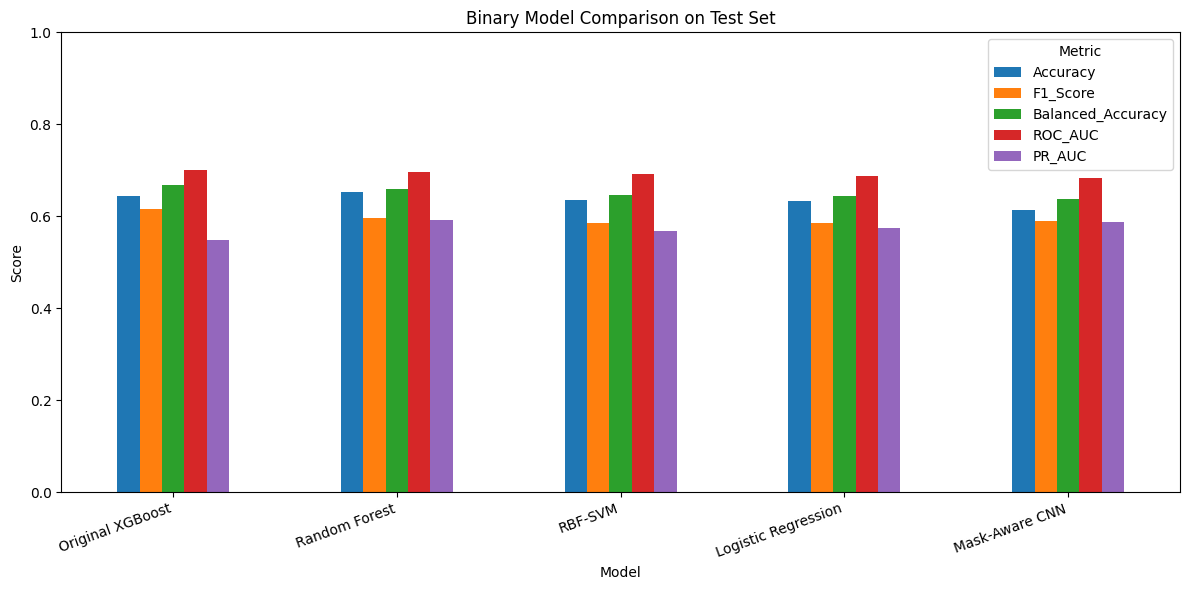

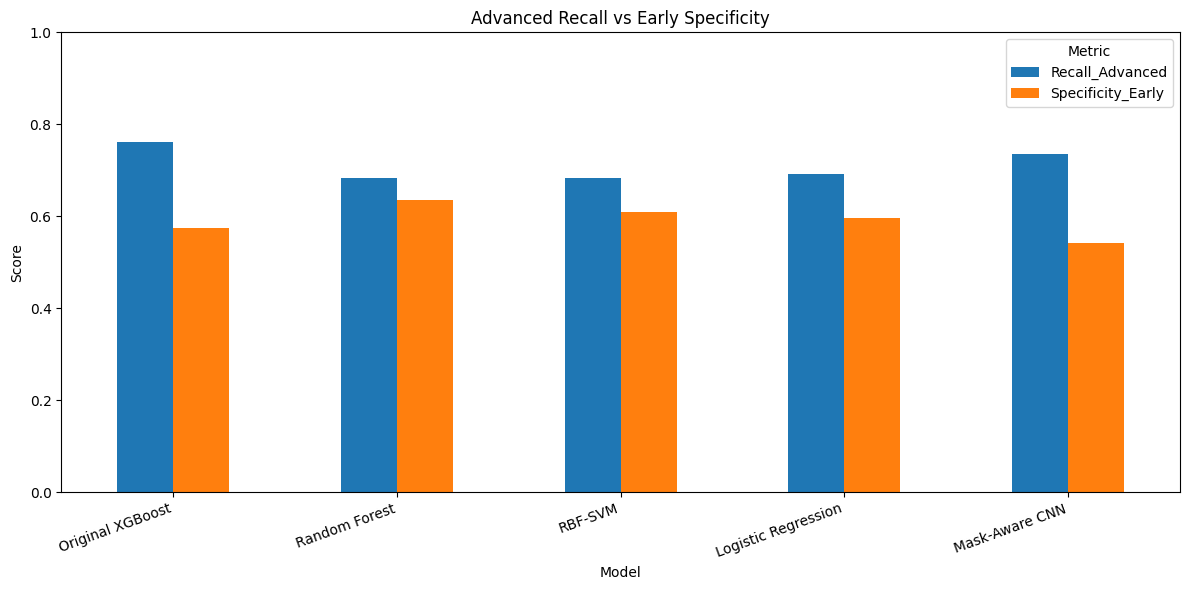

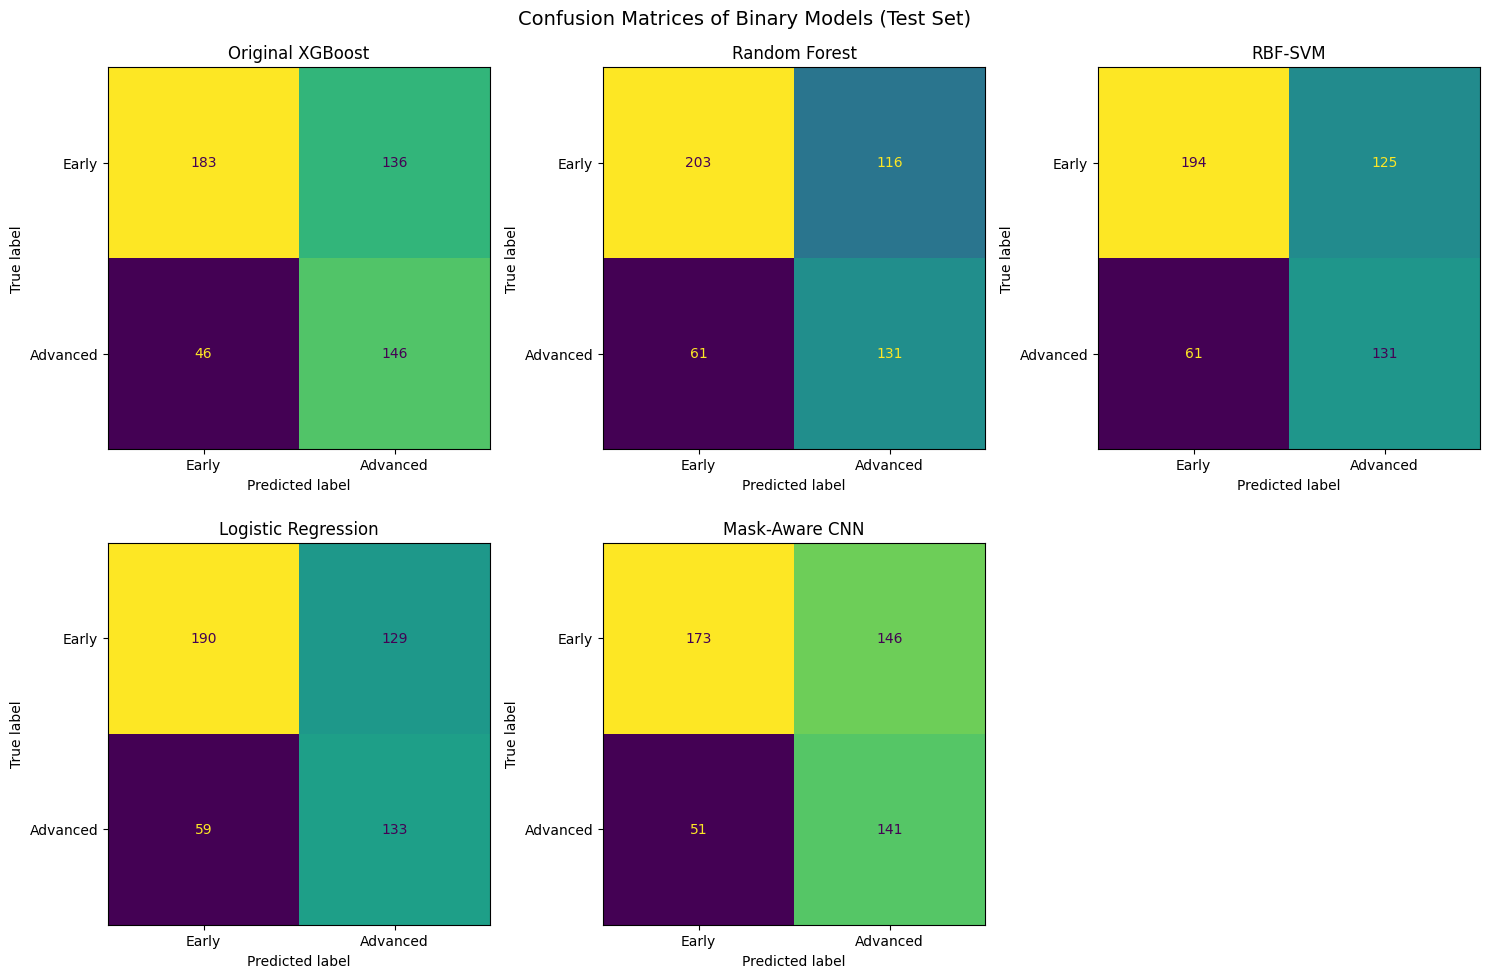

In [40]:
# Step 39 — Graphs and confusion matrices for all binary models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ---------------------------------------------------------
# 1. Rebuild test predictions where needed
# ---------------------------------------------------------

# CNN test predictions at final threshold
cnn_test_predictions = (
    np.asarray(test_probabilities).ravel() >= FINAL_DECISION_THRESHOLD
).astype(int)

# XGBoost test predictions
xgb_test_predictions_final = (
    np.asarray(xgb_test_probabilities).ravel() >= 0.50
).astype(int)

# Random Forest test predictions
rf_test_predictions_final = (
    np.asarray(rf_test_probabilities).ravel() >= 0.50
).astype(int)

# Logistic Regression test predictions
logistic_test_predictions_final = (
    np.asarray(logistic_test_probabilities).ravel() >= 0.50
).astype(int)

# SVM test predictions at final selected threshold
svm_test_predictions_final = (
    np.asarray(final_svm_test_probabilities).ravel() >= FINAL_SVM_THRESHOLD
).astype(int)

# ---------------------------------------------------------
# 2. Create final comparison table
# ---------------------------------------------------------

binary_models_summary = pd.DataFrame([
    {
        "Model": "Original XGBoost",
        "Accuracy": xgb_test_metrics["Accuracy"],
        "Precision": xgb_test_metrics["Precision"],
        "Recall_Advanced": xgb_test_metrics["Recall_Advanced"],
        "Specificity_Early": xgb_test_metrics["Specificity_Early"],
        "F1_Score": xgb_test_metrics["F1_Score"],
        "Balanced_Accuracy": xgb_test_metrics["Balanced_Accuracy"],
        "ROC_AUC": xgb_test_metrics["ROC_AUC"],
        "PR_AUC": xgb_test_metrics["PR_AUC"]
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_test_metrics["Accuracy"],
        "Precision": rf_test_metrics["Precision"],
        "Recall_Advanced": rf_test_metrics["Recall_Advanced"],
        "Specificity_Early": rf_test_metrics["Specificity_Early"],
        "F1_Score": rf_test_metrics["F1_Score"],
        "Balanced_Accuracy": rf_test_metrics["Balanced_Accuracy"],
        "ROC_AUC": rf_test_metrics["ROC_AUC"],
        "PR_AUC": rf_test_metrics["PR_AUC"]
    },
    {
        "Model": "RBF-SVM",
        "Accuracy": final_svm_test_metrics["Accuracy"],
        "Precision": final_svm_test_metrics["Precision"],
        "Recall_Advanced": final_svm_test_metrics["Recall_Advanced"],
        "Specificity_Early": final_svm_test_metrics["Specificity_Early"],
        "F1_Score": final_svm_test_metrics["F1_Score"],
        "Balanced_Accuracy": final_svm_test_metrics["Balanced_Accuracy"],
        "ROC_AUC": final_svm_test_metrics["ROC_AUC"],
        "PR_AUC": final_svm_test_metrics["PR_AUC"]
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_test_metrics["Accuracy"],
        "Precision": logistic_test_metrics["Precision"],
        "Recall_Advanced": logistic_test_metrics["Recall_Advanced"],
        "Specificity_Early": logistic_test_metrics["Specificity_Early"],
        "F1_Score": logistic_test_metrics["F1_Score"],
        "Balanced_Accuracy": logistic_test_metrics["Balanced_Accuracy"],
        "ROC_AUC": logistic_test_metrics["ROC_AUC"],
        "PR_AUC": logistic_test_metrics["PR_AUC"]
    },
    {
        "Model": "Mask-Aware CNN",
        "Accuracy": cnn_test_row["Accuracy"],
        "Precision": cnn_test_row["Precision"],
        "Recall_Advanced": cnn_test_row["Recall_Advanced"],
        "Specificity_Early": cnn_test_row["Specificity_Early"],
        "F1_Score": cnn_test_row["F1_Score"],
        "Balanced_Accuracy": cnn_test_row["Balanced_Accuracy"],
        "ROC_AUC": cnn_test_row["ROC_AUC"],
        "PR_AUC": cnn_test_row["PR_AUC"]
    }
])

display(binary_models_summary.round(4))

# ---------------------------------------------------------
# 3. Graph 1 — Main metric comparison
# ---------------------------------------------------------

plot_metrics = [
    "Accuracy",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

plot_df = binary_models_summary.set_index("Model")[plot_metrics]

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Binary Model Comparison on Test Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Graph 2 — Advanced recall vs Early specificity
# ---------------------------------------------------------

recall_specificity_df = binary_models_summary.set_index("Model")[
    ["Recall_Advanced", "Specificity_Early"]
]

recall_specificity_df.plot(kind="bar", figsize=(12, 6))
plt.title("Advanced Recall vs Early Specificity")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Confusion matrices for all models
# ---------------------------------------------------------

model_prediction_dict = {
    "Original XGBoost": xgb_test_predictions_final,
    "Random Forest": rf_test_predictions_final,
    "RBF-SVM": svm_test_predictions_final,
    "Logistic Regression": logistic_test_predictions_final,
    "Mask-Aware CNN": cnn_test_predictions
}

true_test_labels = np.asarray(y_test_xgb).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (model_name, preds) in zip(axes, model_prediction_dict.items()):
    cm = confusion_matrix(
        true_test_labels,
        preds,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Early", "Advanced"]
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

# Remove empty subplot if any
for i in range(len(model_prediction_dict), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Confusion Matrices of Binary Models (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

## Step 40 — Save Binary Model Results, Graphs and Summary

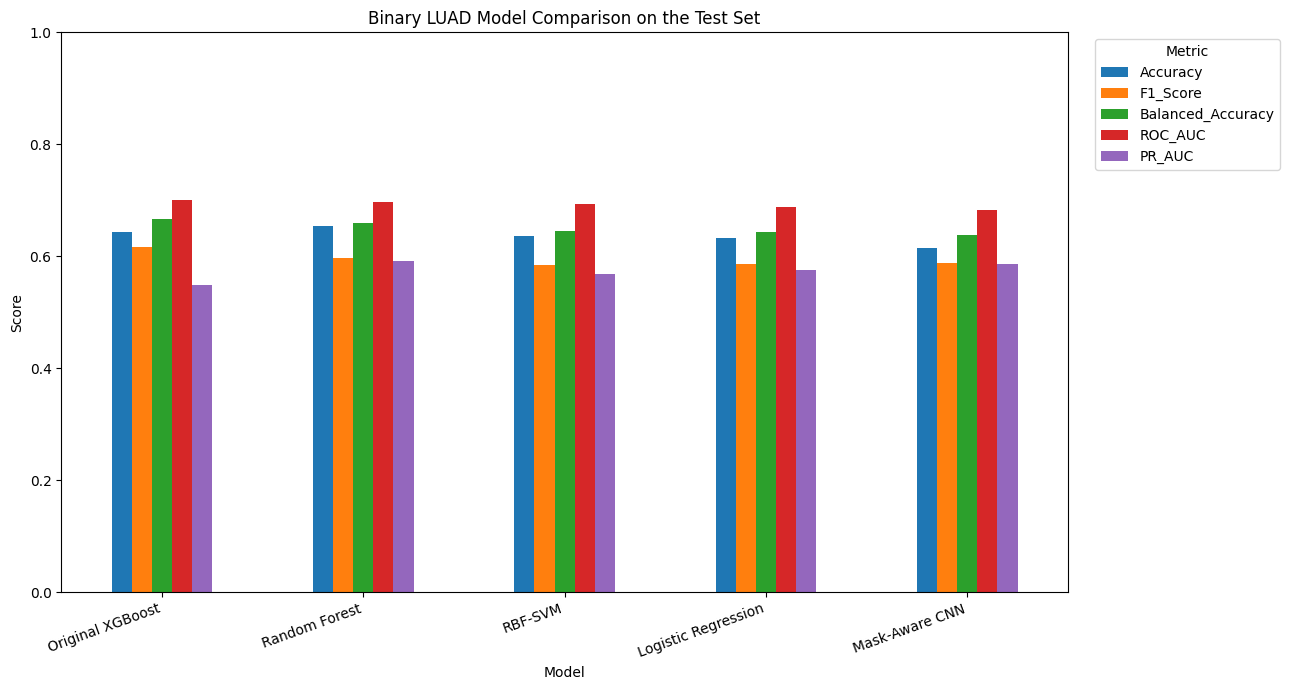

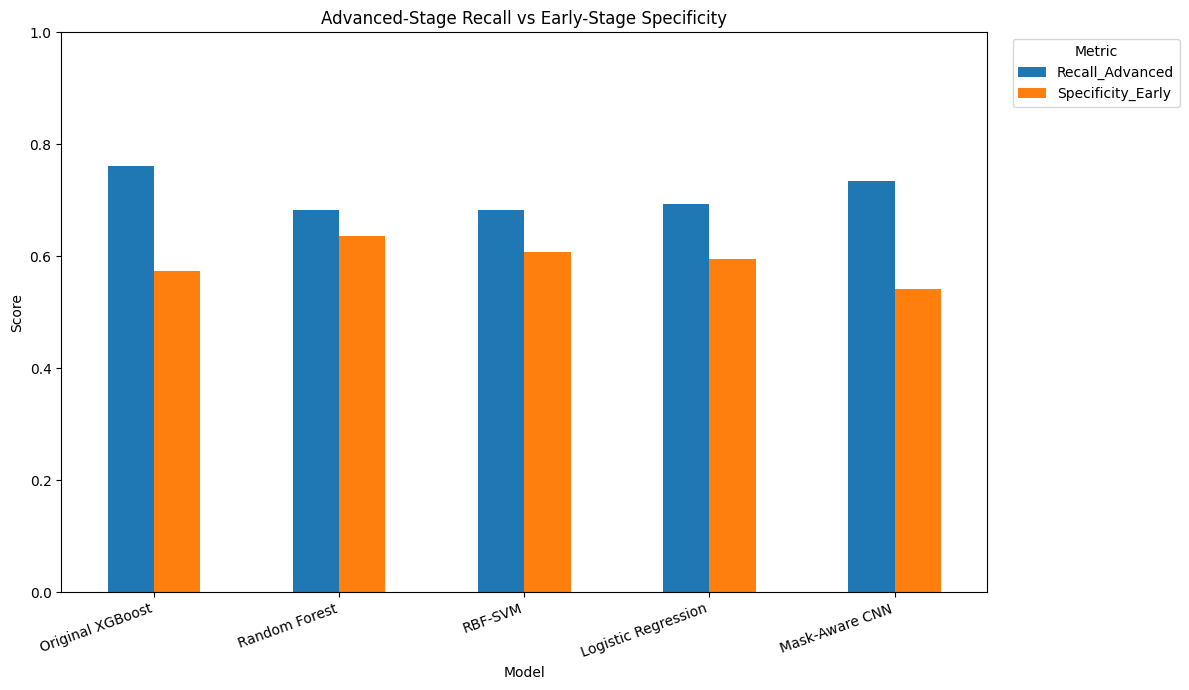

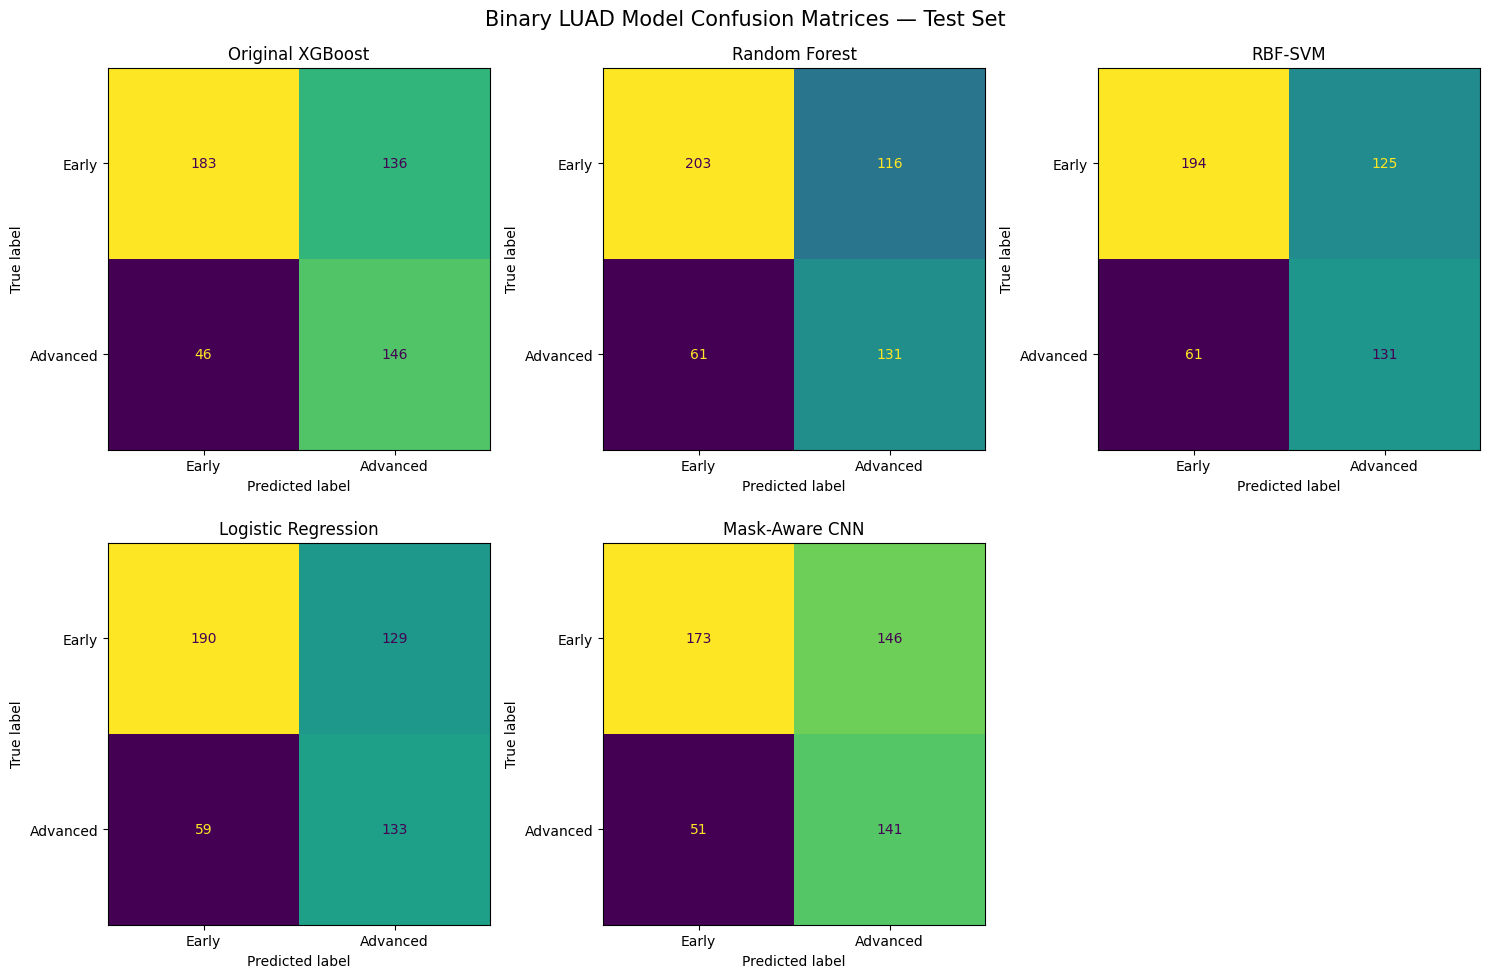


Files saved successfully:
1. Metrics CSV:
C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\binary_model_results\binary_model_comparison.csv

2. TXT summary:
C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\binary_model_results\binary_model_summary.txt

3. Main metrics graph:
C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\binary_model_results\binary_model_metrics_comparison.png

4. Recall-specificity graph:
C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\binary_model_results\binary_recall_specificity_comparison.png

5. Confusion matrices:
C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\binary_model_results\binary_models_confusion_matrices.png

Best balanced model:
Original XGBoost

Highest accuracy model:
Random Forest


In [42]:
# Step 40 — Save binary model graphs, confusion matrices and summaries

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------------
# Create fixed output folder
# ---------------------------------------------------------

BINARY_RESULTS_DIR = (
    PROJECT_DIR
    / "luad_processeed_data"
    / "binary_model_results"
)

BINARY_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Fixed file paths — rerunning overwrites the same files
METRICS_CSV_PATH = (
    BINARY_RESULTS_DIR
    / "binary_model_comparison.csv"
)

SUMMARY_TXT_PATH = (
    BINARY_RESULTS_DIR
    / "binary_model_summary.txt"
)

METRICS_GRAPH_PATH = (
    BINARY_RESULTS_DIR
    / "binary_model_metrics_comparison.png"
)

RECALL_SPECIFICITY_GRAPH_PATH = (
    BINARY_RESULTS_DIR
    / "binary_recall_specificity_comparison.png"
)

CONFUSION_MATRIX_PATH = (
    BINARY_RESULTS_DIR
    / "binary_models_confusion_matrices.png"
)


# ---------------------------------------------------------
# Rebuild final test predictions
# ---------------------------------------------------------

cnn_test_predictions_final = (
    np.asarray(test_probabilities).ravel()
    >= FINAL_DECISION_THRESHOLD
).astype(int)

xgb_test_predictions_final = (
    np.asarray(xgb_test_probabilities).ravel()
    >= 0.50
).astype(int)

rf_test_predictions_final = (
    np.asarray(rf_test_probabilities).ravel()
    >= 0.50
).astype(int)

logistic_test_predictions_final = (
    np.asarray(logistic_test_probabilities).ravel()
    >= 0.50
).astype(int)

svm_test_predictions_final = (
    np.asarray(final_svm_test_probabilities).ravel()
    >= FINAL_SVM_THRESHOLD
).astype(int)

true_test_labels = np.asarray(
    y_test_xgb
).astype(int)


# ---------------------------------------------------------
# Create final model-comparison table
# ---------------------------------------------------------

binary_models_summary = pd.DataFrame(
    [
        {
            "Model": "Original XGBoost",
            "Threshold": 0.50,
            "Accuracy": xgb_test_metrics["Accuracy"],
            "Precision": xgb_test_metrics["Precision"],
            "Recall_Advanced": xgb_test_metrics["Recall_Advanced"],
            "Specificity_Early": xgb_test_metrics["Specificity_Early"],
            "F1_Score": xgb_test_metrics["F1_Score"],
            "Balanced_Accuracy": xgb_test_metrics[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": xgb_test_metrics["ROC_AUC"],
            "PR_AUC": xgb_test_metrics["PR_AUC"]
        },
        {
            "Model": "Random Forest",
            "Threshold": 0.50,
            "Accuracy": rf_test_metrics["Accuracy"],
            "Precision": rf_test_metrics["Precision"],
            "Recall_Advanced": rf_test_metrics["Recall_Advanced"],
            "Specificity_Early": rf_test_metrics["Specificity_Early"],
            "F1_Score": rf_test_metrics["F1_Score"],
            "Balanced_Accuracy": rf_test_metrics[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": rf_test_metrics["ROC_AUC"],
            "PR_AUC": rf_test_metrics["PR_AUC"]
        },
        {
            "Model": "RBF-SVM",
            "Threshold": FINAL_SVM_THRESHOLD,
            "Accuracy": final_svm_test_metrics["Accuracy"],
            "Precision": final_svm_test_metrics["Precision"],
            "Recall_Advanced": final_svm_test_metrics[
                "Recall_Advanced"
            ],
            "Specificity_Early": final_svm_test_metrics[
                "Specificity_Early"
            ],
            "F1_Score": final_svm_test_metrics["F1_Score"],
            "Balanced_Accuracy": final_svm_test_metrics[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": final_svm_test_metrics["ROC_AUC"],
            "PR_AUC": final_svm_test_metrics["PR_AUC"]
        },
        {
            "Model": "Logistic Regression",
            "Threshold": 0.50,
            "Accuracy": logistic_test_metrics["Accuracy"],
            "Precision": logistic_test_metrics["Precision"],
            "Recall_Advanced": logistic_test_metrics[
                "Recall_Advanced"
            ],
            "Specificity_Early": logistic_test_metrics[
                "Specificity_Early"
            ],
            "F1_Score": logistic_test_metrics["F1_Score"],
            "Balanced_Accuracy": logistic_test_metrics[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": logistic_test_metrics["ROC_AUC"],
            "PR_AUC": logistic_test_metrics["PR_AUC"]
        },
        {
            "Model": "Mask-Aware CNN",
            "Threshold": FINAL_DECISION_THRESHOLD,
            "Accuracy": cnn_test_row["Accuracy"],
            "Precision": cnn_test_row["Precision"],
            "Recall_Advanced": cnn_test_row["Recall_Advanced"],
            "Specificity_Early": cnn_test_row["Specificity_Early"],
            "F1_Score": cnn_test_row["F1_Score"],
            "Balanced_Accuracy": cnn_test_row[
                "Balanced_Accuracy"
            ],
            "ROC_AUC": cnn_test_row["ROC_AUC"],
            "PR_AUC": cnn_test_row["PR_AUC"]
        }
    ]
)

binary_models_summary = (
    binary_models_summary
    .sort_values(
        ["Balanced_Accuracy", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

# Save comparison CSV
binary_models_summary.to_csv(
    METRICS_CSV_PATH,
    index=False,
    mode="w"
)


# ---------------------------------------------------------
# Graph 1 — Main model metrics
# ---------------------------------------------------------

main_metric_columns = [
    "Accuracy",
    "F1_Score",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]

main_plot_df = binary_models_summary.set_index(
    "Model"
)[main_metric_columns]

ax = main_plot_df.plot(
    kind="bar",
    figsize=(13, 7)
)

ax.set_title(
    "Binary LUAD Model Comparison on the Test Set"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    METRICS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# Graph 2 — Advanced recall vs Early specificity
# ---------------------------------------------------------

recall_specificity_df = binary_models_summary.set_index(
    "Model"
)[
    [
        "Recall_Advanced",
        "Specificity_Early"
    ]
]

ax = recall_specificity_df.plot(
    kind="bar",
    figsize=(12, 7)
)

ax.set_title(
    "Advanced-Stage Recall vs Early-Stage Specificity"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    RECALL_SPECIFICITY_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# Confusion matrices
# ---------------------------------------------------------

model_predictions = {
    "Original XGBoost": xgb_test_predictions_final,
    "Random Forest": rf_test_predictions_final,
    "RBF-SVM": svm_test_predictions_final,
    "Logistic Regression": logistic_test_predictions_final,
    "Mask-Aware CNN": cnn_test_predictions_final
}

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

axes = axes.flatten()

confusion_matrix_records = []

for axis, (model_name, predictions) in zip(
    axes,
    model_predictions.items()
):
    cm = confusion_matrix(
        true_test_labels,
        predictions,
        labels=[0, 1]
    )

    tn, fp, fn, tp = cm.ravel()

    confusion_matrix_records.append(
        {
            "Model": model_name,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        }
    )

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Early",
            "Advanced"
        ]
    )

    display_object.plot(
        ax=axis,
        colorbar=False
    )

    axis.set_title(model_name)

# Remove unused subplot
for index in range(
    len(model_predictions),
    len(axes)
):
    fig.delaxes(axes[index])

fig.suptitle(
    "Binary LUAD Model Confusion Matrices — Test Set",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

confusion_matrix_summary = pd.DataFrame(
    confusion_matrix_records
)


# ---------------------------------------------------------
# Create detailed TXT summary
# ---------------------------------------------------------

best_balanced_model = binary_models_summary.iloc[0]

highest_accuracy_row = binary_models_summary.loc[
    binary_models_summary[
        "Accuracy"
    ].idxmax()
]

summary_lines = [
    "LUAD BINARY CLASSIFICATION MODEL SUMMARY",
    "=" * 75,
    "",
    f"Total test patients: {len(true_test_labels)}",
    "Positive class: Advanced = 1",
    "Negative class: Early = 0",
    "",
    "BEST MODEL BY BALANCED ACCURACY",
    "-" * 75,
    f"Model: {best_balanced_model['Model']}",
    f"Threshold: {best_balanced_model['Threshold']:.2f}",
    f"Accuracy: {best_balanced_model['Accuracy']:.4f}",
    f"Precision: {best_balanced_model['Precision']:.4f}",
    f"Advanced recall: "
    f"{best_balanced_model['Recall_Advanced']:.4f}",
    f"Early specificity: "
    f"{best_balanced_model['Specificity_Early']:.4f}",
    f"F1-score: {best_balanced_model['F1_Score']:.4f}",
    f"Balanced accuracy: "
    f"{best_balanced_model['Balanced_Accuracy']:.4f}",
    f"ROC-AUC: {best_balanced_model['ROC_AUC']:.4f}",
    f"PR-AUC: {best_balanced_model['PR_AUC']:.4f}",
    "",
    "HIGHEST TEST ACCURACY",
    "-" * 75,
    f"Model: {highest_accuracy_row['Model']}",
    f"Accuracy: {highest_accuracy_row['Accuracy']:.4f}",
    "",
    "ALL MODEL METRICS",
    "-" * 75,
    binary_models_summary.round(4).to_string(index=False),
    "",
    "CONFUSION-MATRIX COUNTS",
    "-" * 75,
    confusion_matrix_summary.to_string(index=False),
    "",
    "FEATURE POLICY",
    "-" * 75,
    "Primary tabular inputs:",
    "- 89 active LUAD gene indicators",
    "- Mutation severity summaries",
    "- Mutation burden summaries",
    "- Sex",
    "- Age and age-missing indicator",
    "",
    "Mask-Aware CNN additional inputs:",
    "- Reference DNA windows",
    "- Mutated DNA windows",
    "- Mutation-position masks",
    "- Per-window severity",
    "",
    "Excluded from primary model inputs:",
    "- Cohort",
    "- Smoking history",
    "- Pack-years",
    "- Passive smoking",
    "- Stage-label columns",
    "- Seven constant/all-zero gene columns",
    "",
    "INTERPRETATION NOTE",
    "-" * 75,
    "Original XGBoost achieved the highest test balanced accuracy.",
    "Random Forest achieved the highest conventional test accuracy.",
    "Metrics should be interpreted together because the classes are imbalanced."
]

with open(
    SUMMARY_TXT_PATH,
    mode="w",
    encoding="utf-8"
) as summary_file:
    summary_file.write(
        "\n".join(summary_lines)
    )


# ---------------------------------------------------------
# Final verification
# ---------------------------------------------------------

print("\nFiles saved successfully:")

print("1. Metrics CSV:")
print(METRICS_CSV_PATH)

print("\n2. TXT summary:")
print(SUMMARY_TXT_PATH)

print("\n3. Main metrics graph:")
print(METRICS_GRAPH_PATH)

print("\n4. Recall-specificity graph:")
print(RECALL_SPECIFICITY_GRAPH_PATH)

print("\n5. Confusion matrices:")
print(CONFUSION_MATRIX_PATH)

print("\nBest balanced model:")
print(best_balanced_model["Model"])

print("\nHighest accuracy model:")
print(highest_accuracy_row["Model"])

## Step 41 — Prepare Four-Class Stage Labels and Class Weights

The same patient-level training, validation and test splits are reused for Stage I, Stage II, Stage III and Stage IV classification. Class weights are calculated using only the training set to reduce class-imbalance bias.

In [43]:
# Step 41 — Prepare four-class labels and training-only class weights

from sklearn.utils.class_weight import compute_class_weight

FOUR_CLASS_TARGET = "label_stage_4class"

STAGE_CLASS_NAMES = {
    0: "Stage I",
    1: "Stage II",
    2: "Stage III",
    3: "Stage IV"
}

# ---------------------------------------------------------
# Extract labels from the existing fixed splits
# ---------------------------------------------------------

y_train_4class = train_df[
    FOUR_CLASS_TARGET
].to_numpy(dtype=np.int32)

y_validation_4class = validation_df[
    FOUR_CLASS_TARGET
].to_numpy(dtype=np.int32)

y_test_4class = test_df[
    FOUR_CLASS_TARGET
].to_numpy(dtype=np.int32)


# ---------------------------------------------------------
# Calculate class weights using training labels only
# ---------------------------------------------------------

four_class_ids = np.sort(
    np.unique(y_train_4class)
)

four_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=four_class_ids,
    y=y_train_4class
)

four_class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        four_class_ids,
        four_class_weight_values
    )
}


# ---------------------------------------------------------
# Create split-distribution summary
# ---------------------------------------------------------

distribution_rows = []

for split_name, labels in [
    ("Training", y_train_4class),
    ("Validation", y_validation_4class),
    ("Test", y_test_4class)
]:
    row = {
        "Split": split_name,
        "Patients": len(labels)
    }

    for class_id, class_name in STAGE_CLASS_NAMES.items():
        row[class_name] = int(
            (labels == class_id).sum()
        )

        row[f"{class_name} %"] = round(
            (labels == class_id).mean() * 100,
            2
        )

    distribution_rows.append(row)

four_class_distribution_df = pd.DataFrame(
    distribution_rows
)


# ---------------------------------------------------------
# Validation output
# ---------------------------------------------------------

print("Four-class label mapping:")

for class_id, class_name in STAGE_CLASS_NAMES.items():
    print(f"{class_id} = {class_name}")

print("\nTraining-only class weights:")

for class_id, weight in four_class_weights.items():
    print(
        f"{STAGE_CLASS_NAMES[class_id]}:",
        round(weight, 4)
    )

print("\nFour-class distribution by split:")
display(four_class_distribution_df)

print("\nLabel shapes:")
print("Training:", y_train_4class.shape)
print("Validation:", y_validation_4class.shape)
print("Test:", y_test_4class.shape)

print("\nUnique training labels:")
print(np.unique(y_train_4class))

Four-class label mapping:
0 = Stage I
1 = Stage II
2 = Stage III
3 = Stage IV

Training-only class weights:
Stage I: 0.5363
Stage II: 1.6326
Stage III: 1.8354
Stage IV: 1.0225

Four-class distribution by split:


,Split,Patients,Stage I,Stage I %,Stage II,Stage II %,Stage III,Stage III %,Stage IV,Stage IV %
0,Training,2364,1102,46.62,362,15.31,322,13.62,578,24.45
1,Validation,507,234,46.15,79,15.58,78,15.38,116,22.88
2,Test,511,249,48.73,70,13.70,75,14.68,117,22.90



Label shapes:
Training: (2364,)
Validation: (507,)
Test: (511,)

Unique training labels:
[0 1 2 3]


## Step 42 — Train the Four-Class XGBoost Stage Classification Model

The XGBoost model predicts Stage I, Stage II, Stage III and Stage IV using the same 100 gene, mutation and clinical features. Training-only class weights are applied to reduce class imbalance.

In [44]:
# Step 42 — Train four-class XGBoost using training-only sample weights

# ---------------------------------------------------------
# Create per-patient sample weights from training classes
# ---------------------------------------------------------

train_sample_weights_4class = np.array(
    [
        four_class_weights[int(label)]
        for label in y_train_4class
    ],
    dtype=np.float32
)

print("Training sample-weight range:")
print(
    train_sample_weights_4class.min(),
    "to",
    train_sample_weights_4class.max()
)


# ---------------------------------------------------------
# Build four-class XGBoost model
# ---------------------------------------------------------

xgb_4class_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=4,

    n_estimators=1000,
    learning_rate=0.03,

    max_depth=3,
    min_child_weight=5,

    subsample=0.85,
    colsample_bytree=0.80,

    gamma=0.0,
    reg_alpha=0.30,
    reg_lambda=4.00,

    eval_metric="mlogloss",
    tree_method="hist",

    early_stopping_rounds=50,

    random_state=42,
    n_jobs=-1
)


# ---------------------------------------------------------
# Train using validation set for early stopping
# ---------------------------------------------------------

xgb_4class_model.fit(
    X_train_xgb,
    y_train_4class,

    sample_weight=train_sample_weights_4class,

    eval_set=[
        (
            X_validation_xgb,
            y_validation_4class
        )
    ],

    verbose=25
)


# ---------------------------------------------------------
# Training summary
# ---------------------------------------------------------

print("\nFour-class XGBoost training completed.")

print(
    "Best boosting iteration:",
    xgb_4class_model.best_iteration
)

print(
    "Best validation multiclass log-loss:",
    round(
        float(xgb_4class_model.best_score),
        4
    )
)

print(
    "Number of output classes:",
    xgb_4class_model.n_classes_
)

print(
    "Input features:",
    xgb_4class_model.n_features_in_
)

Training sample-weight range:
0.5362976 to 1.8354037
[0]	validation_0-mlogloss:1.38519
[25]	validation_0-mlogloss:1.36210
[50]	validation_0-mlogloss:1.35063
[75]	validation_0-mlogloss:1.34363
[100]	validation_0-mlogloss:1.33791
[125]	validation_0-mlogloss:1.33469
[150]	validation_0-mlogloss:1.33085
[175]	validation_0-mlogloss:1.32901
[200]	validation_0-mlogloss:1.32796
[225]	validation_0-mlogloss:1.32751
[250]	validation_0-mlogloss:1.32550
[275]	validation_0-mlogloss:1.32384
[300]	validation_0-mlogloss:1.32360
[325]	validation_0-mlogloss:1.32410
[337]	validation_0-mlogloss:1.32378

Four-class XGBoost training completed.
Best boosting iteration: 287
Best validation multiclass log-loss: 1.3231
Number of output classes: 4
Input features: 100


## Step 43 — Evaluate Four-Class XGBoost Performance

The trained model is evaluated for Stage I, Stage II, Stage III and Stage IV prediction using accuracy, balanced accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, multiclass ROC-AUC and log-loss.

In [45]:
# Step 43 — Evaluate four-class XGBoost on all data splits

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize


def evaluate_four_class_model(
    model,
    features,
    true_labels,
    split_name
):
    # Predicted probability for each of the four stages
    probabilities = model.predict_proba(features)

    # Select stage with highest probability
    predictions = np.argmax(
        probabilities,
        axis=1
    )

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    # One-hot labels required for multiclass ROC-AUC
    true_labels_one_hot = label_binarize(
        true_labels,
        classes=[0, 1, 2, 3]
    )

    metrics = {
        "Split": split_name,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "Macro_Precision": precision_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro_Recall": recall_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro_F1": f1_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Weighted_F1": f1_score(
            true_labels,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Macro_ROC_AUC_OVR": roc_auc_score(
            true_labels_one_hot,
            probabilities,
            multi_class="ovr",
            average="macro"
        ),

        "Log_Loss": log_loss(
            true_labels,
            probabilities,
            labels=[0, 1, 2, 3]
        )
    }

    matrix = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1, 2, 3]
    )

    return metrics, probabilities, predictions, matrix


# Evaluate training split
xgb_4class_train_metrics, \
xgb_4class_train_probabilities, \
xgb_4class_train_predictions, \
xgb_4class_train_cm = evaluate_four_class_model(
    xgb_4class_model,
    X_train_xgb,
    y_train_4class,
    "Training"
)

# Evaluate validation split
xgb_4class_validation_metrics, \
xgb_4class_validation_probabilities, \
xgb_4class_validation_predictions, \
xgb_4class_validation_cm = evaluate_four_class_model(
    xgb_4class_model,
    X_validation_xgb,
    y_validation_4class,
    "Validation"
)

# Evaluate untouched test split
xgb_4class_test_metrics, \
xgb_4class_test_probabilities, \
xgb_4class_test_predictions, \
xgb_4class_test_cm = evaluate_four_class_model(
    xgb_4class_model,
    X_test_xgb,
    y_test_4class,
    "Test"
)


xgb_4class_metrics_table = pd.DataFrame(
    [
        xgb_4class_train_metrics,
        xgb_4class_validation_metrics,
        xgb_4class_test_metrics
    ]
)

print("Four-Class XGBoost Performance:")

display(
    xgb_4class_metrics_table.round(4)
)

print("\nTest confusion-matrix counts:")

test_confusion_matrix_df = pd.DataFrame(
    xgb_4class_test_cm,
    index=[
        "Actual Stage I",
        "Actual Stage II",
        "Actual Stage III",
        "Actual Stage IV"
    ],
    columns=[
        "Predicted Stage I",
        "Predicted Stage II",
        "Predicted Stage III",
        "Predicted Stage IV"
    ]
)

display(test_confusion_matrix_df)

print("\nTest majority-class baseline accuracy:")

test_majority_baseline_4class = max(
    np.mean(y_test_4class == class_id)
    for class_id in [0, 1, 2, 3]
)

print(
    round(
        float(test_majority_baseline_4class),
        4
    )
)

Four-Class XGBoost Performance:


,Split,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Macro_ROC_AUC_OVR,Log_Loss
0,Training,0.5034,0.4885,0.4746,0.4885,0.4715,0.5073,0.7535,1.2158
1,Validation,0.3905,0.3560,0.3547,0.3560,0.3432,0.3927,0.6021,1.3231
2,Test,0.4031,0.3684,0.3612,0.3684,0.3481,0.4126,0.6206,1.3239



Test confusion-matrix counts:


,Predicted Stage I,Predicted Stage II,Predicted Stage III,Predicted Stage IV
Actual Stage I,102,53,24,70
Actual Stage II,22,18,11,19
Actual Stage III,11,18,15,31
Actual Stage IV,19,13,14,71



Test majority-class baseline accuracy:
0.4873


## Step 44 — Train the Four-Class Random Forest Model

The Random Forest model predicts Stage I, Stage II, Stage III and Stage IV using the same 100 tabular features and fixed patient-level data splits. Balanced class weights are used to reduce dominance by Stage I.

In [46]:
# Step 44 — Train four-class Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_4class_model = RandomForestClassifier(
    n_estimators=600,

    # Control overfitting
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=3,

    # Random feature subset for each split
    max_features="sqrt",

    # Handle four-class imbalance
    class_weight="balanced_subsample",

    bootstrap=True,
    oob_score=True,

    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_4class_model.fit(
    X_train_xgb,
    y_train_4class
)

print("Four-class Random Forest training completed.")

print(
    "Number of trees:",
    rf_4class_model.n_estimators
)

print(
    "Input features:",
    rf_4class_model.n_features_in_
)

print(
    "Output classes:",
    rf_4class_model.classes_
)

print(
    "Out-of-bag accuracy:",
    round(
        float(rf_4class_model.oob_score_),
        4
    )
)

Four-class Random Forest training completed.
Number of trees: 600
Input features: 100
Output classes: [0 1 2 3]
Out-of-bag accuracy: 0.4353


## Step 45 — Evaluate Four-Class Random Forest Performance

The trained Random Forest is evaluated on the training, validation and untouched test sets using accuracy, balanced accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, multiclass ROC-AUC and log-loss.

In [47]:
# Step 45 — Evaluate four-class Random Forest

def evaluate_four_class_random_forest(
    model,
    features,
    true_labels,
    split_name
):
    probabilities = model.predict_proba(features)

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    true_labels_one_hot = label_binarize(
        true_labels,
        classes=[0, 1, 2, 3]
    )

    metrics = {
        "Split": split_name,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "Macro_Precision": precision_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro_Recall": recall_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro_F1": f1_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Weighted_F1": f1_score(
            true_labels,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Macro_ROC_AUC_OVR": roc_auc_score(
            true_labels_one_hot,
            probabilities,
            multi_class="ovr",
            average="macro"
        ),

        "Log_Loss": log_loss(
            true_labels,
            probabilities,
            labels=[0, 1, 2, 3]
        )
    }

    matrix = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1, 2, 3]
    )

    return metrics, probabilities, predictions, matrix


rf_4class_train_metrics, \
rf_4class_train_probabilities, \
rf_4class_train_predictions, \
rf_4class_train_cm = evaluate_four_class_random_forest(
    rf_4class_model,
    X_train_xgb,
    y_train_4class,
    "Training"
)

rf_4class_validation_metrics, \
rf_4class_validation_probabilities, \
rf_4class_validation_predictions, \
rf_4class_validation_cm = evaluate_four_class_random_forest(
    rf_4class_model,
    X_validation_xgb,
    y_validation_4class,
    "Validation"
)

rf_4class_test_metrics, \
rf_4class_test_probabilities, \
rf_4class_test_predictions, \
rf_4class_test_cm = evaluate_four_class_random_forest(
    rf_4class_model,
    X_test_xgb,
    y_test_4class,
    "Test"
)


rf_4class_metrics_table = pd.DataFrame(
    [
        rf_4class_train_metrics,
        rf_4class_validation_metrics,
        rf_4class_test_metrics
    ]
)

print("Four-Class Random Forest Performance:")

display(
    rf_4class_metrics_table.round(4)
)


print("\nTest confusion-matrix counts:")

rf_test_confusion_matrix_df = pd.DataFrame(
    rf_4class_test_cm,
    index=[
        "Actual Stage I",
        "Actual Stage II",
        "Actual Stage III",
        "Actual Stage IV"
    ],
    columns=[
        "Predicted Stage I",
        "Predicted Stage II",
        "Predicted Stage III",
        "Predicted Stage IV"
    ]
)

display(rf_test_confusion_matrix_df)


# Per-class recall
rf_per_class_recall = recall_score(
    y_test_4class,
    rf_4class_test_predictions,
    labels=[0, 1, 2, 3],
    average=None,
    zero_division=0
)

rf_per_stage_recall_df = pd.DataFrame(
    {
        "Stage": [
            "Stage I",
            "Stage II",
            "Stage III",
            "Stage IV"
        ],
        "Recall": rf_per_class_recall
    }
)

print("\nTest recall by stage:")
display(rf_per_stage_recall_df.round(4))


print(
    "\nTest majority-class baseline accuracy:",
    round(
        float(test_majority_baseline_4class),
        4
    )
)

Four-Class Random Forest Performance:


,Split,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Macro_ROC_AUC_OVR,Log_Loss
0,Training,0.6248,0.6018,0.6294,0.6018,0.6048,0.6269,0.8498,1.1678
1,Validation,0.4221,0.3671,0.3604,0.3671,0.3481,0.4097,0.6218,1.3077
2,Test,0.4599,0.4013,0.3998,0.4013,0.3777,0.4527,0.6531,1.3001



Test confusion-matrix counts:


,Predicted Stage I,Predicted Stage II,Predicted Stage III,Predicted Stage IV
Actual Stage I,122,36,16,75
Actual Stage II,23,16,7,24
Actual Stage III,17,12,12,34
Actual Stage IV,23,7,2,85



Test recall by stage:


,Stage,Recall
0,Stage I,0.4900
1,Stage II,0.2286
2,Stage III,0.1600
3,Stage IV,0.7265



Test majority-class baseline accuracy: 0.4873


## Step 46 — Train the Four-Class Multinomial Logistic Regression Model

A multinomial Logistic Regression model provides an interpretable linear baseline for Stage I, Stage II, Stage III and Stage IV prediction using the same 100 tabular features.

In [48]:
# Step 46 — Train four-class Multinomial Logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_4class_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,

                # Training-only four-class weights
                class_weight=four_class_weights,

                # Supports multinomial classification
                solver="lbfgs",

                max_iter=3000,
                random_state=42
            )
        )
    ]
)

logistic_4class_model.fit(
    X_train_xgb,
    y_train_4class
)

trained_classifier = logistic_4class_model.named_steps[
    "classifier"
]

print("Four-class Logistic Regression training completed.")

print(
    "Training patients:",
    X_train_xgb.shape[0]
)

print(
    "Input features:",
    X_train_xgb.shape[1]
)

print(
    "Output classes:",
    trained_classifier.classes_
)

print(
    "Iterations completed:",
    trained_classifier.n_iter_
)

Four-class Logistic Regression training completed.
Training patients: 2364
Input features: 100
Output classes: [0 1 2 3]
Iterations completed: [44]


## Step 47 — Evaluate Four-Class Logistic Regression Performance

The trained multinomial Logistic Regression model is evaluated on the training, validation and test sets using the same multiclass metrics as XGBoost and Random Forest.

In [49]:
# Step 47 — Evaluate four-class Logistic Regression

logistic_4class_train_metrics, \
logistic_4class_train_probabilities, \
logistic_4class_train_predictions, \
logistic_4class_train_cm = evaluate_four_class_model(
    logistic_4class_model,
    X_train_xgb,
    y_train_4class,
    "Training"
)

logistic_4class_validation_metrics, \
logistic_4class_validation_probabilities, \
logistic_4class_validation_predictions, \
logistic_4class_validation_cm = evaluate_four_class_model(
    logistic_4class_model,
    X_validation_xgb,
    y_validation_4class,
    "Validation"
)

logistic_4class_test_metrics, \
logistic_4class_test_probabilities, \
logistic_4class_test_predictions, \
logistic_4class_test_cm = evaluate_four_class_model(
    logistic_4class_model,
    X_test_xgb,
    y_test_4class,
    "Test"
)


# Combine performance metrics
logistic_4class_metrics_table = pd.DataFrame(
    [
        logistic_4class_train_metrics,
        logistic_4class_validation_metrics,
        logistic_4class_test_metrics
    ]
)

print("Four-Class Logistic Regression Performance:")

display(
    logistic_4class_metrics_table.round(4)
)


# Test confusion matrix
print("\nTest confusion-matrix counts:")

logistic_4class_test_cm_df = pd.DataFrame(
    logistic_4class_test_cm,
    index=[
        "Actual Stage I",
        "Actual Stage II",
        "Actual Stage III",
        "Actual Stage IV"
    ],
    columns=[
        "Predicted Stage I",
        "Predicted Stage II",
        "Predicted Stage III",
        "Predicted Stage IV"
    ]
)

display(logistic_4class_test_cm_df)


# Per-stage recall
logistic_4class_stage_recall = recall_score(
    y_test_4class,
    logistic_4class_test_predictions,
    labels=[0, 1, 2, 3],
    average=None,
    zero_division=0
)

logistic_4class_stage_recall_df = pd.DataFrame(
    {
        "Stage": [
            "Stage I",
            "Stage II",
            "Stage III",
            "Stage IV"
        ],
        "Recall": logistic_4class_stage_recall
    }
)

print("\nTest recall by stage:")

display(
    logistic_4class_stage_recall_df.round(4)
)


print(
    "\nTest majority-class baseline accuracy:",
    round(
        float(test_majority_baseline_4class),
        4
    )
)

Four-Class Logistic Regression Performance:


,Split,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Macro_ROC_AUC_OVR,Log_Loss
0,Training,0.4298,0.4123,0.3969,0.4123,0.3950,0.4382,0.6896,1.2446
1,Validation,0.3708,0.3262,0.3193,0.3262,0.3179,0.3754,0.5897,1.4625
2,Test,0.3640,0.3216,0.3218,0.3216,0.3045,0.3778,0.5860,1.5074



Test confusion-matrix counts:


,Predicted Stage I,Predicted Stage II,Predicted Stage III,Predicted Stage IV
Actual Stage I,95,50,33,71
Actual Stage II,25,13,12,20
Actual Stage III,13,19,11,32
Actual Stage IV,11,21,18,67



Test recall by stage:


,Stage,Recall
0,Stage I,0.3815
1,Stage II,0.1857
2,Stage III,0.1467
3,Stage IV,0.5726



Test majority-class baseline accuracy: 0.4873


## Step 48 — Train the Four-Class RBF-SVM Model

The RBF-SVM model captures nonlinear relationships between LUAD gene indicators, mutation summaries, sex and age. Training-only class weights are used to reduce stage imbalance.

In [50]:
# Step 48 — Train four-class RBF-SVM

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_4class_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",

                # Four-class weights calculated from training data
                class_weight=four_class_weights,

                # Needed for multiclass ROC-AUC and log-loss
                probability=True,

                decision_function_shape="ovr",
                random_state=42,
                cache_size=2000
            )
        )
    ]
)

svm_4class_model.fit(
    X_train_xgb,
    y_train_4class
)

trained_svm_4class = svm_4class_model.named_steps[
    "classifier"
]

print("Four-class RBF-SVM training completed.")

print(
    "Training patients:",
    X_train_xgb.shape[0]
)

print(
    "Input features:",
    X_train_xgb.shape[1]
)

print(
    "Output classes:",
    trained_svm_4class.classes_
)

print(
    "Support vectors per class:",
    trained_svm_4class.n_support_
)

print(
    "Total support vectors:",
    int(trained_svm_4class.n_support_.sum())
)

Four-class RBF-SVM training completed.
Training patients: 2364
Input features: 100
Output classes: [0 1 2 3]
Support vectors per class: [1080  359  322  547]
Total support vectors: 2308


## Step 49 — Evaluate Four-Class RBF-SVM Performance

The trained four-class RBF-SVM is evaluated on the training, validation and test sets using accuracy, balanced accuracy, macro-F1, multiclass ROC-AUC and stage-wise recall.

In [51]:
# Step 49 — Evaluate four-class RBF-SVM

svm_4class_train_metrics, \
svm_4class_train_probabilities, \
svm_4class_train_predictions, \
svm_4class_train_cm = evaluate_four_class_model(
    svm_4class_model,
    X_train_xgb,
    y_train_4class,
    "Training"
)

svm_4class_validation_metrics, \
svm_4class_validation_probabilities, \
svm_4class_validation_predictions, \
svm_4class_validation_cm = evaluate_four_class_model(
    svm_4class_model,
    X_validation_xgb,
    y_validation_4class,
    "Validation"
)

svm_4class_test_metrics, \
svm_4class_test_probabilities, \
svm_4class_test_predictions, \
svm_4class_test_cm = evaluate_four_class_model(
    svm_4class_model,
    X_test_xgb,
    y_test_4class,
    "Test"
)


svm_4class_metrics_table = pd.DataFrame(
    [
        svm_4class_train_metrics,
        svm_4class_validation_metrics,
        svm_4class_test_metrics
    ]
)

print("Four-Class RBF-SVM Performance:")

display(
    svm_4class_metrics_table.round(4)
)


# Test confusion matrix
print("\nTest confusion-matrix counts:")

svm_4class_test_cm_df = pd.DataFrame(
    svm_4class_test_cm,
    index=[
        "Actual Stage I",
        "Actual Stage II",
        "Actual Stage III",
        "Actual Stage IV"
    ],
    columns=[
        "Predicted Stage I",
        "Predicted Stage II",
        "Predicted Stage III",
        "Predicted Stage IV"
    ]
)

display(svm_4class_test_cm_df)


# Per-stage recall
svm_4class_stage_recall = recall_score(
    y_test_4class,
    svm_4class_test_predictions,
    labels=[0, 1, 2, 3],
    average=None,
    zero_division=0
)

svm_4class_stage_recall_df = pd.DataFrame(
    {
        "Stage": [
            "Stage I",
            "Stage II",
            "Stage III",
            "Stage IV"
        ],
        "Recall": svm_4class_stage_recall
    }
)

print("\nTest recall by stage:")

display(
    svm_4class_stage_recall_df.round(4)
)

print(
    "\nTest majority-class baseline accuracy:",
    round(float(test_majority_baseline_4class), 4)
)

Four-Class RBF-SVM Performance:


,Split,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Macro_ROC_AUC_OVR,Log_Loss
0,Training,0.5389,0.3459,0.5259,0.3459,0.2992,0.4399,0.7832,1.0815
1,Validation,0.4576,0.2837,0.2110,0.2837,0.2329,0.3555,0.6298,1.2158
2,Test,0.5127,0.3118,0.2431,0.3118,0.2656,0.4139,0.6459,1.1721



Test confusion-matrix counts:


,Predicted Stage I,Predicted Stage II,Predicted Stage III,Predicted Stage IV
Actual Stage I,219,0,0,30
Actual Stage II,63,0,0,7
Actual Stage III,58,0,0,17
Actual Stage IV,74,0,0,43



Test recall by stage:


,Stage,Recall
0,Stage I,0.8795
1,Stage II,0.0000
2,Stage III,0.0000
3,Stage IV,0.3675



Test majority-class baseline accuracy: 0.4873


## Step 50 — Build the Four-Class Mask-Aware CNN

The same multimodal mask-aware CNN architecture is adapted for four-class LUAD stage prediction. The model processes reference DNA, mutated DNA, mutation-position masks, mutation severity, active genes, sex and age.

In [52]:
# Step 50 — Build four-class Mask-Aware CNN from new random weights

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ---------------------------------------------------------
# Inputs
# ---------------------------------------------------------

reference_dna_4c_input = layers.Input(
    shape=(MAX_WINDOWS, WINDOW_LENGTH),
    dtype="int32",
    name="reference_dna"
)

mutated_dna_4c_input = layers.Input(
    shape=(MAX_WINDOWS, WINDOW_LENGTH),
    dtype="int32",
    name="mutated_dna"
)

position_mask_4c_input = layers.Input(
    shape=(MAX_WINDOWS, WINDOW_LENGTH),
    dtype="float32",
    name="mutation_position_mask"
)

severity_4c_input = layers.Input(
    shape=(MAX_WINDOWS,),
    dtype="int32",
    name="severity_tokens"
)

padding_mask_4c_input = layers.Input(
    shape=(MAX_WINDOWS,),
    dtype="float32",
    name="window_padding_mask"
)

gene_4c_input = layers.Input(
    shape=(len(active_gene_columns),),
    dtype="float32",
    name="gene_features"
)

numeric_4c_input = layers.Input(
    shape=(4,),
    dtype="float32",
    name="numeric_features"
)

# ---------------------------------------------------------
# Shared DNA embedding
# ---------------------------------------------------------

dna_embedding_4c = layers.Embedding(
    input_dim=DNA_VOCAB_SIZE,
    output_dim=DNA_EMBEDDING_DIM,
    name="dna_embedding_4class"
)

reference_embedding_4c = dna_embedding_4c(
    reference_dna_4c_input
)

mutated_embedding_4c = dna_embedding_4c(
    mutated_dna_4c_input
)

embedding_difference_4c = layers.Lambda(
    lambda tensors: tf.abs(tensors[0] - tensors[1]),
    name="embedding_difference_4class"
)(
    [
        mutated_embedding_4c,
        reference_embedding_4c
    ]
)

position_channel_4c = layers.Lambda(
    lambda tensor: tf.expand_dims(tensor, axis=-1),
    name="position_channel_4class"
)(
    position_mask_4c_input
)

base_features_4c = layers.Concatenate(
    axis=-1,
    name="base_features_4class"
)(
    [
        reference_embedding_4c,
        mutated_embedding_4c,
        embedding_difference_4c,
        position_channel_4c
    ]
)

# ---------------------------------------------------------
# Per-window CNN
# ---------------------------------------------------------

window_features_4c = layers.TimeDistributed(
    layers.Conv1D(
        filters=32,
        kernel_size=7,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT)
    ),
    name="conv1_4class"
)(
    base_features_4c
)

window_features_4c = layers.TimeDistributed(
    layers.MaxPooling1D(pool_size=2),
    name="pool1_4class"
)(
    window_features_4c
)

window_features_4c = layers.TimeDistributed(
    layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_WEIGHT)
    ),
    name="conv2_4class"
)(
    window_features_4c
)

window_features_4c = layers.TimeDistributed(
    layers.GlobalMaxPooling1D(),
    name="sequence_pooling_4class"
)(
    window_features_4c
)

# ---------------------------------------------------------
# Severity embedding
# ---------------------------------------------------------

severity_embedding_4c = layers.Embedding(
    input_dim=SEVERITY_VOCAB_SIZE,
    output_dim=SEVERITY_EMBEDDING_DIM,
    name="severity_embedding_4class"
)(
    severity_4c_input
)

window_features_4c = layers.Concatenate(
    name="window_severity_4class"
)(
    [
        window_features_4c,
        severity_embedding_4c
    ]
)

window_features_4c = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="window_dense_4class"
)(
    window_features_4c
)

window_features_4c = layers.Dropout(
    0.20,
    name="window_dropout_4class"
)(
    window_features_4c
)

# ---------------------------------------------------------
# Masked pooling — padded windows ignored
# ---------------------------------------------------------

masked_mean_4c = layers.Lambda(
    masked_mean_pooling,
    name="masked_mean_4class"
)(
    [
        window_features_4c,
        padding_mask_4c_input
    ]
)

masked_max_4c = layers.Lambda(
    masked_max_pooling,
    name="masked_max_4class"
)(
    [
        window_features_4c,
        padding_mask_4c_input
    ]
)

patient_dna_4c = layers.Concatenate(
    name="patient_dna_4class"
)(
    [
        masked_mean_4c,
        masked_max_4c
    ]
)

# ---------------------------------------------------------
# Gene branch
# ---------------------------------------------------------

gene_features_4c = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="gene_dense_4class"
)(
    gene_4c_input
)

gene_features_4c = layers.Dropout(
    0.20,
    name="gene_dropout_4class"
)(
    gene_features_4c
)

# ---------------------------------------------------------
# Clinical branch
# ---------------------------------------------------------

numeric_features_4c = layers.Dense(
    16,
    activation="relu",
    name="numeric_dense_4class"
)(
    numeric_4c_input
)

# ---------------------------------------------------------
# Four-class classifier
# ---------------------------------------------------------

combined_features_4c = layers.Concatenate(
    name="combined_features_4class"
)(
    [
        patient_dna_4c,
        gene_features_4c,
        numeric_features_4c
    ]
)

classifier_4c = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense1_4class"
)(
    combined_features_4c
)

classifier_4c = layers.Dropout(
    0.40,
    name="classifier_dropout1_4class"
)(
    classifier_4c
)

classifier_4c = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_WEIGHT),
    name="classifier_dense2_4class"
)(
    classifier_4c
)

classifier_4c = layers.Dropout(
    0.25,
    name="classifier_dropout2_4class"
)(
    classifier_4c
)

stage_4class_output = layers.Dense(
    4,
    activation="softmax",
    name="stage_4class_output"
)(
    classifier_4c
)

cnn_4class_model = models.Model(
    inputs=[
        reference_dna_4c_input,
        mutated_dna_4c_input,
        position_mask_4c_input,
        severity_4c_input,
        padding_mask_4c_input,
        gene_4c_input,
        numeric_4c_input
    ],
    outputs=stage_4class_output,
    name="LUAD_FourClass_MaskAware_CNN"
)

cnn_4class_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy"
        )
    ]
)

cnn_4class_model.summary()

Model: "LUAD_FourClass_MaskAware_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ reference_dna       │ (None, 13, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutated_dna         │ (None, 13, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dna_embedding_4cla… │ (None, 13, 101,   │         48 │ reference_dna[0]… │
│ (Embedding)         │ 8)                │            │ mutated_dna[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mutation_position_… │ (None, 13, 101)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_differen… │ (None, 13, 101,   │          0 │ dna_embedding_4c… │
│ (Lambda)            │ 8)                │            │ dna_embedding_4c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_channel_4… │ (None, 13, 101,   │          0 │ mutation_positio… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ base_features_4cla… │ (None, 13, 101,   │          0 │ dna_embedding_4c… │
│ (Concatenate)       │ 25)               │            │ dna_embedding_4c… │
│                     │                   │            │ embedding_differ… │
│                     │                   │            │ position_channel… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_4class        │ (None, 13, 101,   │      5,632 │ base_features_4c… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_4class        │ (None, 13, 50,    │          0 │ conv1_4class[0][… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_4class        │ (None, 13, 50,    │     10,304 │ pool1_4class[0][… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_tokens     │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_pooling_4… │ (None, 13, 64)    │          0 │ conv2_4class[0][… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_embedding… │ (None, 13, 8)     │         32 │ severity_tokens[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_severity_4c… │ (None, 13, 72)    │          0 │ sequence_pooling… │
│ (Concatenate)       │                   │            │ severity_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_dense_4class │ (None, 13, 64)    │      4,672 │ window_severity_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_dropout_4cl… │ (None, 13, 64)    │          0 │ window_dense_4cl… │
│ (Dropout)           │                   │            │                 

 Total params: 61,796 (241.39 KB)

 Trainable params: 61,796 (241.39 KB)

 Non-trainable params: 0 (0.00 B)

## Step 51 — Train the Four-Class Mask-Aware CNN

The model is trained to classify Stage I, Stage II, Stage III and Stage IV. Training-only class weights are used to reduce stage imbalance, while early stopping and learning-rate reduction control overfitting.

In [53]:
# Step 51 — Train the four-class Mask-Aware CNN

# Reuse the same model inputs prepared for binary classification
train_inputs_4class = {
    "reference_dna": train_arrays["reference_dna"],
    "mutated_dna": train_arrays["mutated_dna"],
    "mutation_position_mask": train_arrays[
        "mutation_position_mask"
    ],
    "severity_tokens": train_arrays["severity_tokens"],
    "window_padding_mask": train_arrays[
        "window_padding_mask"
    ],
    "gene_features": train_arrays["gene_features"],
    "numeric_features": train_arrays["numeric_features"]
}

validation_inputs_4class = {
    "reference_dna": validation_arrays["reference_dna"],
    "mutated_dna": validation_arrays["mutated_dna"],
    "mutation_position_mask": validation_arrays[
        "mutation_position_mask"
    ],
    "severity_tokens": validation_arrays["severity_tokens"],
    "window_padding_mask": validation_arrays[
        "window_padding_mask"
    ],
    "gene_features": validation_arrays["gene_features"],
    "numeric_features": validation_arrays["numeric_features"]
}


# Training callbacks
cnn_4class_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=10,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.TerminateOnNaN()
]


# Train the model
cnn_4class_history = cnn_4class_model.fit(
    train_inputs_4class,
    y_train_4class,

    validation_data=(
        validation_inputs_4class,
        y_validation_4class
    ),

    epochs=60,
    batch_size=16,

    class_weight=four_class_weights,

    callbacks=cnn_4class_callbacks,

    shuffle=True,
    verbose=1
)


# Training summary
completed_epochs = len(
    cnn_4class_history.history["loss"]
)

best_validation_loss = min(
    cnn_4class_history.history["val_loss"]
)

best_validation_accuracy = max(
    cnn_4class_history.history["val_accuracy"]
)

best_validation_top2_accuracy = max(
    cnn_4class_history.history["val_top2_accuracy"]
)

print("\nFour-class CNN training completed.")

print(
    "Epochs completed:",
    completed_epochs
)

print(
    "Best validation loss:",
    round(float(best_validation_loss), 4)
)

print(
    "Best validation accuracy:",
    round(float(best_validation_accuracy), 4)
)

print(
    "Best validation Top-2 accuracy:",
    round(float(best_validation_top2_accuracy), 4)
)

Epoch 1/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 50s 153ms/step - accuracy: 0.2707 - loss: 1.4331 - top2_accuracy: 0.5224 - val_accuracy: 0.2387 - val_loss: 1.4307 - val_top2_accuracy: 0.4477 - learning_rate: 0.0010
Epoch 2/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 129ms/step - accuracy: 0.3113 - loss: 1.3979 - top2_accuracy: 0.5558 - val_accuracy: 0.3018 - val_loss: 1.4047 - val_top2_accuracy: 0.5503 - learning_rate: 0.0010
Epoch 3/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.3376 - loss: 1.3797 - top2_accuracy: 0.6049 - val_accuracy: 0.3018 - val_loss: 1.4117 - val_top2_accuracy: 0.5286 - learning_rate: 0.0010
Epoch 4/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.3752 - loss: 1.3674 - top2_accuracy: 0.6193 - val_accuracy: 0.3590 - val_loss: 1.3724 - val_top2_accuracy: 0.5976 - learning_rate: 0.0010
Epoch 5/60
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.4010 - loss: 1.3461 - top2_accuracy: 0.6409 - val_accuracy: 0.3235 - val_loss: 1.3903 - val_top2_accura

## Step 52 — Evaluate Four-Class Mask-Aware CNN Performance

The trained CNN is evaluated on the training, validation and test sets using accuracy, balanced accuracy, macro precision, macro recall, macro F1-score, weighted F1-score, multiclass ROC-AUC, log-loss and stage-wise recall.

In [54]:
# Step 52 — Evaluate the four-class Mask-Aware CNN

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize


# ---------------------------------------------------------
# Prepare test inputs
# ---------------------------------------------------------

test_inputs_4class = {
    "reference_dna": test_arrays["reference_dna"],
    "mutated_dna": test_arrays["mutated_dna"],
    "mutation_position_mask": test_arrays[
        "mutation_position_mask"
    ],
    "severity_tokens": test_arrays["severity_tokens"],
    "window_padding_mask": test_arrays[
        "window_padding_mask"
    ],
    "gene_features": test_arrays["gene_features"],
    "numeric_features": test_arrays["numeric_features"]
}


# ---------------------------------------------------------
# Evaluation function for Keras four-class model
# ---------------------------------------------------------

def evaluate_four_class_cnn(
    model,
    input_data,
    true_labels,
    split_name
):
    probabilities = model.predict(
        input_data,
        batch_size=16,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    true_labels = np.asarray(
        true_labels
    ).astype(int)

    true_labels_one_hot = label_binarize(
        true_labels,
        classes=[0, 1, 2, 3]
    )

    # Top-2 accuracy
    top_two_predictions = np.argsort(
        probabilities,
        axis=1
    )[:, -2:]

    top2_accuracy = np.mean(
        [
            true_label in predicted_classes
            for true_label, predicted_classes
            in zip(true_labels, top_two_predictions)
        ]
    )

    metrics = {
        "Split": split_name,

        "Accuracy": accuracy_score(
            true_labels,
            predictions
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            true_labels,
            predictions
        ),

        "Macro_Precision": precision_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro_Recall": recall_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Macro_F1": f1_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),

        "Weighted_F1": f1_score(
            true_labels,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Macro_ROC_AUC_OVR": roc_auc_score(
            true_labels_one_hot,
            probabilities,
            multi_class="ovr",
            average="macro"
        ),

        "Top2_Accuracy": top2_accuracy,

        "Log_Loss": log_loss(
            true_labels,
            probabilities,
            labels=[0, 1, 2, 3]
        )
    }

    matrix = confusion_matrix(
        true_labels,
        predictions,
        labels=[0, 1, 2, 3]
    )

    return metrics, probabilities, predictions, matrix


# ---------------------------------------------------------
# Evaluate all splits
# ---------------------------------------------------------

cnn_4class_train_metrics, \
cnn_4class_train_probabilities, \
cnn_4class_train_predictions, \
cnn_4class_train_cm = evaluate_four_class_cnn(
    cnn_4class_model,
    train_inputs_4class,
    y_train_4class,
    "Training"
)

cnn_4class_validation_metrics, \
cnn_4class_validation_probabilities, \
cnn_4class_validation_predictions, \
cnn_4class_validation_cm = evaluate_four_class_cnn(
    cnn_4class_model,
    validation_inputs_4class,
    y_validation_4class,
    "Validation"
)

cnn_4class_test_metrics, \
cnn_4class_test_probabilities, \
cnn_4class_test_predictions, \
cnn_4class_test_cm = evaluate_four_class_cnn(
    cnn_4class_model,
    test_inputs_4class,
    y_test_4class,
    "Test"
)


# ---------------------------------------------------------
# Display overall metrics
# ---------------------------------------------------------

cnn_4class_metrics_table = pd.DataFrame(
    [
        cnn_4class_train_metrics,
        cnn_4class_validation_metrics,
        cnn_4class_test_metrics
    ]
)

print("Four-Class Mask-Aware CNN Performance:")

display(
    cnn_4class_metrics_table.round(4)
)


# ---------------------------------------------------------
# Display test confusion matrix
# ---------------------------------------------------------

print("\nTest confusion-matrix counts:")

cnn_4class_test_cm_df = pd.DataFrame(
    cnn_4class_test_cm,
    index=[
        "Actual Stage I",
        "Actual Stage II",
        "Actual Stage III",
        "Actual Stage IV"
    ],
    columns=[
        "Predicted Stage I",
        "Predicted Stage II",
        "Predicted Stage III",
        "Predicted Stage IV"
    ]
)

display(cnn_4class_test_cm_df)


# ---------------------------------------------------------
# Test recall for each individual stage
# ---------------------------------------------------------

cnn_4class_stage_recall = recall_score(
    y_test_4class,
    cnn_4class_test_predictions,
    labels=[0, 1, 2, 3],
    average=None,
    zero_division=0
)

cnn_4class_stage_recall_df = pd.DataFrame(
    {
        "Stage": [
            "Stage I",
            "Stage II",
            "Stage III",
            "Stage IV"
        ],
        "Recall": cnn_4class_stage_recall
    }
)

print("\nTest recall by stage:")

display(
    cnn_4class_stage_recall_df.round(4)
)

print(
    "\nTest majority-class baseline accuracy:",
    round(float(test_majority_baseline_4class), 4)
)

Four-Class Mask-Aware CNN Performance:


,Split,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,Macro_ROC_AUC_OVR,Top2_Accuracy,Log_Loss
0,Training,0.5288,0.5252,0.4958,0.5252,0.5035,0.5341,0.7855,0.7737,1.1166
1,Validation,0.3787,0.3303,0.3238,0.3303,0.3227,0.3831,0.5952,0.6292,1.3380
2,Test,0.3894,0.3459,0.3382,0.3459,0.3348,0.4039,0.6131,0.6536,1.3480



Test confusion-matrix counts:


,Predicted Stage I,Predicted Stage II,Predicted Stage III,Predicted Stage IV
Actual Stage I,108,56,43,42
Actual Stage II,31,20,8,11
Actual Stage III,18,17,12,28
Actual Stage IV,22,16,20,59



Test recall by stage:


,Stage,Recall
0,Stage I,0.4337
1,Stage II,0.2857
2,Stage III,0.1600
3,Stage IV,0.5043



Test majority-class baseline accuracy: 0.4873


## Step 53 — Save All Four-Class Model Results and Visualisations

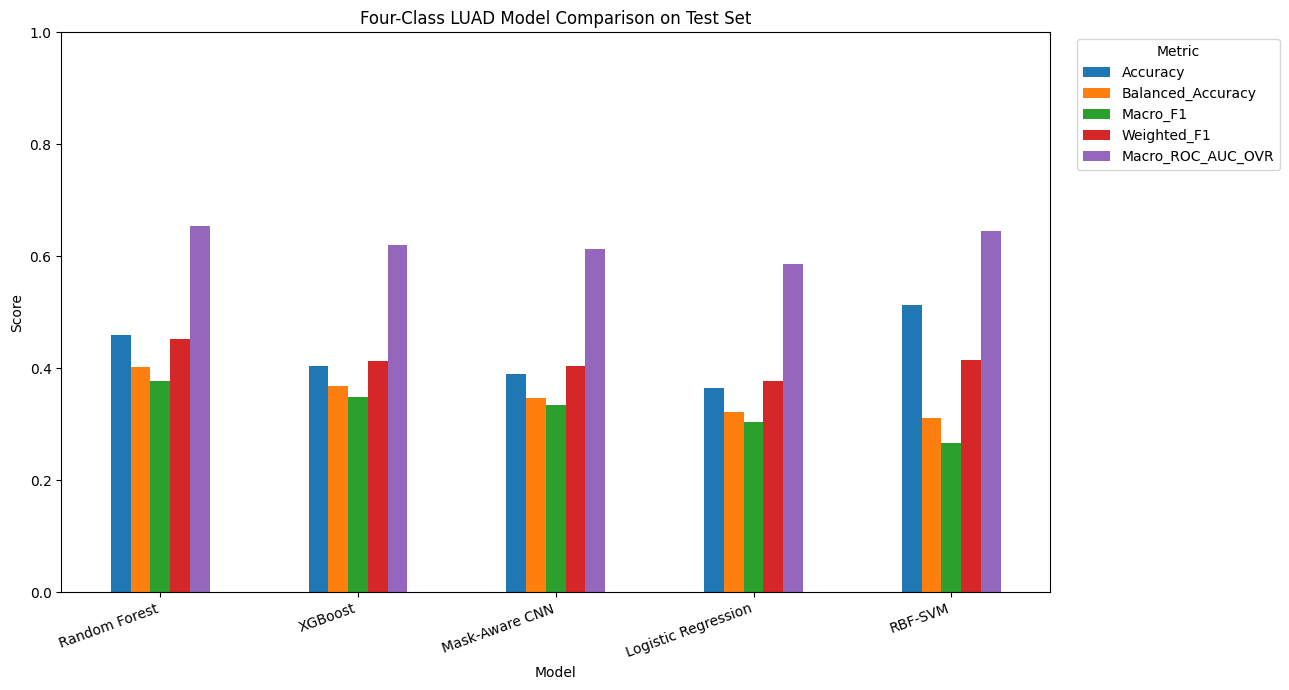

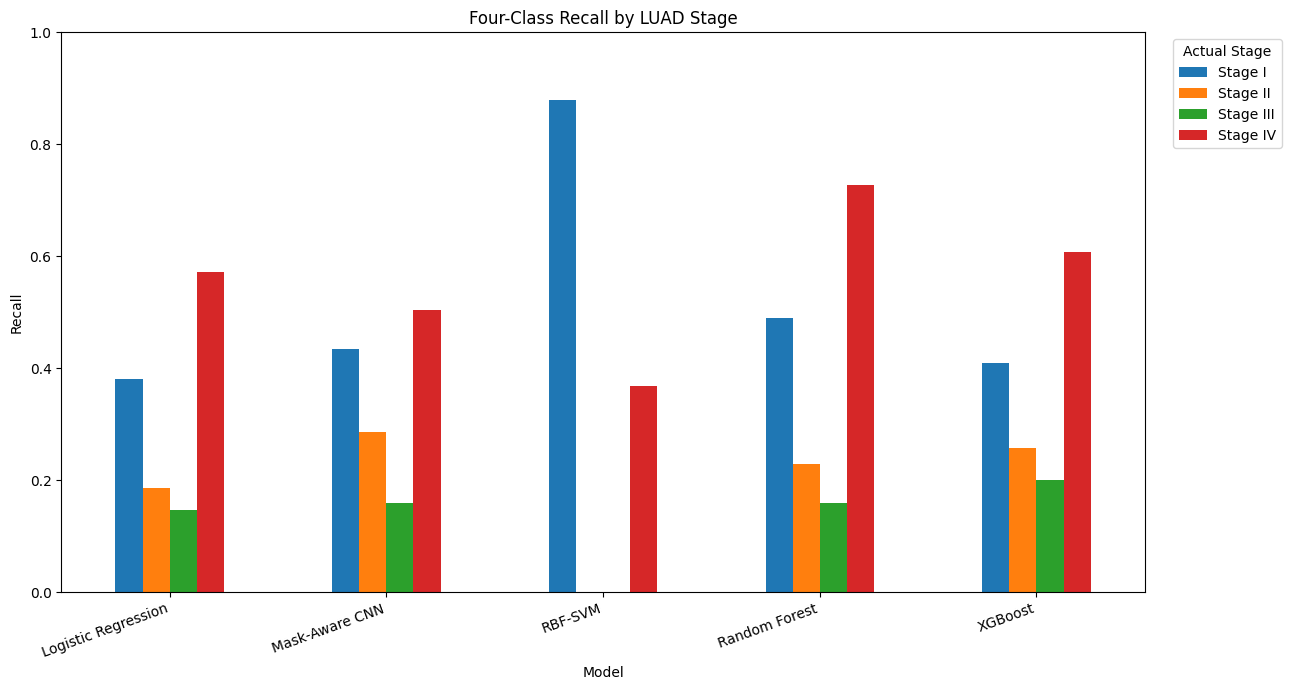

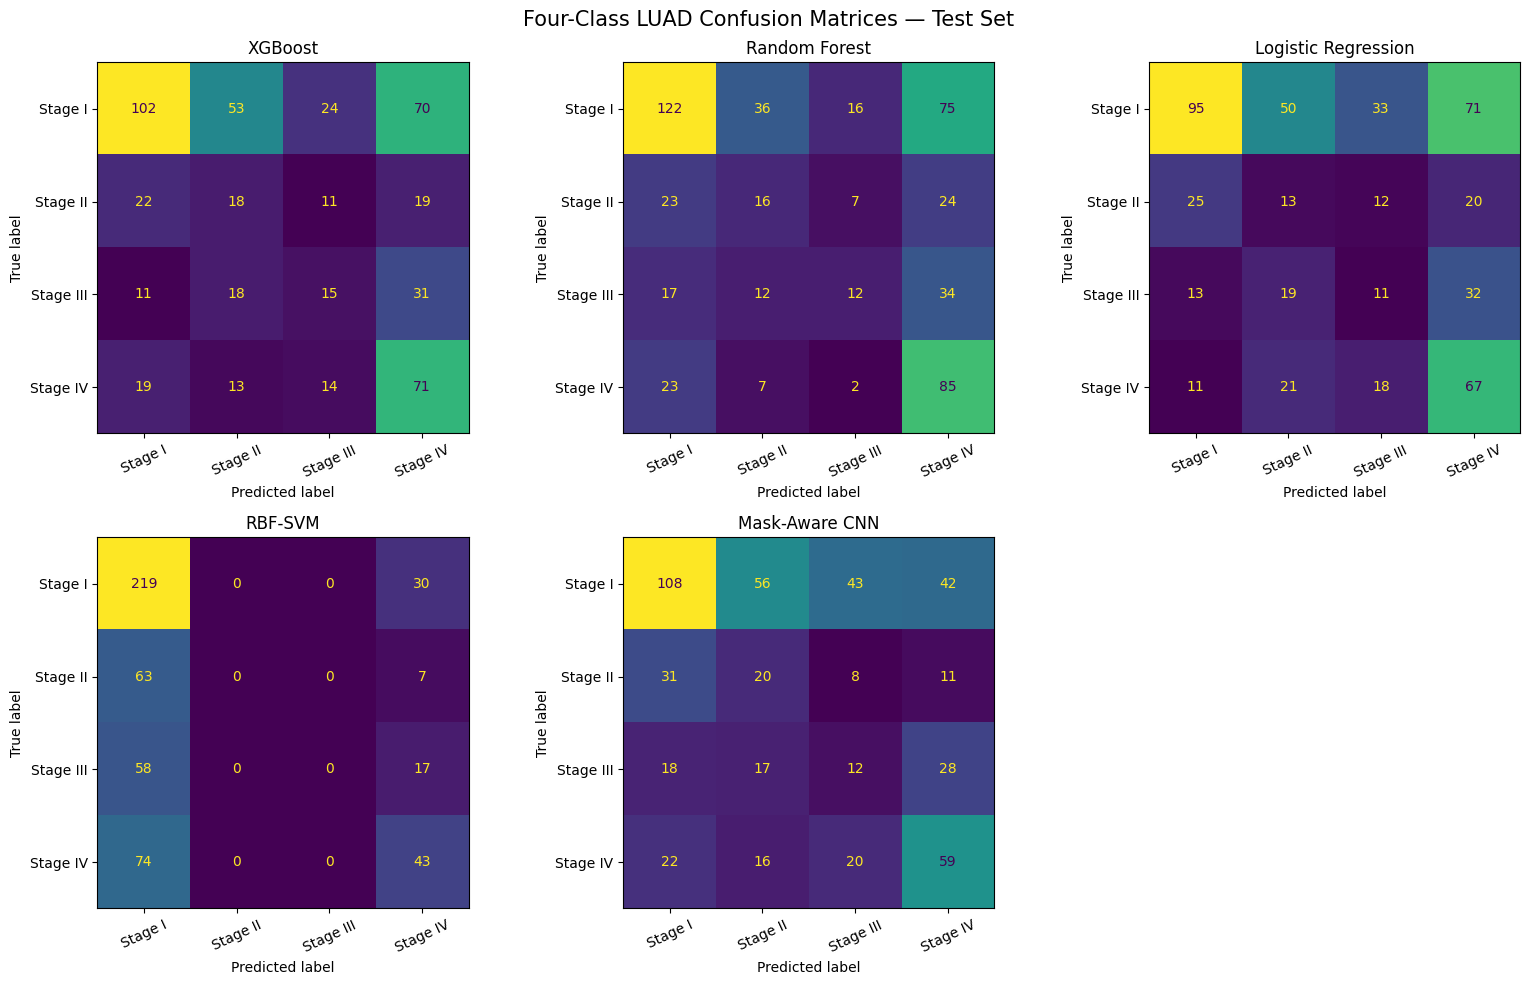

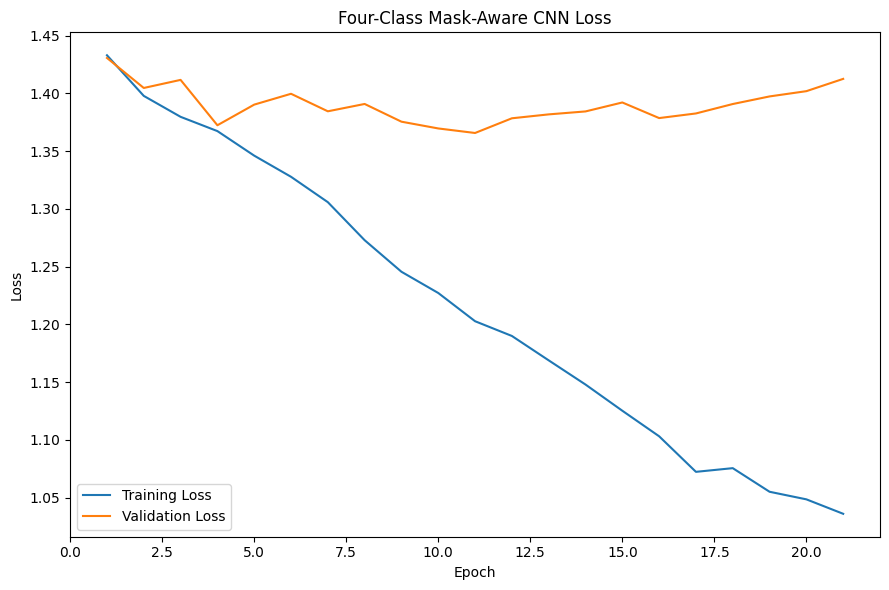

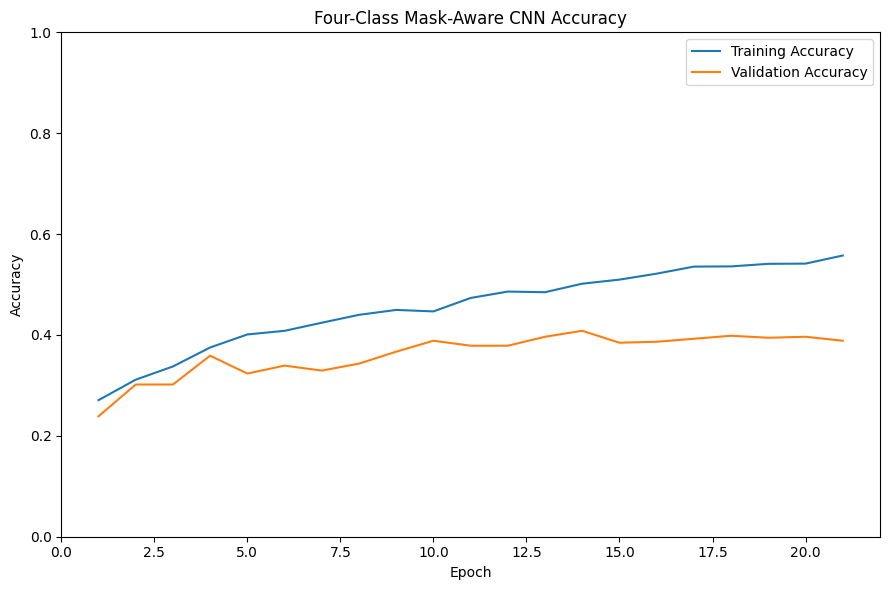

Four-class results saved successfully.

Output folder:
C:\Users\LAPTOP\Downloads\luad_reserch_code\luad_processeed_data\four_class_model_results

Saved files:
- four_class_all_split_metrics.csv
- four_class_cnn_accuracy_curve.png
- four_class_cnn_loss_curve.png
- four_class_cnn_training_history.csv
- four_class_confusion_matrices.png
- four_class_confusion_matrix_counts.csv
- four_class_generalisation_gaps.csv
- four_class_metrics_comparison.png
- four_class_model_summary.txt
- four_class_per_stage_recall.csv
- four_class_stage_recall_comparison.png
- four_class_test_model_comparison.csv

Scientifically selected model:
Random Forest

Highest raw accuracy model:
RBF-SVM


: 

In [ ]:
# Step 53 — Save all four-class results, graphs and summaries

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# 1. Create fixed output folder
# =========================================================

FOUR_CLASS_RESULTS_DIR = (
    PROJECT_DIR
    / "luad_processeed_data"
    / "four_class_model_results"
)

FOUR_CLASS_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Fixed paths — rerunning overwrites existing files
TEST_COMPARISON_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_test_model_comparison.csv"
)

ALL_SPLIT_METRICS_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_all_split_metrics.csv"
)

STAGE_RECALL_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_per_stage_recall.csv"
)

SUMMARY_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_model_summary.txt"
)

METRICS_GRAPH_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_metrics_comparison.png"
)

STAGE_RECALL_GRAPH_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_stage_recall_comparison.png"
)

CONFUSION_MATRICES_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_confusion_matrices.png"
)

CNN_HISTORY_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_cnn_training_history.csv"
)

CNN_LOSS_GRAPH_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_cnn_loss_curve.png"
)

CNN_ACCURACY_GRAPH_PATH = (
    FOUR_CLASS_RESULTS_DIR
    / "four_class_cnn_accuracy_curve.png"
)


# =========================================================
# 2. Build test-set model comparison
# =========================================================

four_class_test_comparison = pd.DataFrame(
    [
        {
            "Model": "XGBoost",
            **xgb_4class_test_metrics
        },
        {
            "Model": "Random Forest",
            **rf_4class_test_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_4class_test_metrics
        },
        {
            "Model": "RBF-SVM",
            **svm_4class_test_metrics
        },
        {
            "Model": "Mask-Aware CNN",
            **cnn_4class_test_metrics
        }
    ]
)

# Remove duplicate Split field from comparison
if "Split" in four_class_test_comparison.columns:
    four_class_test_comparison = (
        four_class_test_comparison
        .drop(columns=["Split"])
    )

four_class_test_comparison = (
    four_class_test_comparison
    .sort_values(
        [
            "Balanced_Accuracy",
            "Macro_F1",
            "Macro_ROC_AUC_OVR"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

four_class_test_comparison.to_csv(
    TEST_COMPARISON_PATH,
    index=False,
    mode="w"
)


# =========================================================
# 3. Save training, validation and test metrics
# =========================================================

model_metric_tables = [
    ("XGBoost", xgb_4class_metrics_table),
    ("Random Forest", rf_4class_metrics_table),
    (
        "Logistic Regression",
        logistic_4class_metrics_table
    ),
    ("RBF-SVM", svm_4class_metrics_table),
    ("Mask-Aware CNN", cnn_4class_metrics_table)
]

all_split_metric_frames = []

for model_name, metric_table in model_metric_tables:
    temporary_table = metric_table.copy()
    temporary_table.insert(
        0,
        "Model",
        model_name
    )
    all_split_metric_frames.append(
        temporary_table
    )

four_class_all_split_metrics = pd.concat(
    all_split_metric_frames,
    ignore_index=True,
    sort=False
)

four_class_all_split_metrics.to_csv(
    ALL_SPLIT_METRICS_PATH,
    index=False,
    mode="w"
)


# =========================================================
# 4. Calculate and save per-stage recall
# =========================================================

four_class_predictions = {
    "XGBoost": xgb_4class_test_predictions,
    "Random Forest": rf_4class_test_predictions,
    "Logistic Regression":
        logistic_4class_test_predictions,
    "RBF-SVM": svm_4class_test_predictions,
    "Mask-Aware CNN": cnn_4class_test_predictions
}

stage_names = [
    "Stage I",
    "Stage II",
    "Stage III",
    "Stage IV"
]

stage_recall_rows = []

for model_name, predictions in (
    four_class_predictions.items()
):
    recall_values = recall_score(
        y_test_4class,
        predictions,
        labels=[0, 1, 2, 3],
        average=None,
        zero_division=0
    )

    for stage_name, recall_value in zip(
        stage_names,
        recall_values
    ):
        stage_recall_rows.append(
            {
                "Model": model_name,
                "Stage": stage_name,
                "Recall": float(recall_value)
            }
        )

four_class_stage_recall_df = pd.DataFrame(
    stage_recall_rows
)

four_class_stage_recall_df.to_csv(
    STAGE_RECALL_PATH,
    index=False,
    mode="w"
)


# =========================================================
# 5. Save model-metric comparison graph
# =========================================================

comparison_metric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Macro_F1",
    "Weighted_F1",
    "Macro_ROC_AUC_OVR"
]

comparison_plot_df = (
    four_class_test_comparison
    .set_index("Model")[
        comparison_metric_columns
    ]
)

axis = comparison_plot_df.plot(
    kind="bar",
    figsize=(13, 7)
)

axis.set_title(
    "Four-Class LUAD Model Comparison on Test Set"
)

axis.set_xlabel("Model")
axis.set_ylabel("Score")
axis.set_ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    METRICS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================================================
# 6. Save per-stage recall graph
# =========================================================

stage_recall_plot_df = (
    four_class_stage_recall_df
    .pivot(
        index="Model",
        columns="Stage",
        values="Recall"
    )
    .reindex(columns=stage_names)
)

axis = stage_recall_plot_df.plot(
    kind="bar",
    figsize=(13, 7)
)

axis.set_title(
    "Four-Class Recall by LUAD Stage"
)

axis.set_xlabel("Model")
axis.set_ylabel("Recall")
axis.set_ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Actual Stage",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    STAGE_RECALL_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================================================
# 7. Save confusion matrices for all five models
# =========================================================

figure, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.flatten()

confusion_matrix_rows = []

for axis, (
    model_name,
    predictions
) in zip(
    axes,
    four_class_predictions.items()
):
    matrix = confusion_matrix(
        y_test_4class,
        predictions,
        labels=[0, 1, 2, 3]
    )

    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Stage I",
            "Stage II",
            "Stage III",
            "Stage IV"
        ]
    )

    display_object.plot(
        ax=axis,
        colorbar=False,
        xticks_rotation=25
    )

    axis.set_title(model_name)

    for actual_stage in range(4):
        for predicted_stage in range(4):
            confusion_matrix_rows.append(
                {
                    "Model": model_name,
                    "Actual_Stage":
                        stage_names[actual_stage],
                    "Predicted_Stage":
                        stage_names[predicted_stage],
                    "Count": int(
                        matrix[
                            actual_stage,
                            predicted_stage
                        ]
                    )
                }
            )

# Remove unused sixth subplot
for index in range(
    len(four_class_predictions),
    len(axes)
):
    figure.delaxes(axes[index])

figure.suptitle(
    "Four-Class LUAD Confusion Matrices — Test Set",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    CONFUSION_MATRICES_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

four_class_confusion_counts_df = pd.DataFrame(
    confusion_matrix_rows
)

four_class_confusion_counts_df.to_csv(
    FOUR_CLASS_RESULTS_DIR
    / "four_class_confusion_matrix_counts.csv",
    index=False,
    mode="w"
)


# =========================================================
# 8. Save CNN training history and curves
# =========================================================

cnn_4class_history_df = pd.DataFrame(
    cnn_4class_history.history
)

cnn_4class_history_df.index = (
    np.arange(
        1,
        len(cnn_4class_history_df) + 1
    )
)

cnn_4class_history_df.index.name = "Epoch"

cnn_4class_history_df.to_csv(
    CNN_HISTORY_PATH,
    mode="w"
)


# CNN loss curve
plt.figure(figsize=(9, 6))

plt.plot(
    cnn_4class_history_df.index,
    cnn_4class_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_4class_history_df.index,
    cnn_4class_history_df["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Four-Class Mask-Aware CNN Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    CNN_LOSS_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# CNN accuracy curve
plt.figure(figsize=(9, 6))

plt.plot(
    cnn_4class_history_df.index,
    cnn_4class_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_4class_history_df.index,
    cnn_4class_history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Four-Class Mask-Aware CNN Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    CNN_ACCURACY_GRAPH_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# =========================================================
# 9. Calculate train-test generalisation gaps
# =========================================================

generalisation_gap_rows = []

for model_name, metric_table in model_metric_tables:
    train_row = metric_table.loc[
        metric_table["Split"] == "Training"
    ].iloc[0]

    test_row = metric_table.loc[
        metric_table["Split"] == "Test"
    ].iloc[0]

    generalisation_gap_rows.append(
        {
            "Model": model_name,

            "Training_Accuracy":
                train_row["Accuracy"],

            "Test_Accuracy":
                test_row["Accuracy"],

            "Accuracy_Gap":
                train_row["Accuracy"]
                - test_row["Accuracy"],

            "Training_Macro_F1":
                train_row["Macro_F1"],

            "Test_Macro_F1":
                test_row["Macro_F1"],

            "Macro_F1_Gap":
                train_row["Macro_F1"]
                - test_row["Macro_F1"]
        }
    )

generalisation_gap_df = pd.DataFrame(
    generalisation_gap_rows
)

generalisation_gap_df.to_csv(
    FOUR_CLASS_RESULTS_DIR
    / "four_class_generalisation_gaps.csv",
    index=False,
    mode="w"
)


# =========================================================
# 10. Create detailed TXT summary
# =========================================================

best_balanced_row = (
    four_class_test_comparison.iloc[0]
)

highest_accuracy_row = (
    four_class_test_comparison.loc[
        four_class_test_comparison[
            "Accuracy"
        ].idxmax()
    ]
)

summary_lines = [
    "LUAD FOUR-CLASS STAGE CLASSIFICATION SUMMARY",
    "=" * 78,
    "",
    f"Total test patients: {len(y_test_4class)}",
    "",
    "LABEL MAPPING",
    "-" * 78,
    "0 = Stage I",
    "1 = Stage II",
    "2 = Stage III",
    "3 = Stage IV",
    "",
    "TEST CLASS DISTRIBUTION",
    "-" * 78,
    f"Stage I: {int((y_test_4class == 0).sum())}",
    f"Stage II: {int((y_test_4class == 1).sum())}",
    f"Stage III: {int((y_test_4class == 2).sum())}",
    f"Stage IV: {int((y_test_4class == 3).sum())}",
    "",
    f"Majority-class baseline accuracy: "
    f"{float(test_majority_baseline_4class):.4f}",
    "",
    "SCIENTIFICALLY SELECTED MODEL",
    "-" * 78,
    f"Model: {best_balanced_row['Model']}",
    f"Accuracy: {best_balanced_row['Accuracy']:.4f}",
    f"Balanced accuracy: "
    f"{best_balanced_row['Balanced_Accuracy']:.4f}",
    f"Macro precision: "
    f"{best_balanced_row['Macro_Precision']:.4f}",
    f"Macro recall: "
    f"{best_balanced_row['Macro_Recall']:.4f}",
    f"Macro F1-score: "
    f"{best_balanced_row['Macro_F1']:.4f}",
    f"Weighted F1-score: "
    f"{best_balanced_row['Weighted_F1']:.4f}",
    f"Macro ROC-AUC OVR: "
    f"{best_balanced_row['Macro_ROC_AUC_OVR']:.4f}",
    f"Log-loss: {best_balanced_row['Log_Loss']:.4f}",
    "",
    "HIGHEST RAW TEST ACCURACY",
    "-" * 78,
    f"Model: {highest_accuracy_row['Model']}",
    f"Accuracy: {highest_accuracy_row['Accuracy']:.4f}",
    "",
    "IMPORTANT INTERPRETATION",
    "-" * 78,
    "Balanced accuracy and macro F1 are prioritised over raw accuracy",
    "because the four stage classes are imbalanced.",
    "",
    "RBF-SVM obtained relatively high raw accuracy but failed to detect",
    "Stage II and Stage III patients, so it was not selected as the",
    "scientifically best four-class model.",
    "",
    "Random Forest provided the strongest balance across all four stages.",
    "Stage II and Stage III remained the most difficult classes.",
    "",
    "A train-to-test generalisation gap was observed, particularly for",
    "Random Forest and the Mask-Aware CNN. Four-class prediction should",
    "therefore be reported as exploratory rather than clinically validated.",
    "",
    "ALL TEST MODEL METRICS",
    "-" * 78,
    four_class_test_comparison
    .round(4)
    .to_string(index=False),
    "",
    "PER-STAGE TEST RECALL",
    "-" * 78,
    four_class_stage_recall_df
    .round(4)
    .to_string(index=False),
    "",
    "GENERALISATION GAPS",
    "-" * 78,
    generalisation_gap_df
    .round(4)
    .to_string(index=False),
    "",
    "MODEL INPUT POLICY",
    "-" * 78,
    "Tabular models used:",
    "- 89 active LUAD gene features",
    "- Mutation severity summaries",
    "- Mutation burden summaries",
    "- Sex",
    "- Age and age-missing indicator",
    "",
    "The Mask-Aware CNN additionally used:",
    "- Reference DNA windows",
    "- Mutated DNA windows",
    "- Mutation-position masks",
    "- Per-window mutation severity",
    "",
    "Excluded from model inputs:",
    "- Cohort",
    "- Smoking history",
    "- Pack-years",
    "- Passive smoking",
    "- Stage-label columns",
    "- Seven constant gene columns"
]

with open(
    SUMMARY_PATH,
    mode="w",
    encoding="utf-8"
) as summary_file:
    summary_file.write(
        "\n".join(summary_lines)
    )


# =========================================================
# 11. Final verification
# =========================================================

print("Four-class results saved successfully.")

print("\nOutput folder:")
print(FOUR_CLASS_RESULTS_DIR)

print("\nSaved files:")

for saved_file in sorted(
    FOUR_CLASS_RESULTS_DIR.iterdir()
):
    print("-", saved_file.name)

print("\nScientifically selected model:")
print(best_balanced_row["Model"])

print("\nHighest raw accuracy model:")
print(highest_accuracy_row["Model"])